# Exploratory Analysis of Fort Collins Daily Water Demand

This notebook examines the temporal structure of Fort Collins daily water
demand and develops the feature specifications used in the subsequent
one-day-ahead forecasting comparison.

It is part of the public
[`municipal-water-demand-forecasting`](https://github.com/fureyc/municipal-water-demand-forecasting)
repository. The notebook can be run from a local clone or in Google Colab. When
the repository is not already available in the current environment, the setup
cell clones the public repository without requiring GitHub credentials.

The analysis is restricted to the pre-holdout development period. The final
period, April 1, 2025 through March 31, 2026, remains untouched for final model
evaluation.

Nearby demand lags, rolling summaries, weather variables and seasonal
encodings may represent overlapping information. This can make unregularized
coefficient estimates unstable, although it does not necessarily imply poor
forecasting performance. The geometric analysis examines whether this
instability is present, how it evolves as the training period expands and
which groups of predictors dominate the principal directions of the design
matrix.


## 1. Setup and analytical boundaries

This section locates or clones the public repository, installs the recorded
Python dependencies, loads the modeling configuration and processed dataset,
then isolates the locked final holdout before any exploratory analysis is
performed.

Repository authentication, commits and pushes are intentionally kept outside
the analytical notebook.


In [1]:
from pathlib import Path
import os
import subprocess
import sys


REPOSITORY_NAME = "municipal-water-demand-forecasting"
REPOSITORY_URL = (
    "https://github.com/fureyc/"
    "municipal-water-demand-forecasting.git"
)


def find_repository_root(start=None):
    """Locate the repository from the current directory or its parents."""
    start = Path(start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "config" / "modeling.yml").exists()
            and (
                candidate
                / "data"
                / "processed"
                / "fort_collins_daily_water_weather.csv"
            ).exists()
        ):
            return candidate

    return None


repo_root = find_repository_root()

if repo_root is None:
    clone_parent = Path("/content") if Path("/content").exists() else Path.cwd()
    clone_target = clone_parent / REPOSITORY_NAME

    if not clone_target.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORY_URL, str(clone_target)],
            check=True,
        )

    repo_root = find_repository_root(clone_target)

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the project repository. Clone the public repository "
        "and run this notebook from the repository or its notebooks directory."
    )

os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)
print("Working directory:", Path.cwd())


Repository root: /content/municipal-water-demand-forecasting
Working directory: /content/municipal-water-demand-forecasting


In [2]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(repo_root / "requirements.txt"),
    ],
    check=True,
)

print("Project dependencies are available.")


Project dependencies are available.


In [3]:
import importlib.metadata as metadata
import json
import platform
from itertools import product

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from IPython.display import display
from pandas.tseries.holiday import USFederalHolidayCalendar
from statsmodels.graphics.tsaplots import plot_acf

from src.evaluation.time_splits import (
    build_expanding_window_splits,
    get_final_holdout,
    load_modeling_config,
    summarize_splits,
    validate_holdout_isolation,
)


CONFIG_PATH = repo_root / "config" / "modeling.yml"
DATA_PATH = (
    repo_root
    / "data"
    / "processed"
    / "fort_collins_daily_water_weather.csv"
)

environment_versions = pd.Series(
    {
        "Python": platform.python_version(),
        "pandas": metadata.version("pandas"),
        "NumPy": metadata.version("numpy"),
        "Matplotlib": metadata.version("matplotlib"),
        "statsmodels": metadata.version("statsmodels"),
        "PyYAML": metadata.version("PyYAML"),
    },
    name="version",
)

display(environment_versions.to_frame())
print("Configuration exists:", CONFIG_PATH.exists())
print("Processed dataset exists:", DATA_PATH.exists())


,version
Python,3.12.13
pandas,2.2.2
NumPy,2.0.2
Matplotlib,3.10.0
statsmodels,0.14.6
PyYAML,6.0.3


Configuration exists: True
Processed dataset exists: True


In [4]:
config = load_modeling_config(CONFIG_PATH)

forecast_config = config["forecast"]
evaluation_config = config["evaluation"]

date_column = forecast_config["date_column"]
target_column = forecast_config["target_column"]

development_start = pd.Timestamp(
    evaluation_config["initial_training"]["start_date"]
)
development_end = pd.Timestamp(
    evaluation_config["rolling_validation"]["end_date"]
)
holdout_start = pd.Timestamp(
    evaluation_config["final_holdout"]["start_date"]
)
holdout_end = pd.Timestamp(
    evaluation_config["final_holdout"]["end_date"]
)

print("Forecast task:", forecast_config["task"])
print("Frequency:", forecast_config["frequency"])
print("Forecast horizon:", forecast_config["horizon_days"], "day")
print("Date column:", date_column)
print("Target column:", target_column)
print()
print(
    "Development period:",
    development_start.date(),
    "through",
    development_end.date(),
)
print(
    "Locked holdout:",
    holdout_start.date(),
    "through",
    holdout_end.date(),
)

Forecast task: one_day_ahead
Frequency: daily
Forecast horizon: 1 day
Date column: date
Target column: water_demand_mgd

Development period: 2020-01-01 through 2025-03-31
Locked holdout: 2025-04-01 through 2026-03-31


## 2. Processed-data verification

Before beginning exploratory analysis, the processed dataset is checked for the
expected schema, valid dates, chronological ordering, daily continuity,
duplicate observations, missing values and consistency with the configured
analysis period.

In [5]:
full_data = pd.read_csv(
    DATA_PATH,
    parse_dates=[date_column],
)

print("Dataset loaded successfully.")
print("Shape:", full_data.shape)
print(
    "Date range:",
    full_data[date_column].min().date(),
    "through",
    full_data[date_column].max().date(),
)

display(full_data.head())

Dataset loaded successfully.
Shape: (2282, 17)
Date range: 2020-01-01 through 2026-03-31


,date,water_demand_mgd,projected_water_demand_mgd,actual_projected_demand_ratio,plant_demand_mgd,tmax_f,tmin_f,tavg_f,temperature_range_f,precipitation_in,snowfall_in,snow_depth_in,year,month,day_of_year,day_of_week,is_weekend
0,2020-01-01,12.47,12.06,1.033997,12.77,54,23,38.5,31,0.0,0.0,1,2020,1,1,2,0
1,2020-01-02,13.24,13.11,1.009916,14.17,49,32,40.5,17,0.0,0.0,1,2020,1,2,3,0
2,2020-01-03,13.57,13.53,1.002956,14.10,43,18,30.5,25,0.0,0.0,1,2020,1,3,4,0
3,2020-01-04,13.38,13.63,0.981658,13.84,54,22,38.0,32,0.0,0.0,0,2020,1,4,5,1
4,2020-01-05,13.52,13.70,0.986861,14.51,54,28,41.0,26,0.0,0.0,0,2020,1,5,6,1


In [6]:
expected_columns = [
    "date",
    "water_demand_mgd",
    "projected_water_demand_mgd",
    "actual_projected_demand_ratio",
    "plant_demand_mgd",
    "tmax_f",
    "tmin_f",
    "tavg_f",
    "temperature_range_f",
    "precipitation_in",
    "snowfall_in",
    "snow_depth_in",
    "year",
    "month",
    "day_of_year",
    "day_of_week",
    "is_weekend",
]

missing_columns = sorted(set(expected_columns) - set(full_data.columns))
unexpected_columns = sorted(set(full_data.columns) - set(expected_columns))

print("Missing expected columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)
print("Column order matches:", full_data.columns.tolist() == expected_columns)

Missing expected columns: []
Unexpected columns: []
Column order matches: True


In [7]:
dates = full_data[date_column]

expected_daily_index = pd.date_range(
    start=dates.min(),
    end=dates.max(),
    freq="D",
)

numeric_columns = full_data.select_dtypes(include=[np.number]).columns

checks = {
    "date_column_is_datetime": pd.api.types.is_datetime64_any_dtype(dates),
    "dates_are_sorted": dates.is_monotonic_increasing,
    "dates_are_unique": not dates.duplicated().any(),
    "daily_sequence_is_complete": pd.DatetimeIndex(dates).equals(
        expected_daily_index
    ),
    "no_missing_values": not full_data.isna().any().any(),
    "numeric_values_are_finite": np.isfinite(
        full_data[numeric_columns].to_numpy()
    ).all(),
    "dataset_starts_as_configured": dates.min() == development_start,
    "dataset_ends_as_configured": dates.max() == holdout_end,
    "development_precedes_holdout": development_end < holdout_start,
    "development_and_holdout_are_contiguous": (
        development_end + pd.Timedelta(days=1) == holdout_start
    ),
    "target_column_is_numeric": pd.api.types.is_numeric_dtype(
        full_data[target_column]
    ),
    "expected_row_count": len(full_data) == 2282,
    "expected_column_count": full_data.shape[1] == 17,
    "expected_schema": (
        not missing_columns
        and not unexpected_columns
        and full_data.columns.tolist() == expected_columns
    ),
}

verification = pd.DataFrame(
    {
        "check": list(checks.keys()),
        "passed": list(checks.values()),
    }
)

display(verification)

failed_checks = verification.loc[
    ~verification["passed"], "check"
].tolist()

assert not failed_checks, (
    "Processed-data verification failed: "
    + ", ".join(failed_checks)
)

print("All processed-data checks passed.")

,check,passed
0,date_column_is_datetime,True
1,dates_are_sorted,True
2,dates_are_unique,True
3,daily_sequence_is_complete,True
4,no_missing_values,True
5,numeric_values_are_finite,True
6,dataset_starts_as_configured,True
7,dataset_ends_as_configured,True
8,development_precedes_holdout,True
9,development_and_holdout_are_contiguous,True


All processed-data checks passed.


In [8]:
schema = pd.DataFrame(
    {
        "column": full_data.columns,
        "dtype": full_data.dtypes.astype(str).values,
        "missing_values": full_data.isna().sum().values,
        "unique_values": full_data.nunique(dropna=False).values,
    }
)

display(schema)

,column,dtype,missing_values,unique_values
0,date,datetime64[ns],0,2282
1,water_demand_mgd,float64,0,1251
2,projected_water_demand_mgd,float64,0,980
3,actual_projected_demand_ratio,float64,0,2263
4,plant_demand_mgd,float64,0,1287
5,tmax_f,int64,0,94
6,tmin_f,int64,0,84
7,tavg_f,float64,0,157
8,temperature_range_f,int64,0,49
9,precipitation_in,float64,0,82


In [9]:
verification_summary = pd.Series(
    {
        "rows": len(full_data),
        "columns": full_data.shape[1],
        "start_date": dates.min(),
        "end_date": dates.max(),
        "duplicate_dates": int(dates.duplicated().sum()),
        "missing_dates": int(
            len(expected_daily_index) - dates.nunique()
        ),
        "missing_values": int(full_data.isna().sum().sum()),
        "all_numeric_values_finite": bool(
            np.isfinite(full_data[numeric_columns].to_numpy()).all()
        ),
    },
    name="processed_dataset",
)

display(verification_summary.to_frame())

,processed_dataset
rows,2282
columns,17
start_date,2020-01-01 00:00:00
end_date,2026-03-31 00:00:00
duplicate_dates,0
missing_dates,0
missing_values,0
all_numeric_values_finite,True


### Evidence

- The processed table contains the expected 2,282 daily observations and 17
  variables.
- The date index is ordered, unique and complete from January 1, 2020 through
  March 31, 2026.
- The expected schema is present with no missing or nonfinite values.
- The dataset boundaries agree with the modeling configuration.

### Provisional modeling implication

The processed table is suitable for exploratory analysis after the locked
holdout is isolated.

### Open question

How many observations remain available for descriptive analysis and
rolling-origin development after the final holdout is removed?

## 3. Time-split verification and holdout isolation

The configured expanding-window splits are verified before exploratory analysis
begins. The final 365-day period is then removed from the active analytical
dataset so that feature development and interpretation cannot use holdout
outcomes inadvertently.

In [10]:
splits = build_expanding_window_splits(
    full_data,
    config,
)

final_holdout = get_final_holdout(
    full_data,
    config,
)

validate_holdout_isolation(
    splits,
    final_holdout,
)

split_summary = summarize_splits(splits)

display(split_summary)

print("Validation folds:", len(splits))
print(
    "Final holdout:",
    final_holdout.start.date(),
    "through",
    final_holdout.end.date(),
)
print("Final holdout observations:", final_holdout.n_observations)
print("Holdout isolation check: passed")

,fold,train_start,train_end,n_train,validation_start,validation_end,n_validation
0,1,2020-01-01,2022-12-31,1096,2023-01-01,2023-03-31,90
1,2,2020-01-01,2023-03-31,1186,2023-04-01,2023-06-30,91
2,3,2020-01-01,2023-06-30,1277,2023-07-01,2023-09-30,92
3,4,2020-01-01,2023-09-30,1369,2023-10-01,2023-12-31,92
4,5,2020-01-01,2023-12-31,1461,2024-01-01,2024-03-31,91
5,6,2020-01-01,2024-03-31,1552,2024-04-01,2024-06-30,91
6,7,2020-01-01,2024-06-30,1643,2024-07-01,2024-09-30,92
7,8,2020-01-01,2024-09-30,1735,2024-10-01,2024-12-31,92
8,9,2020-01-01,2024-12-31,1827,2025-01-01,2025-03-31,90


Validation folds: 9
Final holdout: 2025-04-01 through 2026-03-31
Final holdout observations: 365
Holdout isolation check: passed


In [11]:
split_checks = []

previous_n_train = None
previous_validation_end = None

for split in splits:
    train_dates = full_data.iloc[
        split.train_positions
    ][date_column]

    validation_dates = full_data.iloc[
        split.validation_positions
    ][date_column]

    train_precedes_validation = (
        train_dates.max() < validation_dates.min()
    )

    validation_precedes_holdout = (
        validation_dates.max() < holdout_start
    )

    training_window_expands = (
        previous_n_train is None
        or split.n_train > previous_n_train
    )

    validation_windows_are_ordered = (
        previous_validation_end is None
        or validation_dates.min() > previous_validation_end
    )

    split_checks.append(
        {
            "fold": split.fold,
            "train_precedes_validation": train_precedes_validation,
            "validation_precedes_holdout": validation_precedes_holdout,
            "training_window_expands": training_window_expands,
            "validation_windows_are_ordered": (
                validation_windows_are_ordered
            ),
        }
    )

    previous_n_train = split.n_train
    previous_validation_end = validation_dates.max()

split_verification = pd.DataFrame(split_checks)

display(split_verification)

assert split_verification.drop(
    columns="fold"
).to_numpy().all()

print("All split-level checks passed.")

,fold,train_precedes_validation,validation_precedes_holdout,training_window_expands,validation_windows_are_ordered
0,1,True,True,True,True
1,2,True,True,True,True
2,3,True,True,True,True
3,4,True,True,True,True
4,5,True,True,True,True
5,6,True,True,True,True
6,7,True,True,True,True
7,8,True,True,True,True
8,9,True,True,True,True


All split-level checks passed.


In [12]:
assert len(splits) == 9

assert splits[0].train_start == pd.Timestamp("2020-01-01")
assert splits[0].train_end == pd.Timestamp("2022-12-31")
assert splits[0].validation_start == pd.Timestamp("2023-01-01")
assert splits[0].validation_end == pd.Timestamp("2023-03-31")

assert splits[-1].train_start == pd.Timestamp("2020-01-01")
assert splits[-1].train_end == pd.Timestamp("2024-12-31")
assert splits[-1].validation_start == pd.Timestamp("2025-01-01")
assert splits[-1].validation_end == pd.Timestamp("2025-03-31")

print("First and final fold boundaries match the configuration.")

First and final fold boundaries match the configuration.


In [13]:
development_mask = full_data[date_column].between(
    development_start,
    development_end,
    inclusive="both",
)

holdout_mask = full_data[date_column].between(
    holdout_start,
    holdout_end,
    inclusive="both",
)

print("Development observations:", int(development_mask.sum()))
print("Holdout observations:", int(holdout_mask.sum()))
print("Total observations:", len(full_data))

Development observations: 1917
Holdout observations: 365
Total observations: 2282


In [14]:
development = (
    full_data.loc[development_mask]
    .copy()
    .reset_index(drop=True)
)

holdout_metadata = pd.Series(
    {
        "start_date": holdout_start,
        "end_date": holdout_end,
        "observations": int(holdout_mask.sum()),
        "locked_for_final_reporting": evaluation_config[
            "final_holdout"
        ]["locked_for_final_reporting"],
    },
    name="locked_holdout",
)

assert len(development) == 1917
assert int(holdout_mask.sum()) == 365
assert len(development) + int(holdout_mask.sum()) == len(full_data)

assert development[date_column].min() == development_start
assert development[date_column].max() == development_end
assert development[date_column].max() < holdout_start

print(
    "Active development period:",
    development[date_column].min().date(),
    "through",
    development[date_column].max().date(),
)

print("Development shape:", development.shape)

display(holdout_metadata.to_frame())

Active development period: 2020-01-01 through 2025-03-31
Development shape: (1917, 17)


,locked_holdout
start_date,2025-04-01 00:00:00
end_date,2026-03-31 00:00:00
observations,365
locked_for_final_reporting,True


In [15]:
development_dates = development[date_column]

expected_development_dates = pd.date_range(
    start=development_start,
    end=development_end,
    freq="D",
)

development_checks = {
    "expected_row_count": len(development) == 1917,
    "expected_column_count": development.shape[1] == 17,
    "starts_as_configured": (
        development_dates.min() == development_start
    ),
    "ends_as_configured": (
        development_dates.max() == development_end
    ),
    "dates_are_sorted": (
        development_dates.is_monotonic_increasing
    ),
    "dates_are_unique": (
        not development_dates.duplicated().any()
    ),
    "daily_sequence_is_complete": (
        pd.DatetimeIndex(development_dates).equals(
            expected_development_dates
        )
    ),
    "no_missing_values": (
        not development.isna().any().any()
    ),
}

development_verification = pd.DataFrame(
    {
        "check": list(development_checks.keys()),
        "passed": list(development_checks.values()),
    }
)

display(development_verification)

assert development_verification["passed"].all()

print("Development-period checks passed.")

,check,passed
0,expected_row_count,True
1,expected_column_count,True
2,starts_as_configured,True
3,ends_as_configured,True
4,dates_are_sorted,True
5,dates_are_unique,True
6,daily_sequence_is_complete,True
7,no_missing_values,True


Development-period checks passed.


In [16]:
analysis_boundaries = {
    "development_start": development_start,
    "development_end": development_end,
    "holdout_start": holdout_start,
    "holdout_end": holdout_end,
    "development_observations": len(development),
    "holdout_observations": int(holdout_mask.sum()),
}

del full_data
del development_mask
del holdout_mask
del final_holdout

print(
    "The active analysis dataframe is restricted to:",
    development[date_column].min().date(),
    "through",
    development[date_column].max().date(),
)

print("Active dataframe:", "development")
print("Active observations:", len(development))

The active analysis dataframe is restricted to: 2020-01-01 through 2025-03-31
Active dataframe: development
Active observations: 1917


### Evidence

- Nine expanding-window validation folds were reconstructed from the modeling
  configuration.
- Each training period precedes its validation period and expands as additional
  history becomes available.
- No training or validation split overlaps the final holdout.
- The active development dataset contains 1,917 complete daily observations
  from January 1, 2020 through March 31, 2025.
- The final 365 observations remain represented only by boundary metadata.

### Provisional modeling implication

All exploratory analysis, feature development and rolling-validation decisions
will use the development period. The locked holdout will not be examined until
the model-development process is complete.

### Open question

Which variables are eligible as predictors, external benchmarks or contextual
fields under the one-day-ahead forecasting task?

## 4. Variable roles and forecast-time availability

The processed table contains variables with different analytical roles. Some
are eligible forecasting inputs, some are external benchmarks and some must be
excluded because they contain the target directly or have not been established
as available at forecast time.

Descriptive association is not sufficient to justify inclusion in a forecasting
model. Candidate predictors must also be available when the forecast is issued
and must improve performance under rolling-origin validation.

In [17]:
configured_weather_columns = config["features"]["weather_columns"]
configured_calendar_columns = config["features"]["calendar_columns"]
configured_reference_columns = config["features"]["reference_columns"]

print("Configured weather columns:")
print(configured_weather_columns)

print("\nConfigured calendar columns:")
print(configured_calendar_columns)

print("\nConfigured reference columns:")
print(configured_reference_columns)

for column in (
    configured_weather_columns
    + configured_calendar_columns
    + configured_reference_columns
):
    assert column in development.columns, f"Configured column not found: {column}"

print("\nAll configured variables are present in the development dataset.")

Configured weather columns:
['tmax_f', 'tmin_f', 'tavg_f', 'temperature_range_f', 'precipitation_in', 'snowfall_in', 'snow_depth_in']

Configured calendar columns:
['month', 'day_of_year', 'day_of_week', 'is_weekend']

Configured reference columns:
['projected_water_demand_mgd', 'actual_projected_demand_ratio', 'plant_demand_mgd']

All configured variables are present in the development dataset.


In [18]:
variable_roles = pd.DataFrame(
    [
        {
            "variable": "date",
            "group": "Time index",
            "role": "Orders observations and defines forecast dates",
            "forecast_time_status": "Known",
            "initial_model_status": "Index only",
        },
        {
            "variable": "water_demand_mgd",
            "group": "Target",
            "role": "Observed daily municipal water demand",
            "forecast_time_status": "Unknown on forecast date",
            "initial_model_status": "Target only",
        },
        {
            "variable": "projected_water_demand_mgd",
            "group": "City reference",
            "role": "External projected-demand benchmark",
            "forecast_time_status": "Reference availability to be documented",
            "initial_model_status": "Benchmark, not default predictor",
        },
        {
            "variable": "actual_projected_demand_ratio",
            "group": "Leakage field",
            "role": "Observed demand divided by projected demand",
            "forecast_time_status": "Unavailable because it contains the target",
            "initial_model_status": "Exclude",
        },
        {
            "variable": "plant_demand_mgd",
            "group": "Operational context",
            "role": "Daily treatment-plant demand",
            "forecast_time_status": "Interpretation and availability not established",
            "initial_model_status": "Context only",
        },
        {
            "variable": "tmax_f",
            "group": "Weather",
            "role": "Daily maximum temperature",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "tmin_f",
            "group": "Weather",
            "role": "Daily minimum temperature",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "tavg_f",
            "group": "Weather",
            "role": "Daily average temperature",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "temperature_range_f",
            "group": "Weather",
            "role": "Difference between daily maximum and minimum temperature",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "precipitation_in",
            "group": "Weather",
            "role": "Daily precipitation",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "snowfall_in",
            "group": "Weather",
            "role": "Daily snowfall",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "snow_depth_in",
            "group": "Weather",
            "role": "Observed snow depth",
            "forecast_time_status": "Lagged observation or same-day benchmark",
            "initial_model_status": "Candidate",
        },
        {
            "variable": "year",
            "group": "Calendar",
            "role": "Calendar year used for descriptive grouping",
            "forecast_time_status": "Known",
            "initial_model_status": "Descriptive; trend use requires justification",
        },
        {
            "variable": "month",
            "group": "Calendar",
            "role": "Month of year",
            "forecast_time_status": "Known",
            "initial_model_status": "Candidate encoding",
        },
        {
            "variable": "day_of_year",
            "group": "Calendar",
            "role": "Position within the annual cycle",
            "forecast_time_status": "Known",
            "initial_model_status": "Candidate cyclical encoding",
        },
        {
            "variable": "day_of_week",
            "group": "Calendar",
            "role": "Monday equals 0 through Sunday equals 6",
            "forecast_time_status": "Known",
            "initial_model_status": "Candidate encoding",
        },
        {
            "variable": "is_weekend",
            "group": "Calendar",
            "role": "Indicator derived from day of week",
            "forecast_time_status": "Known",
            "initial_model_status": "Candidate but potentially redundant",
        },
    ]
)

assert set(variable_roles["variable"]) == set(development.columns)
assert not variable_roles["variable"].duplicated().any()

display(variable_roles)

,variable,group,role,forecast_time_status,initial_model_status
0,date,Time index,Orders observations and defines forecast dates,Known,Index only
1,water_demand_mgd,Target,Observed daily municipal water demand,Unknown on forecast date,Target only
2,projected_water_demand_mgd,City reference,External projected-demand benchmark,Reference availability to be documented,"Benchmark, not default predictor"
3,actual_projected_demand_ratio,Leakage field,Observed demand divided by projected demand,Unavailable because it contains the target,Exclude
4,plant_demand_mgd,Operational context,Daily treatment-plant demand,Interpretation and availability not established,Context only
5,tmax_f,Weather,Daily maximum temperature,Lagged observation or same-day benchmark,Candidate
6,tmin_f,Weather,Daily minimum temperature,Lagged observation or same-day benchmark,Candidate
7,tavg_f,Weather,Daily average temperature,Lagged observation or same-day benchmark,Candidate
8,temperature_range_f,Weather,Difference between daily maximum and minimum t...,Lagged observation or same-day benchmark,Candidate
9,precipitation_in,Weather,Daily precipitation,Lagged observation or same-day benchmark,Candidate


In [19]:
ratio_reconstructed = (
    development["water_demand_mgd"]
    / development["projected_water_demand_mgd"]
)

tavg_reconstructed = (
    development["tmax_f"] + development["tmin_f"]
) / 2

temperature_range_reconstructed = (
    development["tmax_f"] - development["tmin_f"]
)

calendar_reconstructions = {
    "year": development[date_column].dt.year,
    "month": development[date_column].dt.month,
    "day_of_year": development[date_column].dt.dayofyear,
    "day_of_week": development[date_column].dt.dayofweek,
    "is_weekend": (
        development[date_column].dt.dayofweek >= 5
    ).astype(int),
}

identity_checks = [
    {
        "relationship": (
            "actual_projected_demand_ratio = "
            "water_demand_mgd / projected_water_demand_mgd"
        ),
        "maximum_absolute_error": np.max(
            np.abs(
                development["actual_projected_demand_ratio"]
                - ratio_reconstructed
            )
        ),
        "passed": np.allclose(
            development["actual_projected_demand_ratio"],
            ratio_reconstructed,
            rtol=1e-8,
            atol=1e-10,
        ),
    },
    {
        "relationship": "tavg_f = (tmax_f + tmin_f) / 2",
        "maximum_absolute_error": np.max(
            np.abs(
                development["tavg_f"]
                - tavg_reconstructed
            )
        ),
        "passed": np.allclose(
            development["tavg_f"],
            tavg_reconstructed,
            rtol=1e-8,
            atol=1e-10,
        ),
    },
    {
        "relationship": (
            "temperature_range_f = tmax_f - tmin_f"
        ),
        "maximum_absolute_error": np.max(
            np.abs(
                development["temperature_range_f"]
                - temperature_range_reconstructed
            )
        ),
        "passed": np.allclose(
            development["temperature_range_f"],
            temperature_range_reconstructed,
            rtol=1e-8,
            atol=1e-10,
        ),
    },
]

for column, reconstructed in calendar_reconstructions.items():
    identity_checks.append(
        {
            "relationship": f"{column} is derived from date",
            "maximum_absolute_error": np.max(
                np.abs(
                    development[column].to_numpy()
                    - reconstructed.to_numpy()
                )
            ),
            "passed": np.array_equal(
                development[column].to_numpy(),
                reconstructed.to_numpy(),
            ),
        }
    )

identity_verification = pd.DataFrame(identity_checks)

display(identity_verification)

assert identity_verification["passed"].all()

print("All deterministic relationship checks passed.")

,relationship,maximum_absolute_error,passed
0,actual_projected_demand_ratio = water_demand_m...,5.107026e-15,True
1,tavg_f = (tmax_f + tmin_f) / 2,0.000000e+00,True
2,temperature_range_f = tmax_f - tmin_f,0.000000e+00,True
3,year is derived from date,0.000000e+00,True
4,month is derived from date,0.000000e+00,True
5,day_of_year is derived from date,0.000000e+00,True
6,day_of_week is derived from date,0.000000e+00,True
7,is_weekend is derived from date,0.000000e+00,True


All deterministic relationship checks passed.


In [20]:
weather_scenarios = pd.DataFrame(
    [
        {
            "scenario": "Operational",
            "calendar_information": "Included",
            "lagged_demand": "Included",
            "lagged_observed_weather": "Included",
            "same_day_observed_weather": "Excluded",
            "interpretation": (
                "Uses information that could be available before "
                "the forecast date"
            ),
        },
        {
            "scenario": "Weather-informed benchmark",
            "calendar_information": "Included",
            "lagged_demand": "Included",
            "lagged_observed_weather": "Included",
            "same_day_observed_weather": "Included",
            "interpretation": (
                "Optimistic retrospective benchmark for the value "
                "of accurate same-day weather information"
            ),
        },
    ]
)

display(weather_scenarios)

,scenario,calendar_information,lagged_demand,lagged_observed_weather,same_day_observed_weather,interpretation
0,Operational,Included,Included,Included,Excluded,Uses information that could be available befor...
1,Weather-informed benchmark,Included,Included,Included,Included,Optimistic retrospective benchmark for the val...


The two scenarios distinguish forecast-time availability. They do not establish
that weather improves prediction.

Weather will be justified in three stages:

1. Physical plausibility motivates examining it.
2. Development-period EDA determines whether meaningful associations appear in
   this dataset.
3. Rolling-origin ablation comparisons determine whether weather improves
   forecasts beyond calendar and demand-history information.

The third stage will determine whether weather is retained. Same-day observed
weather will remain explicitly labeled as a retrospective benchmark.

In [21]:
excluded_as_predictors = {
    target_column,
    "actual_projected_demand_ratio",
    "projected_water_demand_mgd",
    "plant_demand_mgd",
}

assert target_column in excluded_as_predictors
assert "actual_projected_demand_ratio" in excluded_as_predictors

print("Fields excluded from the default predictor matrix:")
for column in sorted(excluded_as_predictors):
    print("-", column)

Fields excluded from the default predictor matrix:
- actual_projected_demand_ratio
- plant_demand_mgd
- projected_water_demand_mgd
- water_demand_mgd


### Evidence

- Every processed variable has been assigned a modeling role and forecast-time
  status.
- The observed-to-projected ratio contains the forecast target directly and
  must be excluded.
- Average temperature and temperature range are deterministic functions of
  maximum and minimum temperature.
- Calendar variables are deterministic functions of the date.
- Same-day observed weather is not available in the primary operational
  scenario.

### Provisional modeling implication

Weather remains a candidate feature group rather than an assumed requirement.
Its incremental contribution will be evaluated through rolling-origin
comparisons with and without weather.

Temperature representations and calendar encodings must be chosen carefully to
avoid exact or unnecessary redundancy. The City projection will be evaluated
as an external benchmark rather than included as a default predictor.

### Open question

What temporal patterns in the development-period demand series motivate the
initial seasonal, calendar and lagged-demand features?

## 5. Development-period demand through time

The first figure provides an overall view of observed daily municipal water
demand during the development period. It is used to examine recurring
seasonality, year-to-year variation, changes in variability and potentially
unusual observations.

A centered 30-day rolling mean is included only as a descriptive visual aid. It
uses observations on both sides of each date and will not be used as a
forecasting feature.

In [22]:
demand_summary = development[target_column].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).rename("water_demand_mgd")

display(demand_summary.to_frame())

,water_demand_mgd
count,1917.000000
mean,20.264765
std,7.995706
min,8.950000
1%,11.510000
5%,13.060000
25%,14.160000
50%,15.470000
75%,27.280000
95%,35.484000


In [23]:
annual_summary = (
    development
    .groupby("year")[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

annual_summary["coefficient_of_variation"] = (
    annual_summary["standard_deviation"]
    / annual_summary["mean"]
)

annual_summary["period_status"] = np.where(
    annual_summary["observations"].isin([365, 366]),
    "Complete calendar year",
    "Partial calendar year",
)

display(
    annual_summary.round(
        {
            "mean": 3,
            "median": 3,
            "standard_deviation": 3,
            "minimum": 3,
            "maximum": 3,
            "coefficient_of_variation": 3,
        }
    )
)

,year,observations,mean,median,standard_deviation,minimum,maximum,coefficient_of_variation,period_status
0,2020,366,20.928,14.805,9.077,10.94,40.77,0.434,Complete calendar year
1,2021,365,21.272,15.730,8.682,9.93,38.79,0.408,Complete calendar year
2,2022,365,21.121,17.410,8.040,11.49,37.43,0.381,Complete calendar year
3,2023,365,18.490,15.340,5.698,10.63,34.10,0.308,Complete calendar year
4,2024,366,21.013,16.325,8.113,8.95,39.34,0.386,Complete calendar year
5,2025,90,14.165,14.035,1.126,11.41,19.91,0.080,Partial calendar year


In [24]:
development_plot = development[
    [date_column, target_column]
].copy()

development_plot["centered_30_day_mean"] = (
    development_plot[target_column]
    .rolling(
        window=30,
        center=True,
        min_periods=15,
    )
    .mean()
)

display(development_plot.head())

,date,water_demand_mgd,centered_30_day_mean
0,2020-01-01,12.47,13.464000
1,2020-01-02,13.24,13.482500
2,2020-01-03,13.57,13.497647
3,2020-01-04,13.38,13.495556
4,2020-01-05,13.52,13.512632


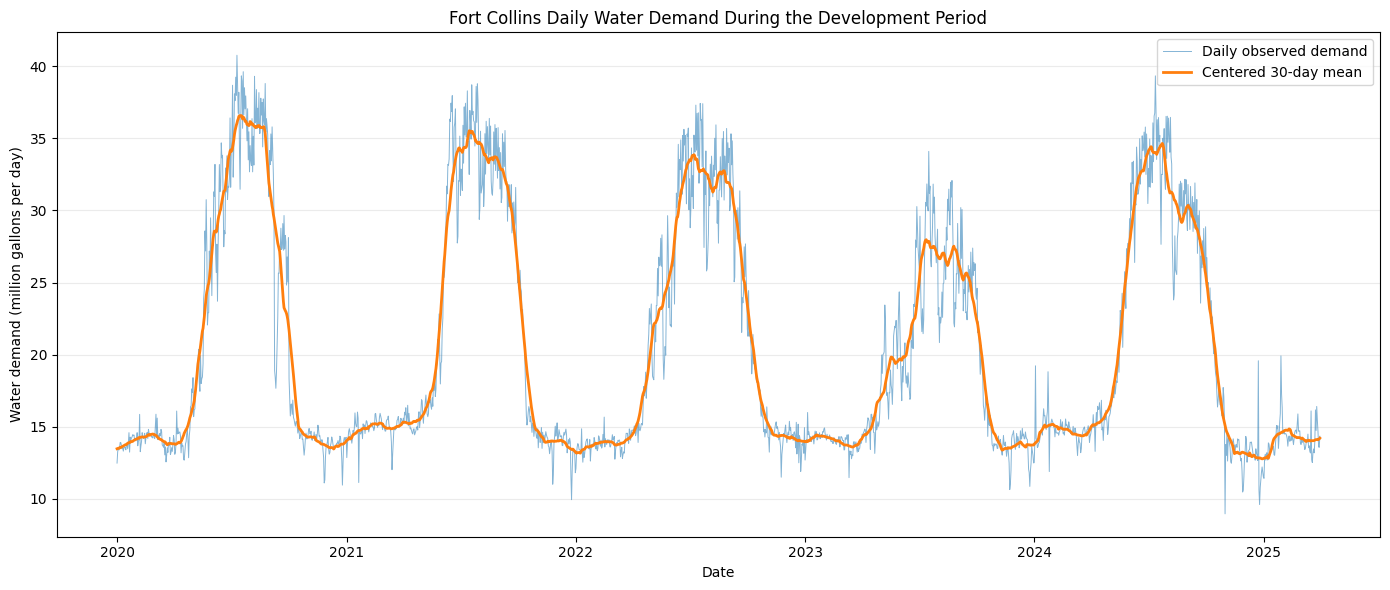

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    development_plot[date_column],
    development_plot[target_column],
    linewidth=0.7,
    alpha=0.55,
    label="Daily observed demand",
)

ax.plot(
    development_plot[date_column],
    development_plot["centered_30_day_mean"],
    linewidth=2.0,
    label="Centered 30-day mean",
)

ax.set_title(
    "Fort Collins Daily Water Demand During the Development Period"
)
ax.set_xlabel("Date")
ax.set_ylabel("Water demand (million gallons per day)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [26]:
largest_demand_days = (
    development[
        [
            date_column,
            target_column,
            "tmax_f",
            "precipitation_in",
            "month",
            "day_of_week",
        ]
    ]
    .nlargest(10, target_column)
    .sort_values(target_column, ascending=False)
)

smallest_demand_days = (
    development[
        [
            date_column,
            target_column,
            "tmin_f",
            "snowfall_in",
            "month",
            "day_of_week",
        ]
    ]
    .nsmallest(10, target_column)
    .sort_values(target_column)
)

print("Largest observed demand values:")
display(largest_demand_days)

print("Smallest observed demand values:")
display(smallest_demand_days)

Largest observed demand values:


,date,water_demand_mgd,tmax_f,precipitation_in,month,day_of_week
191,2020-07-10,40.77,99,0.0,7,4
201,2020-07-20,39.63,90,0.0,7,0
198,2020-07-17,39.34,95,0.0,7,4
1654,2024-07-12,39.34,102,0.0,7,4
219,2020-08-07,39.31,95,0.0,8,4
189,2020-07-08,39.25,95,0.0,7,2
199,2020-07-18,38.98,96,0.0,7,5
236,2020-08-24,38.81,95,0.0,8,0
574,2021-07-28,38.79,97,0.0,7,2
565,2021-07-19,38.72,93,0.0,7,0


Smallest observed demand values:


,date,water_demand_mgd,tmin_f,snowfall_in,month,day_of_week
1765,2024-10-31,8.95,30,0.0,10,3
1820,2024-12-25,9.59,30,0.0,12,2
724,2021-12-25,9.93,29,0.0,12,5
1793,2024-11-28,10.46,17,0.0,11,3
1819,2024-12-24,10.59,25,0.0,12,1
1794,2024-11-29,10.60,15,0.0,11,4
1422,2023-11-23,10.63,29,0.0,11,3
1821,2024-12-26,10.78,25,0.0,12,3
1454,2023-12-25,10.85,15,0.0,12,0
359,2020-12-25,10.94,18,0.0,12,4


In [27]:
complete_year_summary = (
    annual_summary.loc[
        annual_summary["period_status"] == "Complete calendar year"
    ]
    .copy()
    .reset_index(drop=True)
)

complete_year_summary["change_in_annual_mean"] = (
    complete_year_summary["mean"].diff()
)

complete_year_summary["percent_change_in_annual_mean"] = (
    complete_year_summary["mean"].pct_change() * 100
)

display(
    complete_year_summary[
        [
            "year",
            "observations",
            "mean",
            "median",
            "standard_deviation",
            "change_in_annual_mean",
            "percent_change_in_annual_mean",
        ]
    ].round(3)
)

,year,observations,mean,median,standard_deviation,change_in_annual_mean,percent_change_in_annual_mean
0,2020,366,20.928,14.805,9.077,NaN,NaN
1,2021,365,21.272,15.730,8.682,0.344,1.642
2,2022,365,21.121,17.410,8.040,-0.151,-0.709
3,2023,365,18.490,15.340,5.698,-2.631,-12.455
4,2024,366,21.013,16.325,8.113,2.523,13.643


### Evidence

The development-period series displays a strong recurring annual cycle.
Demand generally remains near its lowest levels during winter, rises rapidly
during late spring and reaches its highest levels during summer. Daily
variability is also considerably greater during the high-demand season.

Average demand is similar across 2020, 2021, 2022 and 2024, providing little
evidence of a simple monotonic trend. The 2023 cycle is noticeably lower and
less variable, however, indicating that the amplitude of seasonal demand
changes across years.

All ten largest observations occur during July or August on days with maximum
temperatures between 90 and 102 degrees Fahrenheit and no recorded
precipitation. This supports examining weather as a candidate feature group,
although the pattern may partly reflect annual seasonality.

The smallest observations are concentrated in late autumn and winter. Several
occur on Christmas, Thanksgiving or adjacent dates, suggesting that known-ahead
holiday effects may not be fully represented by month, weekday and weekend
variables alone.

The extreme observations generally have seasonal or calendar context and are
not treated as errors or removed at this stage.

### Provisional modeling implications

- Retain annual calendar structure and seasonal naïve forecasts.
- Examine seasonal variation before choosing the final calendar encoding.
- Carry temperature and precipitation forward as candidate predictors, while
  testing whether they add value beyond calendar and demand-history features.
- Add federal-holiday and adjacent-day indicators to the provisional feature
  discussion.
- Evaluate performance across rolling windows and eventually by season because
  forecast difficulty may differ between low- and high-demand periods.
- Do not assume that a simple linear time trend is necessary.
- Retain all observed demand values unless later validation reveals a documented
  data-quality problem.
- Carry observed federal-holiday and adjacent-day indicators into the broad
  candidate feature matrix.
- Treat holiday dates as known-ahead calendar information.
- Do not assume that all federal holidays have the same relationship with
  demand.
- Test whether holiday indicators improve rolling-validation performance after
  month, weekday and seasonal effects are included.
- Before finalizing the features, compare holiday-window demand with nearby
  same-weekday observations to reduce seasonal and weekday confounding.

### Open questions

- How do the demand distributions differ by month?
- Is there a meaningful weekday or weekend pattern after accounting
  descriptively for season?
- How consistently do holidays and adjacent dates correspond to unusually low
  demand?
- Does temperature explain within-season variation rather than merely the
  annual cycle?
- Which demand lags capture the short-term persistence visible in the daily
  series?


In [34]:
holiday_calendar = USFederalHolidayCalendar()

federal_holidays = pd.DatetimeIndex(
    holiday_calendar.holidays(
        start=development[date_column].min(),
        end=development[date_column].max(),
    )
)

calendar_check = development[
    [date_column, target_column, "month", "day_of_week"]
].copy()

calendar_check["is_federal_holiday"] = (
    calendar_check[date_column].isin(federal_holidays)
)

calendar_check["is_day_before_federal_holiday"] = (
    (calendar_check[date_column] + pd.Timedelta(days=1))
    .isin(federal_holidays)
)

calendar_check["is_day_after_federal_holiday"] = (
    (calendar_check[date_column] - pd.Timedelta(days=1))
    .isin(federal_holidays)
)

calendar_check["holiday_window"] = (
    calendar_check[
        [
            "is_federal_holiday",
            "is_day_before_federal_holiday",
            "is_day_after_federal_holiday",
        ]
    ]
    .any(axis=1)
)

In [35]:
holiday_summary = (
    calendar_check
    .groupby("holiday_window")[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .rename(index={
        False: "Other dates",
        True: "Federal holiday or adjacent date",
    })
)

display(holiday_summary.round(3))

,observations,mean,median,minimum,maximum
holiday_window,,,,,
Other dates,1747,20.397,15.52,8.95,40.77
Federal holiday or adjacent date,170,18.906,14.61,9.59,38.69


In [36]:
lowest_20_calendar_check = (
    calendar_check
    .nsmallest(20, target_column)
    .sort_values(target_column)
)

display(lowest_20_calendar_check)

,date,water_demand_mgd,month,day_of_week,is_federal_holiday,is_day_before_federal_holiday,is_day_after_federal_holiday,holiday_window
1765,2024-10-31,8.95,10,3,False,False,False,False
1820,2024-12-25,9.59,12,2,True,False,False,True
724,2021-12-25,9.93,12,5,False,False,True,True
1793,2024-11-28,10.46,11,3,True,False,False,True
1819,2024-12-24,10.59,12,1,False,True,False,True
1794,2024-11-29,10.60,11,4,False,False,True,True
1422,2023-11-23,10.63,11,3,True,False,False,True
1821,2024-12-26,10.78,12,3,False,False,True,True
1454,2023-12-25,10.85,12,0,True,False,False,True
359,2020-12-25,10.94,12,4,True,False,False,True


### Holiday diagnostic

Federal holidays and their immediately adjacent dates account for 170 of the
1,917 development-period observations, or approximately 8.9%. They account for
15 of the 20 lowest-demand observations, however.

Mean demand is 1.491 million gallons per day lower within the holiday window
than on other dates. Median demand is 0.91 million gallons per day lower. The
lowest observations repeatedly include Thanksgiving, Christmas, New Year's Day
and dates immediately adjacent to Thanksgiving and Christmas across multiple
years.

This concentration supports carrying known-ahead holiday indicators into the
provisional feature set. The comparison does not isolate a holiday effect,
because holidays are seasonally concentrated and may differ substantially from
one another. A later diagnostic will compare holiday-window observations with
nearby dates having similar weekday and seasonal context.

The federal calendar used here records observed holiday dates. For example,
Christmas Day 2021 is represented as the day after the observed federal holiday
on December 24. Final feature names and documentation will make this convention
explicit.


## 6. Monthly and weekly calendar patterns

The overall time-series plot suggests strong annual seasonality and possible
weekly calendar effects. This section summarizes demand by month and day of
week using only the development period.

Monthly distributions are used to examine the timing, magnitude and variability
of the annual demand cycle. The weekday profile is also recalculated after
excluding federal holidays and adjacent dates so that repeated holiday lows do
not create a misleading weekday pattern.

In [28]:
month_labels = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}

weekday_labels = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

In [29]:
monthly_summary = (
    development
    .groupby("month")[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
        minimum="min",
        maximum="max",
    )
    .reindex(range(1, 13))
)

monthly_summary["interquartile_range"] = (
    monthly_summary["third_quartile"]
    - monthly_summary["first_quartile"]
)

monthly_summary.insert(
    0,
    "month_name",
    [month_labels[month] for month in monthly_summary.index],
)

display(
    monthly_summary.round(
        {
            "mean": 3,
            "median": 3,
            "standard_deviation": 3,
            "first_quartile": 3,
            "third_quartile": 3,
            "interquartile_range": 3,
            "minimum": 3,
            "maximum": 3,
        }
    )
)

,month_name,observations,mean,median,standard_deviation,first_quartile,third_quartile,minimum,maximum,interquartile_range
month,,,,,,,,,,
1,Jan,186,14.207,14.14,1.126,13.550,14.650,11.12,19.91,1.100
2,Feb,170,14.473,14.43,0.581,14.045,14.878,13.26,15.92,0.833
3,Mar,186,14.121,14.05,0.813,13.560,14.685,11.46,16.40,1.125
4,Apr,150,15.353,15.01,1.657,14.580,15.825,12.67,23.20,1.245
5,May,155,20.637,19.71,3.790,17.535,23.325,15.23,30.75,5.790
6,Jun,150,29.251,31.03,5.567,26.300,33.488,16.80,37.97,7.187
7,Jul,155,33.297,34.10,4.095,31.150,36.400,21.45,40.77,5.250
8,Aug,155,31.624,32.16,4.178,29.605,35.055,20.83,39.31,5.450
9,Sep,150,28.263,28.41,3.645,25.880,30.545,17.66,35.80,4.665


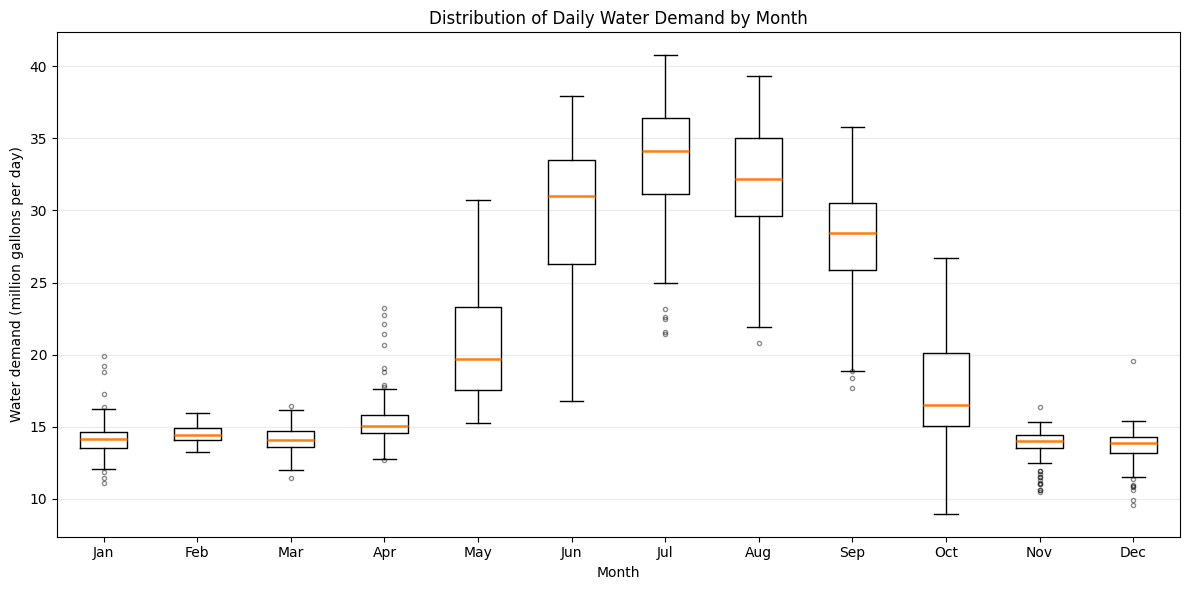

In [30]:
monthly_values = [
    development.loc[
        development["month"] == month,
        target_column,
    ].to_numpy()
    for month in range(1, 13)
]

fig, ax = plt.subplots(figsize=(12, 6))

boxplot = ax.boxplot(
    monthly_values,
    tick_labels=[
        month_labels[month]
        for month in range(1, 13)
    ],
    showfliers=True,
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.45,
    },
    medianprops={
        "linewidth": 1.8,
    },
)

ax.set_title(
    "Distribution of Daily Water Demand by Month"
)
ax.set_xlabel("Month")
ax.set_ylabel(
    "Water demand (million gallons per day)"
)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [31]:
weekday_summary = (
    development
    .groupby("day_of_week")[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
        minimum="min",
        maximum="max",
    )
    .reindex(range(7))
)

weekday_summary["interquartile_range"] = (
    weekday_summary["third_quartile"]
    - weekday_summary["first_quartile"]
)

weekday_summary.insert(
    0,
    "weekday",
    [
        weekday_labels[day]
        for day in weekday_summary.index
    ],
)

display(
    weekday_summary.round(
        {
            "mean": 3,
            "median": 3,
            "standard_deviation": 3,
            "first_quartile": 3,
            "third_quartile": 3,
            "interquartile_range": 3,
            "minimum": 3,
            "maximum": 3,
        }
    )
)

,weekday,observations,mean,median,standard_deviation,first_quartile,third_quartile,minimum,maximum,interquartile_range
day_of_week,,,,,,,,,,
0,Mon,274,20.934,15.860,8.514,14.350,28.197,10.85,39.63,13.847
1,Tue,273,20.168,15.690,7.590,14.270,26.120,10.59,37.62,11.850
2,Wed,274,20.820,15.630,8.436,14.252,28.057,9.59,39.25,13.805
3,Thu,274,20.039,15.590,7.740,14.195,26.643,8.95,37.99,12.448
4,Fri,274,20.521,15.110,8.581,14.040,27.697,10.60,40.77,13.657
5,Sat,274,19.722,15.045,7.695,13.818,26.775,9.93,38.98,12.957
6,Sun,274,19.650,15.300,7.303,14.110,25.610,11.46,36.74,11.500


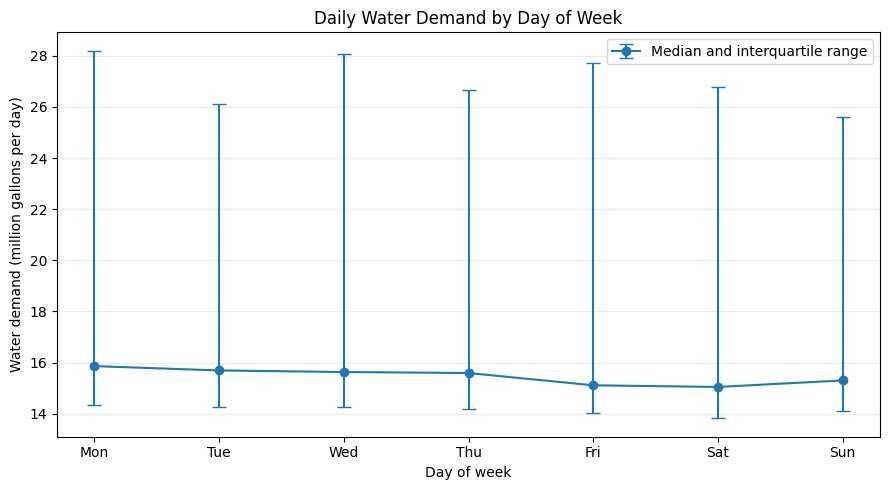

In [32]:
weekday_plot = weekday_summary.reset_index()

weekday_medians = weekday_plot["median"].to_numpy()

weekday_lower_errors = (
    weekday_plot["median"]
    - weekday_plot["first_quartile"]
).to_numpy()

weekday_upper_errors = (
    weekday_plot["third_quartile"]
    - weekday_plot["median"]
).to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    np.arange(7),
    weekday_medians,
    yerr=np.vstack(
        [
            weekday_lower_errors,
            weekday_upper_errors,
        ]
    ),
    fmt="o-",
    linewidth=1.5,
    markersize=6,
    capsize=5,
    label="Median and interquartile range",
)

ax.set_xticks(
    np.arange(7),
    weekday_plot["weekday"],
)

ax.set_title(
    "Daily Water Demand by Day of Week"
)
ax.set_xlabel("Day of week")
ax.set_ylabel(
    "Water demand (million gallons per day)"
)
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [37]:
weekday_all_dates = (
    calendar_check
    .groupby("day_of_week")[target_column]
    .agg(
        all_dates_mean="mean",
        all_dates_median="median",
        all_dates_observations="count",
    )
)

weekday_nonholiday = (
    calendar_check.loc[
        ~calendar_check["holiday_window"]
    ]
    .groupby("day_of_week")[target_column]
    .agg(
        nonholiday_mean="mean",
        nonholiday_median="median",
        nonholiday_observations="count",
    )
)

weekday_holiday_sensitivity = (
    weekday_all_dates
    .join(weekday_nonholiday)
    .reindex(range(7))
)

weekday_holiday_sensitivity.insert(
    0,
    "weekday",
    [
        weekday_labels[day]
        for day in weekday_holiday_sensitivity.index
    ],
)

weekday_holiday_sensitivity[
    "change_in_mean_after_exclusion"
] = (
    weekday_holiday_sensitivity["nonholiday_mean"]
    - weekday_holiday_sensitivity["all_dates_mean"]
)

weekday_holiday_sensitivity[
    "change_in_median_after_exclusion"
] = (
    weekday_holiday_sensitivity["nonholiday_median"]
    - weekday_holiday_sensitivity["all_dates_median"]
)

display(
    weekday_holiday_sensitivity.round(3)
)

,weekday,all_dates_mean,all_dates_median,all_dates_observations,nonholiday_mean,nonholiday_median,nonholiday_observations,change_in_mean_after_exclusion,change_in_median_after_exclusion
day_of_week,,,,,,,,,
0,Mon,20.934,15.860,274,20.961,15.790,237,0.028,-0.070
1,Tue,20.168,15.690,273,20.268,15.635,232,0.100,-0.055
2,Wed,20.820,15.630,274,21.027,15.730,261,0.207,0.100
3,Thu,20.039,15.590,274,20.283,15.800,254,0.245,0.210
4,Fri,20.521,15.110,274,20.718,15.210,259,0.197,0.100
5,Sat,19.722,15.045,274,19.782,15.125,266,0.060,0.080
6,Sun,19.650,15.300,274,19.730,15.300,238,0.080,0.000


In [38]:
weekend_summary = (
    development
    .groupby("is_weekend")[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
    .rename(
        index={
            0: "Weekday",
            1: "Weekend",
        }
    )
)

display(weekend_summary.round(3))

,observations,mean,median,standard_deviation,first_quartile,third_quartile
is_weekend,,,,,,
Weekday,1369,20.496,15.59,8.179,14.210,27.56
Weekend,548,19.686,15.19,7.494,13.955,26.25


In [39]:
monthly_median_ranking = (
    monthly_summary[
        [
            "month_name",
            "observations",
            "median",
            "interquartile_range",
        ]
    ]
    .sort_values(
        "median",
        ascending=False,
    )
)

display(monthly_median_ranking.round(3))

,month_name,observations,median,interquartile_range
month,,,,
7,Jul,155,34.10,5.250
8,Aug,155,32.16,5.450
6,Jun,150,31.03,7.187
9,Sep,150,28.41,4.665
5,May,155,19.71,5.790
10,Oct,155,16.53,5.080
4,Apr,150,15.01,1.245
2,Feb,170,14.43,0.833
1,Jan,186,14.14,1.100


### Evidence

Daily water demand displays pronounced annual seasonality. Demand is low and
tightly concentrated from November through March, begins increasing in May and
reaches its highest monthly median in July. Demand remains elevated through
September before declining sharply during October.

The annual pattern is not a constant-width or perfectly smooth cycle. June and
October have especially wide distributions, indicating that the timing and
magnitude of the seasonal transitions vary across years.

Variability also increases substantially during the high-demand season. Monthly
interquartile ranges are generally near one million gallons per day during
winter but exceed five million gallons per day in several warm-season months.

Differences across weekdays are comparatively small. Median demand varies by
less than one million gallons per day across the seven weekdays and the
interquartile ranges overlap heavily. Weekend demand is slightly lower than
weekday demand, but the difference is modest relative to annual seasonality.

Removing federal holidays and adjacent dates changes weekday medians only
slightly. Holiday windows therefore contribute to particular low-demand
observations but do not explain the overall weekday profile.

### Provisional modeling implications

- Include annual calendar structure in all supervised forecasting baselines.
- Compare month indicators with one or more cyclical day-of-year
  representations under rolling validation.
- Retain day of week as a candidate known-ahead feature, while recognizing that
  its descriptive effect is modest.
- Compare a simple weekend indicator with a fuller weekday encoding rather than
  including both redundantly.
- Carry holiday and adjacent-day indicators forward as a separate known-ahead
  feature family.
- Report model performance by season or month in addition to aggregate
  performance because demand variability changes substantially throughout the
  year.
- Do not assume that one annual sine-cosine pair will fully represent the sharp
  spring and autumn transitions.
- Use a nonredundant day-of-week encoding as the primary calendar candidate.
- Retain the weekend indicator as a simpler alternative rather than including
  it alongside the full weekday encoding.
- Treat weekday effects as secondary to annual seasonality.
- Retain holiday indicators separately because they capture specific dates
  rather than the broader weekly pattern.

### Open questions

- Does a weekday effect remain after accounting more directly for month or
  annual seasonality?
- Which annual encoding provides the best balance between flexibility,
  interpretability and numerical stability?
- Do holiday indicators improve forecasts after month and weekday effects have
  been included?
- Which demand lags capture the short-term persistence that remains after
  seasonal structure is considered?

In [40]:
calendar_adjusted = development[
    [date_column, target_column, "month", "day_of_week"]
].copy()

monthly_medians = (
    calendar_adjusted
    .groupby("month")[target_column]
    .transform("median")
)

calendar_adjusted["demand_minus_month_median"] = (
    calendar_adjusted[target_column] - monthly_medians
)

adjusted_weekday_summary = (
    calendar_adjusted
    .groupby("day_of_week")["demand_minus_month_median"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
    .reindex(range(7))
)

adjusted_weekday_summary.insert(
    0,
    "weekday",
    [
        weekday_labels[day]
        for day in adjusted_weekday_summary.index
    ],
)

display(adjusted_weekday_summary.round(3))

,weekday,observations,mean,median,first_quartile,third_quartile
day_of_week,,,,,,
0,Mon,274,0.578,0.300,-0.578,1.790
1,Tue,273,-0.177,0.030,-0.840,0.770
2,Wed,274,0.447,0.230,-0.595,1.587
3,Thu,274,-0.327,-0.045,-1.145,0.815
4,Fri,274,0.191,-0.015,-0.837,1.102
5,Sat,274,-0.633,-0.470,-1.467,0.360
6,Sun,274,-0.647,-0.185,-1.438,0.647


### Month-adjusted weekday diagnostic

After subtracting the median demand for each calendar month, weekday differences
remain modest but do not disappear completely. Monday and Wednesday have
slightly positive adjusted medians, while Saturday and Sunday have lower
adjusted values. The largest adjusted median difference is approximately 0.77
million gallons per day, between Monday and Saturday.

The interquartile ranges overlap substantially, so weekday effects remain much
smaller than annual seasonal effects. Differences in adjusted means are
somewhat larger than differences in medians, suggesting that weekday patterns
may be more pronounced among high-demand observations.

This diagnostic removes only a coarse monthly level. It does not control for
within-month seasonality, weather, year-to-year variation or recent demand.
Day-of-week information will therefore remain a known-ahead candidate whose
incremental forecasting value must be evaluated chronologically.

## 7. Demand persistence and candidate lags

One-day-ahead forecasting is likely to benefit from recent demand history.
However, autocorrelation in the raw demand series may reflect both genuine
short-term persistence and the broader annual cycle.

This section therefore examines autocorrelation in two series:

- observed daily demand
- demand after subtracting the median for its calendar month

The month-adjusted series is a descriptive diagnostic only. It uses the entire
development period and will not be included as a forecasting feature.
Candidate lags will later be constructed directly from prior observed demand
within each chronological training window.

In [41]:
candidate_demand_lags = config[
    "features"
]["candidate_demand_lags_days"]

print("Configured candidate demand lags:")
print(candidate_demand_lags)

assert candidate_demand_lags == [1, 2, 3, 7, 14, 28]
assert all(lag > 0 for lag in candidate_demand_lags)

print("All candidate lags refer to prior observations.")

Configured candidate demand lags:
[1, 2, 3, 7, 14, 28]
All candidate lags refer to prior observations.


In [42]:
lag_diagnostics = development[
    [
        date_column,
        target_column,
        "month",
    ]
].copy()

lag_diagnostics["monthly_median"] = (
    lag_diagnostics
    .groupby("month")[target_column]
    .transform("median")
)

lag_diagnostics["month_adjusted_demand"] = (
    lag_diagnostics[target_column]
    - lag_diagnostics["monthly_median"]
)

display(lag_diagnostics.head())

,date,water_demand_mgd,month,monthly_median,month_adjusted_demand
0,2020-01-01,12.47,1,14.14,-1.67
1,2020-01-02,13.24,1,14.14,-0.90
2,2020-01-03,13.57,1,14.14,-0.57
3,2020-01-04,13.38,1,14.14,-0.76
4,2020-01-05,13.52,1,14.14,-0.62


In [43]:
adjusted_month_check = (
    lag_diagnostics
    .groupby("month")["month_adjusted_demand"]
    .median()
    .rename("adjusted_median")
    .to_frame()
)

display(adjusted_month_check.round(10))

assert np.allclose(
    adjusted_month_check["adjusted_median"],
    0.0,
    atol=1e-10,
)

print("Month-adjustment check passed.")

,adjusted_median
month,
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,-0.0
7,0.0
8,0.0
9,0.0


Month-adjustment check passed.


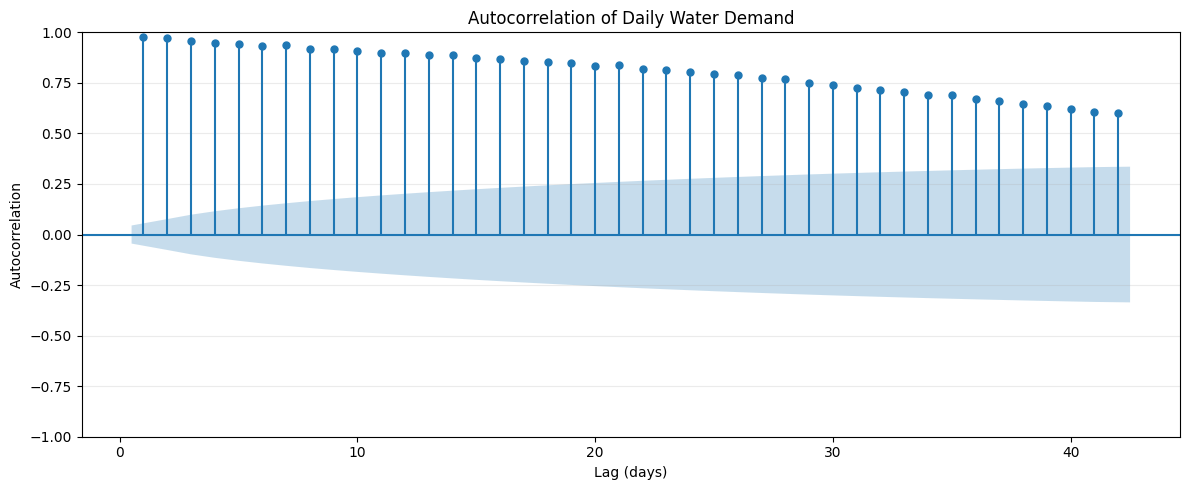

In [44]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    lag_diagnostics[target_column],
    lags=42,
    zero=False,
    alpha=0.05,
    fft=True,
    ax=ax,
)

ax.set_title(
    "Autocorrelation of Daily Water Demand"
)
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

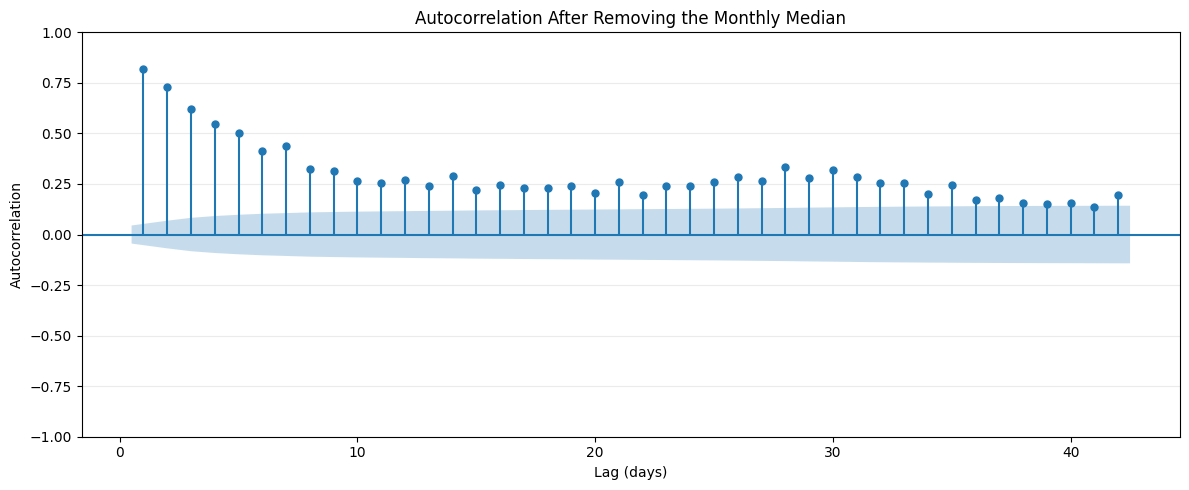

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    lag_diagnostics["month_adjusted_demand"],
    lags=42,
    zero=False,
    alpha=0.05,
    fft=True,
    ax=ax,
)

ax.set_title(
    "Autocorrelation After Removing the Monthly Median"
)
ax.set_xlabel("Lag (days)")
ax.set_ylabel("Autocorrelation")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [46]:
lag_summary_rows = []

for lag in candidate_demand_lags:
    raw_pair = pd.DataFrame(
        {
            "current": lag_diagnostics[target_column],
            "lagged": lag_diagnostics[target_column].shift(lag),
        }
    ).dropna()

    adjusted_pair = pd.DataFrame(
        {
            "current": lag_diagnostics["month_adjusted_demand"],
            "lagged": (
                lag_diagnostics["month_adjusted_demand"]
                .shift(lag)
            ),
        }
    ).dropna()

    lag_summary_rows.append(
        {
            "lag_days": lag,
            "paired_observations": len(raw_pair),
            "raw_autocorrelation": raw_pair[
                "current"
            ].corr(raw_pair["lagged"]),
            "month_adjusted_autocorrelation": adjusted_pair[
                "current"
            ].corr(adjusted_pair["lagged"]),
        }
    )

candidate_lag_summary = pd.DataFrame(lag_summary_rows)

display(candidate_lag_summary.round(4))

,lag_days,paired_observations,raw_autocorrelation,month_adjusted_autocorrelation
0,1,1916,0.9777,0.8171
1,2,1915,0.9706,0.7318
2,3,1914,0.9572,0.6189
3,7,1910,0.9376,0.4363
4,14,1903,0.8930,0.2913
5,28,1889,0.7772,0.3334


In [47]:
for row in candidate_lag_summary.itertuples():
    assert row.paired_observations == len(development) - row.lag_days

print("Lag alignment checks passed.")

Lag alignment checks passed.


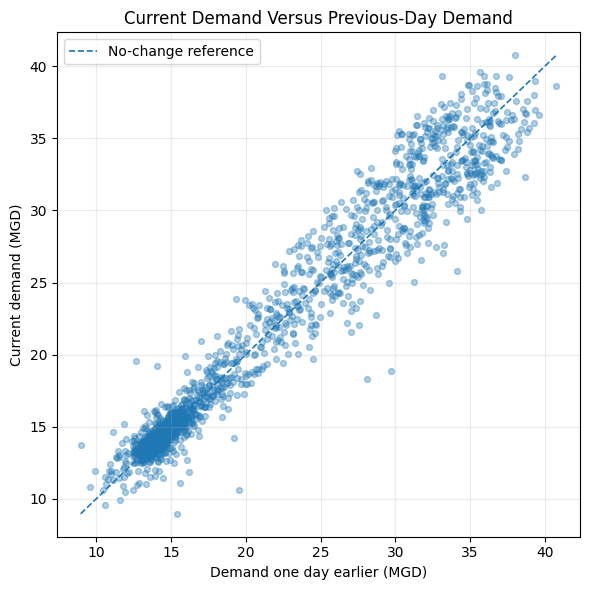

In [48]:
lag_1_plot = pd.DataFrame(
    {
        "current_demand": lag_diagnostics[target_column],
        "lagged_demand": lag_diagnostics[target_column].shift(1),
    }
).dropna()

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    lag_1_plot["lagged_demand"],
    lag_1_plot["current_demand"],
    alpha=0.35,
    s=18,
)

plot_min = min(
    lag_1_plot["lagged_demand"].min(),
    lag_1_plot["current_demand"].min(),
)
plot_max = max(
    lag_1_plot["lagged_demand"].max(),
    lag_1_plot["current_demand"].max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.2,
    label="No-change reference",
)

ax.set_title("Current Demand Versus Previous-Day Demand")
ax.set_xlabel("Demand one day earlier (MGD)")
ax.set_ylabel("Current demand (MGD)")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

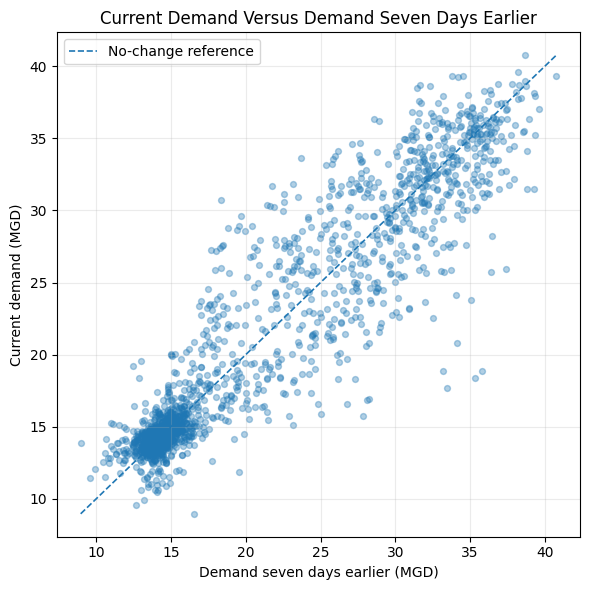

In [49]:
lag_7_plot = pd.DataFrame(
    {
        "current_demand": lag_diagnostics[target_column],
        "lagged_demand": lag_diagnostics[target_column].shift(7),
    }
).dropna()

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    lag_7_plot["lagged_demand"],
    lag_7_plot["current_demand"],
    alpha=0.35,
    s=18,
)

plot_min = min(
    lag_7_plot["lagged_demand"].min(),
    lag_7_plot["current_demand"].min(),
)
plot_max = max(
    lag_7_plot["lagged_demand"].max(),
    lag_7_plot["current_demand"].max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.2,
    label="No-change reference",
)

ax.set_title("Current Demand Versus Demand Seven Days Earlier")
ax.set_xlabel("Demand seven days earlier (MGD)")
ax.set_ylabel("Current demand (MGD)")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [50]:
lag_alignment_example = development[
    [date_column, target_column]
].head(10).copy()

lag_alignment_example["demand_lag_1"] = (
    lag_alignment_example[target_column].shift(1)
)

lag_alignment_example["demand_lag_7"] = (
    lag_alignment_example[target_column].shift(7)
)

display(lag_alignment_example)

,date,water_demand_mgd,demand_lag_1,demand_lag_7
0,2020-01-01,12.47,NaN,NaN
1,2020-01-02,13.24,12.47,NaN
2,2020-01-03,13.57,13.24,NaN
3,2020-01-04,13.38,13.57,NaN
4,2020-01-05,13.52,13.38,NaN
5,2020-01-06,13.90,13.52,NaN
6,2020-01-07,13.89,13.90,NaN
7,2020-01-08,13.67,13.89,12.47
8,2020-01-09,13.46,13.67,13.24
9,2020-01-10,13.52,13.46,13.57


### Evidence

Daily water demand is highly persistent. Raw autocorrelation is approximately
0.98 at lag one and declines slowly because the series contains strong annual
seasonality and extended high- and low-demand periods.

After subtracting each month's median, substantial short-term dependence
remains. Month-adjusted autocorrelation is approximately 0.82 at lag one,
0.73 at lag two and 0.62 at lag three. It declines to approximately 0.44 at
lag seven but remains positive through the longer candidate lags.

The previous-day scatterplot is tightly concentrated around the no-change
reference, confirming that yesterday's demand is a strong predictor. The
seven-day relationship is also clear but substantially more dispersed, which
supports a weekly seasonal benchmark while indicating that weekly persistence
is weaker than immediate day-to-day persistence.

Both scatterplots become more dispersed at higher demand levels. This is
consistent with the earlier finding that high-demand periods exhibit greater
variability and may be more difficult to forecast.

The adjusted autocorrelation does not show an overwhelmingly dominant
seven-day cycle. Weekly persistence is present, but nearby demand and broader
seasonal evolution also contribute to the observed dependence.

### Provisional modeling implications

- Retain the previous-day naïve forecast as a primary benchmark.
- Retain the same-day-previous-week forecast as a seasonal naïve benchmark.
- Include lag one in every lagged-demand model.
- Carry lags two and three into the broad engineered matrix because they remain
  strongly correlated with current demand, while recognizing that they may be
  redundant after lag one is included.
- Retain lags seven, fourteen and twenty-eight as candidates representing
  weekly and longer-horizon persistence.
- Use rolling validation rather than marginal correlation to determine which
  lags provide incremental predictive value.
- Expect nearby lags and overlapping rolling summaries to contribute
  substantially to feature correlation and design-matrix conditioning.
- Evaluate forecast errors by season because lag-based forecasts appear less
  stable during high-demand periods.

### Open questions

- Do lagged weather variables explain some of the departures from the
  no-change relationships?
- Do shifted rolling summaries add predictive information beyond direct lags
  or mostly reproduce the same demand history?
- Which lag subset provides the best rolling-validation performance after
  calendar and weather features are included?
- How much redundancy is introduced when nearby lags and rolling summaries are
  included together?

## 8. Weather relationships and forecast-time availability

Weather is a plausible contributor to municipal water demand, but a raw
association may simply reproduce annual seasonality. Hot days occur primarily
during high-demand months while snow and cold weather occur primarily during
low-demand months.

This section therefore examines:

- same-day weather associations for descriptive understanding
- relationships after removing coarse monthly levels
- precipitation effects within the elevated-demand season
- operationally available lagged-weather candidates

Same-day observed weather is not available when issuing the primary
one-day-ahead operational forecast. It is examined as an optimistic
weather-informed benchmark and as a guide to whether forecasted weather could
eventually be useful.

In [51]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn",
]

season_by_month = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}

weather_eda = development[
    [
        date_column,
        target_column,
        "month",
        "tmax_f",
        "tmin_f",
        "tavg_f",
        "temperature_range_f",
        "precipitation_in",
        "snowfall_in",
        "snow_depth_in",
    ]
].copy()

weather_eda["season"] = pd.Categorical(
    weather_eda["month"].map(season_by_month),
    categories=season_order,
    ordered=True,
)

assert not weather_eda["season"].isna().any()

display(
    weather_eda.groupby(
        "season",
        observed=False,
    ).size().rename("observations").to_frame()
)

,observations
season,
Winter,511
Spring,491
Summer,460
Autumn,455


In [52]:
weather_summary_rows = []

for column in configured_weather_columns:
    values = weather_eda[column]

    weather_summary_rows.append(
        {
            "variable": column,
            "observations": values.notna().sum(),
            "mean": values.mean(),
            "standard_deviation": values.std(),
            "minimum": values.min(),
            "first_quartile": values.quantile(0.25),
            "median": values.median(),
            "third_quartile": values.quantile(0.75),
            "maximum": values.max(),
            "nonzero_observations": int((values != 0).sum()),
            "percent_nonzero": 100 * (values != 0).mean(),
        }
    )

weather_summary = pd.DataFrame(weather_summary_rows)

display(weather_summary.round(3))

,variable,observations,mean,standard_deviation,minimum,first_quartile,median,third_quartile,maximum,nonzero_observations,percent_nonzero
0,tmax_f,1917,65.200,19.289,0.0,50.0,65.0,82.0,102.00,1916,99.948
1,tmin_f,1917,36.524,16.642,-17.0,24.0,36.0,51.0,70.00,1916,99.948
2,tavg_f,1917,50.862,17.440,-8.5,37.0,50.5,66.5,83.50,1916,99.948
3,temperature_range_f,1917,28.676,9.027,4.0,22.0,29.0,36.0,51.00,1917,100.000
4,precipitation_in,1917,0.041,0.163,0.0,0.0,0.0,0.0,2.45,418,21.805
5,snowfall_in,1917,0.139,0.815,0.0,0.0,0.0,0.0,16.80,151,7.877
6,snow_depth_in,1917,0.347,1.240,0.0,0.0,0.0,0.0,18.00,232,12.102


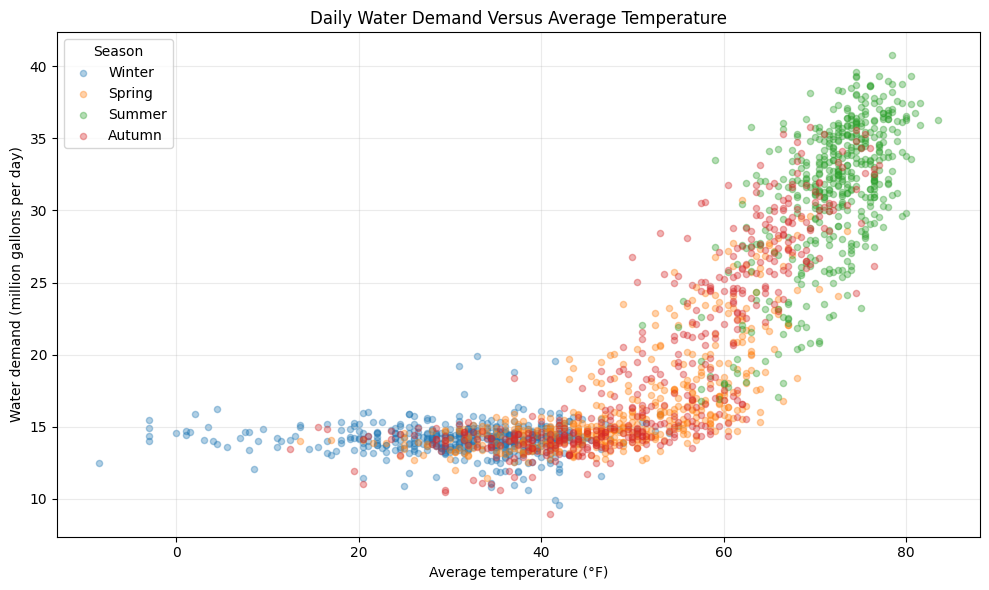

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

for season in season_order:
    season_data = weather_eda.loc[
        weather_eda["season"] == season
    ]

    ax.scatter(
        season_data["tavg_f"],
        season_data[target_column],
        alpha=0.35,
        s=20,
        label=season,
    )

ax.set_title(
    "Daily Water Demand Versus Average Temperature"
)
ax.set_xlabel("Average temperature (°F)")
ax.set_ylabel("Water demand (million gallons per day)")
ax.grid(alpha=0.25)
ax.legend(title="Season")

fig.tight_layout()
plt.show()

In [54]:
temperature_columns = [
    "tmax_f",
    "tmin_f",
    "tavg_f",
    "temperature_range_f",
]

warm_season_months = [5, 6, 7, 8, 9]

temperature_correlation_rows = []

month_adjusted_target = (
    weather_eda[target_column]
    - weather_eda.groupby("month")[target_column].transform("median")
)

for column in temperature_columns:
    month_adjusted_weather = (
        weather_eda[column]
        - weather_eda.groupby("month")[column].transform("median")
    )

    warm_mask = weather_eda["month"].isin(
        warm_season_months
    )

    temperature_correlation_rows.append(
        {
            "variable": column,
            "raw_correlation": weather_eda[
                target_column
            ].corr(weather_eda[column]),
            "may_through_september_correlation": (
                weather_eda.loc[
                    warm_mask,
                    target_column,
                ].corr(
                    weather_eda.loc[
                        warm_mask,
                        column,
                    ]
                )
            ),
            "month_adjusted_correlation": (
                month_adjusted_target.corr(
                    month_adjusted_weather
                )
            ),
        }
    )

temperature_correlations = pd.DataFrame(
    temperature_correlation_rows
)

display(temperature_correlations.round(4))

,variable,raw_correlation,may_through_september_correlation,month_adjusted_correlation
0,tmax_f,0.8051,0.7598,0.3414
1,tmin_f,0.8175,0.6506,0.1927
2,tavg_f,0.8353,0.7851,0.3150
3,temperature_range_f,0.2132,0.3746,0.2372


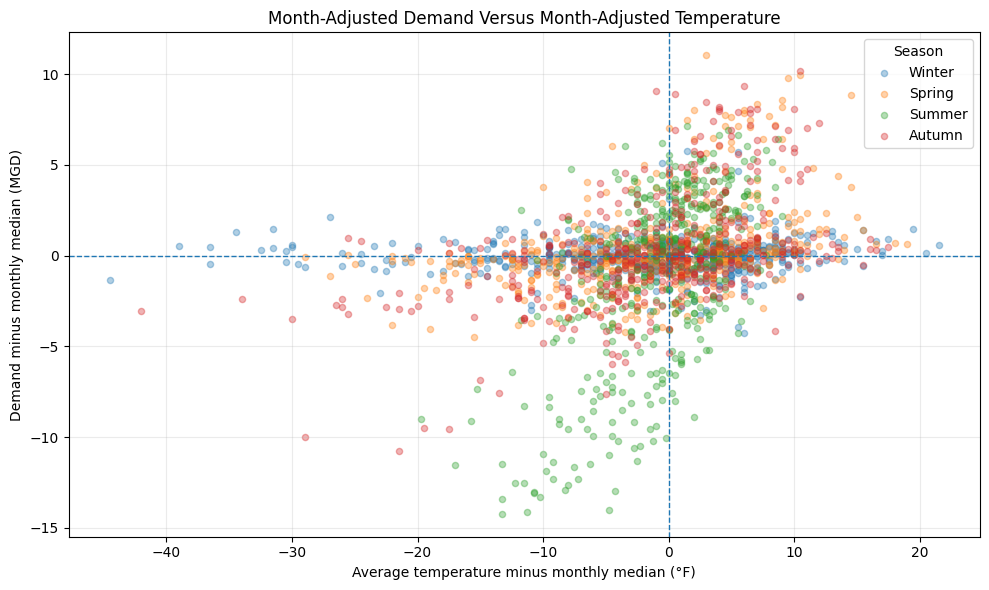

In [55]:
temperature_adjusted_plot = weather_eda[
    [
        "season",
        "month",
        "tavg_f",
        target_column,
    ]
].copy()

temperature_adjusted_plot[
    "demand_minus_month_median"
] = (
    temperature_adjusted_plot[target_column]
    - temperature_adjusted_plot.groupby(
        "month"
    )[target_column].transform("median")
)

temperature_adjusted_plot[
    "temperature_minus_month_median"
] = (
    temperature_adjusted_plot["tavg_f"]
    - temperature_adjusted_plot.groupby(
        "month"
    )["tavg_f"].transform("median")
)

fig, ax = plt.subplots(figsize=(10, 6))

for season in season_order:
    season_data = temperature_adjusted_plot.loc[
        temperature_adjusted_plot["season"] == season
    ]

    ax.scatter(
        season_data["temperature_minus_month_median"],
        season_data["demand_minus_month_median"],
        alpha=0.35,
        s=20,
        label=season,
    )

ax.axhline(0, linewidth=1, linestyle="--")
ax.axvline(0, linewidth=1, linestyle="--")

ax.set_title(
    "Month-Adjusted Demand Versus Month-Adjusted Temperature"
)
ax.set_xlabel(
    "Average temperature minus monthly median (°F)"
)
ax.set_ylabel(
    "Demand minus monthly median (MGD)"
)
ax.grid(alpha=0.25)
ax.legend(title="Season")

fig.tight_layout()
plt.show()

In [56]:
temperature_correlation_matrix = (
    weather_eda[temperature_columns].corr()
)

display(
    temperature_correlation_matrix.round(4)
)

centered_temperature_matrix = (
    weather_eda[temperature_columns]
    - weather_eda[temperature_columns].mean()
).to_numpy()

temperature_rank = np.linalg.matrix_rank(
    centered_temperature_matrix
)

print(
    "Number of temperature columns:",
    len(temperature_columns),
)
print(
    "Numerical rank of centered temperature matrix:",
    temperature_rank,
)

,tmax_f,tmin_f,tavg_f,temperature_range_f
tmax_f,1.0000,0.8840,0.9748,0.5071
tmin_f,0.8840,1.0000,0.9660,0.0453
tavg_f,0.9748,0.9660,1.0000,0.3021
temperature_range_f,0.5071,0.0453,0.3021,1.0000


Number of temperature columns: 4
Numerical rank of centered temperature matrix: 2


In [57]:
weather_eda["precipitation_status"] = np.where(
    weather_eda["precipitation_in"] > 0,
    "Recorded precipitation",
    "No recorded precipitation",
)

precipitation_by_season = (
    weather_eda
    .groupby(
        [
            "season",
            "precipitation_status",
        ],
        observed=False,
    )[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
    .reset_index()
)

display(precipitation_by_season.round(3))

,season,precipitation_status,observations,mean,median,standard_deviation,first_quartile,third_quartile
0,Winter,No recorded precipitation,429,14.133,14.160,1.084,13.630,14.640
1,Winter,Recorded precipitation,82,14.061,14.165,0.801,13.662,14.567
2,Spring,No recorded precipitation,354,16.701,15.190,3.793,14.238,17.725
3,Spring,Recorded precipitation,137,16.173,14.920,3.363,13.990,17.450
4,Summer,No recorded precipitation,327,32.430,33.210,4.374,30.285,35.565
5,Summer,Recorded precipitation,133,28.916,30.480,5.324,25.700,32.500
6,Autumn,No recorded precipitation,389,19.821,16.370,6.738,14.300,25.850
7,Autumn,Recorded precipitation,66,20.338,18.860,7.048,14.125,25.695


Warm-season dry days: 550
Warm-season precipitation days: 215


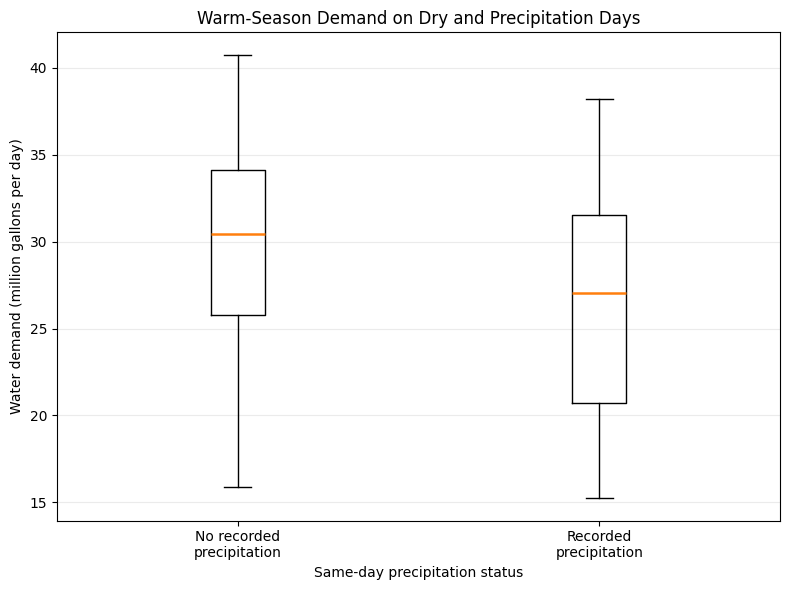

In [58]:
warm_weather = weather_eda.loc[
    weather_eda["month"].isin(
        warm_season_months
    )
].copy()

warm_precipitation_groups = [
    warm_weather.loc[
        warm_weather["precipitation_status"]
        == "No recorded precipitation",
        target_column,
    ].to_numpy(),
    warm_weather.loc[
        warm_weather["precipitation_status"]
        == "Recorded precipitation",
        target_column,
    ].to_numpy(),
]

print(
    "Warm-season dry days:",
    len(warm_precipitation_groups[0]),
)
print(
    "Warm-season precipitation days:",
    len(warm_precipitation_groups[1]),
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    warm_precipitation_groups,
    tick_labels=[
        "No recorded\nprecipitation",
        "Recorded\nprecipitation",
    ],
    showfliers=True,
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.45,
    },
    medianprops={
        "linewidth": 1.8,
    },
)

ax.set_title(
    "Warm-Season Demand on Dry and Precipitation Days"
)
ax.set_xlabel("Same-day precipitation status")
ax.set_ylabel("Water demand (million gallons per day)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

In [59]:
warm_precipitation_summary = (
    warm_weather
    .groupby(
        "precipitation_status"
    )[target_column]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        first_quartile=lambda values: values.quantile(0.25),
        third_quartile=lambda values: values.quantile(0.75),
    )
)

display(warm_precipitation_summary.round(3))

,observations,mean,median,standard_deviation,first_quartile,third_quartile
precipitation_status,,,,,,
No recorded precipitation,550,29.522,30.44,5.853,25.755,34.145
Recorded precipitation,215,26.286,27.02,6.265,20.720,31.560


In [60]:
snow_summary_rows = []

for column in [
    "snowfall_in",
    "snow_depth_in",
]:
    nonzero_mask = weather_eda[column] > 0

    snow_summary_rows.append(
        {
            "variable": column,
            "nonzero_days": int(nonzero_mask.sum()),
            "percent_nonzero": 100 * nonzero_mask.mean(),
            "mean_demand_nonzero_days": (
                weather_eda.loc[
                    nonzero_mask,
                    target_column,
                ].mean()
            ),
            "median_demand_nonzero_days": (
                weather_eda.loc[
                    nonzero_mask,
                    target_column,
                ].median()
            ),
            "mean_demand_zero_days": (
                weather_eda.loc[
                    ~nonzero_mask,
                    target_column,
                ].mean()
            ),
            "median_demand_zero_days": (
                weather_eda.loc[
                    ~nonzero_mask,
                    target_column,
                ].median()
            ),
        }
    )

snow_occurrence_summary = pd.DataFrame(
    snow_summary_rows
)

display(snow_occurrence_summary.round(3))

,variable,nonzero_days,percent_nonzero,mean_demand_nonzero_days,median_demand_nonzero_days,mean_demand_zero_days,median_demand_zero_days
0,snowfall_in,151,7.877,14.085,14.100,20.793,16.02
1,snow_depth_in,232,12.102,14.130,14.085,21.109,16.54


In [61]:
candidate_weather_lags = config[
    "features"
]["candidate_weather_lags_days"]

operational_weather_variables = [
    "tavg_f",
    "precipitation_in",
    "snowfall_in",
    "snow_depth_in",
]

print("Candidate weather lags:")
print(candidate_weather_lags)

print("\nOperational weather variables examined:")
print(operational_weather_variables)

Candidate weather lags:
[1, 2, 7]

Operational weather variables examined:
['tavg_f', 'precipitation_in', 'snowfall_in', 'snow_depth_in']


In [62]:
lagged_weather_rows = []

current_demand_adjusted = (
    weather_eda[target_column]
    - weather_eda.groupby(
        "month"
    )[target_column].transform("median")
)

for variable in operational_weather_variables:
    weather_adjusted = (
        weather_eda[variable]
        - weather_eda.groupby(
            "month"
        )[variable].transform("median")
    )

    for lag in candidate_weather_lags:
        lagged_raw_weather = (
            weather_eda[variable].shift(lag)
        )

        lagged_adjusted_weather = (
            weather_adjusted.shift(lag)
        )

        raw_pairs = pd.DataFrame(
            {
                "demand": weather_eda[target_column],
                "weather": lagged_raw_weather,
            }
        ).dropna()

        adjusted_pairs = pd.DataFrame(
            {
                "demand": current_demand_adjusted,
                "weather": lagged_adjusted_weather,
            }
        ).dropna()

        lagged_weather_rows.append(
            {
                "variable": variable,
                "lag_days": lag,
                "paired_observations": len(raw_pairs),
                "raw_correlation": raw_pairs[
                    "demand"
                ].corr(raw_pairs["weather"]),
                "month_adjusted_correlation": (
                    adjusted_pairs["demand"].corr(
                        adjusted_pairs["weather"]
                    )
                ),
            }
        )

lagged_weather_summary = pd.DataFrame(
    lagged_weather_rows
)

display(
    lagged_weather_summary.round(4)
)

,variable,lag_days,paired_observations,raw_correlation,month_adjusted_correlation
0,tavg_f,1,1916,0.8277,0.2536
1,tavg_f,2,1915,0.8184,0.1831
2,tavg_f,7,1910,0.8027,0.0273
3,precipitation_in,1,1916,-0.0383,-0.2785
4,precipitation_in,2,1915,-0.0244,-0.2536
5,precipitation_in,7,1910,0.0217,-0.1446
6,snowfall_in,1,1916,-0.1345,-0.0360
7,snowfall_in,2,1915,-0.1292,-0.0218
8,snowfall_in,7,1910,-0.1243,0.0003
9,snow_depth_in,1,1916,-0.2162,-0.0218


### Evidence

Daily demand has a strong nonlinear relationship with same-day average
temperature. Demand remains relatively stable across much of the colder
temperature range, then rises sharply as temperatures enter the warmer range.
Demand variability also increases considerably at higher temperatures.

Seasonal coloring shows that temperature does not fully determine demand.
Observations from different seasons can have similar temperatures but different
demand levels, suggesting that calendar position modifies the weather-demand
relationship.

After subtracting monthly medians, the temperature relationship becomes much
noisier but remains visible. Warmer-than-typical days within a month are often
associated with above-median demand, particularly during spring, summer and
autumn. Annual seasonality therefore explains much, but not all, of the raw
temperature-demand association.

The four processed temperature variables span only a two-dimensional space.
Average temperature and temperature range provide a nonredundant,
interpretable representation. Including all four temperature fields would
create exact rank deficiency by construction.

Warm-season demand is substantially lower on dates with recorded
precipitation. From May through September, median demand is approximately
3.42 million gallons per day lower on precipitation days than on dry days.
This association may also reflect temperature and other weather conditions, so
its incremental value must be evaluated chronologically.

Lagged precipitation retains a negative month-adjusted association with demand
at one-, two- and seven-day lags. Lagged average temperature retains a modest
positive association at one and two days but little association at seven days.

Snowfall and snow depth occur relatively infrequently. Their large raw demand
differences are primarily seasonal, while their month-adjusted lagged
correlations are near zero.

### Provisional modeling implications

- Carry weather forward as a candidate feature group rather than assuming it
  belongs in the final model.
- Use average temperature and temperature range as the nonredundant
  temperature representation when two temperature dimensions are needed.
- Begin the curated operational matrix with one-day lagged average temperature
  and one- and two-day lagged precipitation.
- Retain additional temperature and precipitation lags in the broad matrix.
- Compare precipitation amount with a simple precipitation indicator under
  rolling validation.
- Exclude snowfall and snow depth from the initial curated matrix while
  retaining them as low-priority broad-matrix candidates.
- Use same-day average temperature and precipitation only in the explicitly
  labeled weather-informed benchmark.
- Expect nonlinear models to benefit from temperature thresholds and
  weather-season interactions that are not explicitly represented by a simple
  linear specification.

### Open questions

- Does weather improve forecasts after recent demand and annual calendar
  information are included?
- Is precipitation amount more useful than a binary precipitation indicator?
- Does temperature range add predictive value beyond average temperature?
- How much of the same-day weather relationship can realistically be recovered
  using lagged weather?
- Does XGBoost obtain meaningful gains by learning temperature thresholds and
  weather-season interactions?

Among the temperature representations, average temperature has the strongest
raw and warm-season correlation with demand, while maximum temperature has the
strongest month-adjusted correlation. The differences are modest and do not
establish that one variable provides greater incremental forecasting value.

Average temperature will serve as the primary temperature-level feature because
it is interpretable and has the strongest overall association. Temperature
range will remain a secondary candidate because its warm-season and
month-adjusted correlations suggest that within-day temperature variation may
contain additional information. The curated feature set will compare average
temperature alone with average temperature plus temperature range under
rolling-origin validation.

## 9. Provisional forecasting feature matrices

The exploratory results now support constructing two provisional operational
feature matrices.

**Matrix A** is a curated specification containing nonredundant calendar
features, selected demand lags and the most promising lagged-weather variables.

**Matrix B** is a broader engineered specification containing nearby demand
lags, shifted rolling summaries, additional lagged-weather variables and
multiple annual representations. It is intended to reveal how overlapping
feature engineering affects redundancy and design-matrix geometry.

Both matrices use only information available before the forecast date. Same-day
observed weather is retained separately as an add-on for the retrospective
weather-informed benchmark.

In [63]:
def build_candidate_feature_table(
    data,
    config,
    date_column="date",
    target_column="water_demand_mgd",
):
    """Construct provisional leakage-safe forecasting features.

    The returned table contains dates and targets for alignment, operational
    lagged features and separate same-day weather columns intended only for the
    weather-informed benchmark.
    """
    features = pd.DataFrame(index=data.index)

    # Retain date and target for alignment checks only.
    features[date_column] = data[date_column]
    features[target_column] = data[target_column]

    # ---------------------------------------------------------------
    # Known-ahead annual calendar features
    # January is the reference month.
    # ---------------------------------------------------------------
    month_names = {
        2: "Feb",
        3: "Mar",
        4: "Apr",
        5: "May",
        6: "Jun",
        7: "Jul",
        8: "Aug",
        9: "Sep",
        10: "Oct",
        11: "Nov",
        12: "Dec",
    }

    for month, name in month_names.items():
        features[f"month_{name}"] = (
            data["month"] == month
        ).astype(int)

    # Monday is the reference weekday.
    weekday_names = {
        1: "Tue",
        2: "Wed",
        3: "Thu",
        4: "Fri",
        5: "Sat",
        6: "Sun",
    }

    for weekday, name in weekday_names.items():
        features[f"dow_{name}"] = (
            data["day_of_week"] == weekday
        ).astype(int)

    # First and second annual harmonics for the broad matrix.
    annual_angle = (
        2
        * np.pi
        * (data["day_of_year"] - 1)
        / 365.25
    )

    for harmonic in [1, 2]:
        features[f"annual_sin_{harmonic}"] = np.sin(
            harmonic * annual_angle
        )
        features[f"annual_cos_{harmonic}"] = np.cos(
            harmonic * annual_angle
        )

    # ---------------------------------------------------------------
    # Known-ahead observed federal-holiday features
    # ---------------------------------------------------------------
    holiday_calendar = USFederalHolidayCalendar()

    observed_holidays = pd.DatetimeIndex(
        holiday_calendar.holidays(
            start=data[date_column].min(),
            end=data[date_column].max(),
        )
    ).normalize()

    normalized_dates = data[date_column].dt.normalize()

    features["is_observed_federal_holiday"] = (
        normalized_dates.isin(observed_holidays).astype(int)
    )

    features[
        "is_day_before_observed_federal_holiday"
    ] = (
        (
            normalized_dates
            + pd.Timedelta(days=1)
        )
        .isin(observed_holidays)
        .astype(int)
    )

    features[
        "is_day_after_observed_federal_holiday"
    ] = (
        (
            normalized_dates
            - pd.Timedelta(days=1)
        )
        .isin(observed_holidays)
        .astype(int)
    )

    # ---------------------------------------------------------------
    # Prior demand
    # ---------------------------------------------------------------
    demand_lags = config[
        "features"
    ]["candidate_demand_lags_days"]

    for lag in demand_lags:
        features[f"demand_lag_{lag}"] = (
            data[target_column].shift(lag)
        )

    # Rolling features are shifted before aggregation so that the
    # current target never enters its own predictors.
    rolling_config = config[
        "features"
    ]["candidate_demand_rolling_features"]

    rolling_windows = rolling_config["windows_days"]
    rolling_statistics = rolling_config["statistics"]
    shift_days = rolling_config["shift_days"]

    prior_demand = data[target_column].shift(
        shift_days
    )

    for window in rolling_windows:
        rolling_object = prior_demand.rolling(
            window=window,
            min_periods=window,
        )

        if "mean" in rolling_statistics:
            features[
                f"demand_roll_mean_{window}"
            ] = rolling_object.mean()

        if "std" in rolling_statistics:
            features[
                f"demand_roll_std_{window}"
            ] = rolling_object.std(ddof=1)

    # ---------------------------------------------------------------
    # Operationally available lagged weather
    # ---------------------------------------------------------------
    weather_lags = config[
        "features"
    ]["candidate_weather_lags_days"]

    weather_sources = {
        "tavg_f": data["tavg_f"],
        "temperature_range_f": data[
            "temperature_range_f"
        ],
        "precipitation_in": data[
            "precipitation_in"
        ],
        "has_precipitation": (
            data["precipitation_in"] > 0
        ).astype(int),
        "snowfall_in": data["snowfall_in"],
        "snow_depth_in": data["snow_depth_in"],
    }

    for variable, values in weather_sources.items():
        for lag in weather_lags:
            features[f"{variable}_lag_{lag}"] = (
                values.shift(lag)
            )

    # ---------------------------------------------------------------
    # Same-day weather: retrospective benchmark only
    # ---------------------------------------------------------------
    features["same_day_tavg_f"] = data["tavg_f"]

    features[
        "same_day_temperature_range_f"
    ] = data["temperature_range_f"]

    features[
        "same_day_precipitation_in"
    ] = data["precipitation_in"]

    features[
        "same_day_has_precipitation"
    ] = (
        data["precipitation_in"] > 0
    ).astype(int)

    return features

In [64]:
candidate_features = build_candidate_feature_table(
    development,
    config,
    date_column=date_column,
    target_column=target_column,
)

print("Candidate feature-table shape:", candidate_features.shape)
display(candidate_features.head())

Candidate feature-table shape: (1917, 60)


,date,water_demand_mgd,month_Feb,month_Mar,month_Apr,month_May,month_Jun,month_Jul,month_Aug,month_Sep,...,snowfall_in_lag_1,snowfall_in_lag_2,snowfall_in_lag_7,snow_depth_in_lag_1,snow_depth_in_lag_2,snow_depth_in_lag_7,same_day_tavg_f,same_day_temperature_range_f,same_day_precipitation_in,same_day_has_precipitation
0,2020-01-01,12.47,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,38.5,31,0.0,0
1,2020-01-02,13.24,0,0,0,0,0,0,0,0,...,0.0,NaN,NaN,1.0,NaN,NaN,40.5,17,0.0,0
2,2020-01-03,13.57,0,0,0,0,0,0,0,0,...,0.0,0.0,NaN,1.0,1.0,NaN,30.5,25,0.0,0
3,2020-01-04,13.38,0,0,0,0,0,0,0,0,...,0.0,0.0,NaN,1.0,1.0,NaN,38.0,32,0.0,0
4,2020-01-05,13.52,0,0,0,0,0,0,0,0,...,0.0,0.0,NaN,0.0,1.0,NaN,41.0,26,0.0,0


In [65]:
month_dummy_columns = [
    "month_Feb",
    "month_Mar",
    "month_Apr",
    "month_May",
    "month_Jun",
    "month_Jul",
    "month_Aug",
    "month_Sep",
    "month_Oct",
    "month_Nov",
    "month_Dec",
]

weekday_dummy_columns = [
    "dow_Tue",
    "dow_Wed",
    "dow_Thu",
    "dow_Fri",
    "dow_Sat",
    "dow_Sun",
]

holiday_columns = [
    "is_observed_federal_holiday",
    "is_day_before_observed_federal_holiday",
    "is_day_after_observed_federal_holiday",
]

matrix_a_groups = {
    "annual_calendar": month_dummy_columns,
    "weekly_calendar": weekday_dummy_columns,
    "holiday_calendar": holiday_columns,
    "demand_history": [
        "demand_lag_1",
        "demand_lag_7",
        "demand_lag_14",
        "demand_lag_28",
    ],
    "lagged_temperature": [
        "tavg_f_lag_1",
    ],
    "lagged_precipitation": [
        "precipitation_in_lag_1",
        "precipitation_in_lag_2",
    ],
}

matrix_a_features = [
    feature
    for group_features in matrix_a_groups.values()
    for feature in group_features
]

print("Matrix A features:", len(matrix_a_features))

Matrix A features: 27


In [66]:
annual_harmonic_columns = [
    "annual_sin_1",
    "annual_cos_1",
    "annual_sin_2",
    "annual_cos_2",
]

all_demand_lag_columns = [
    f"demand_lag_{lag}"
    for lag in config[
        "features"
    ]["candidate_demand_lags_days"]
]

rolling_windows = config[
    "features"
]["candidate_demand_rolling_features"][
    "windows_days"
]

rolling_mean_columns = [
    f"demand_roll_mean_{window}"
    for window in rolling_windows
]

rolling_std_columns = [
    f"demand_roll_std_{window}"
    for window in rolling_windows
]

weather_lags = config[
    "features"
]["candidate_weather_lags_days"]

temperature_lag_columns = [
    f"{variable}_lag_{lag}"
    for variable in [
        "tavg_f",
        "temperature_range_f",
    ]
    for lag in weather_lags
]

precipitation_lag_columns = [
    f"{variable}_lag_{lag}"
    for variable in [
        "precipitation_in",
        "has_precipitation",
    ]
    for lag in weather_lags
]

snow_lag_columns = [
    f"{variable}_lag_{lag}"
    for variable in [
        "snowfall_in",
        "snow_depth_in",
    ]
    for lag in weather_lags
]

matrix_b_groups = {
    "annual_calendar": (
        month_dummy_columns
        + annual_harmonic_columns
    ),
    "weekly_calendar": weekday_dummy_columns,
    "holiday_calendar": holiday_columns,
    "direct_demand_lags": all_demand_lag_columns,
    "rolling_demand_level": rolling_mean_columns,
    "rolling_demand_variability": rolling_std_columns,
    "lagged_temperature": temperature_lag_columns,
    "lagged_precipitation": precipitation_lag_columns,
    "lagged_snow": snow_lag_columns,
}

matrix_b_features = [
    feature
    for group_features in matrix_b_groups.values()
    for feature in group_features
]

print("Matrix B features:", len(matrix_b_features))

Matrix B features: 54


In [67]:
def verify_feature_groups(
    feature_groups,
    feature_list,
    matrix_name,
):
    grouped_features = [
        feature
        for group_features in feature_groups.values()
        for feature in group_features
    ]

    assert grouped_features == feature_list
    assert len(feature_list) == len(set(feature_list))

    missing = sorted(
        set(feature_list)
        - set(candidate_features.columns)
    )

    assert not missing, (
        f"{matrix_name} is missing columns: {missing}"
    )

    print(
        f"{matrix_name}: "
        f"{len(feature_list)} unique features across "
        f"{len(feature_groups)} groups."
    )


verify_feature_groups(
    matrix_a_groups,
    matrix_a_features,
    "Matrix A",
)

verify_feature_groups(
    matrix_b_groups,
    matrix_b_features,
    "Matrix B",
)

assert set(matrix_a_features).issubset(
    set(matrix_b_features)
)

print("Matrix A is a strict subset of Matrix B.")

Matrix A: 27 unique features across 6 groups.
Matrix B: 54 unique features across 9 groups.
Matrix A is a strict subset of Matrix B.


In [68]:
matrix_a_weather_informed_addons = [
    "same_day_tavg_f",
    "same_day_precipitation_in",
]

matrix_b_weather_informed_addons = [
    "same_day_tavg_f",
    "same_day_temperature_range_f",
    "same_day_precipitation_in",
    "same_day_has_precipitation",
]

for feature in (
    matrix_a_weather_informed_addons
    + matrix_b_weather_informed_addons
):
    assert feature in candidate_features.columns

assert not any(
    feature.startswith("same_day_")
    for feature in matrix_a_features
)

assert not any(
    feature.startswith("same_day_")
    for feature in matrix_b_features
)

print(
    "Same-day observed weather is excluded from both "
    "operational matrices."
)

Same-day observed weather is excluded from both operational matrices.


In [69]:
prohibited_predictors = {
    target_column,
    "projected_water_demand_mgd",
    "actual_projected_demand_ratio",
    "plant_demand_mgd",
}

assert prohibited_predictors.isdisjoint(
    matrix_a_features
)

assert prohibited_predictors.isdisjoint(
    matrix_b_features
)

print("No target, leakage or reference fields enter the matrices.")

No target, leakage or reference fields enter the matrices.


In [70]:
for lag in config[
    "features"
]["candidate_demand_lags_days"]:
    assert np.allclose(
        candidate_features[
            f"demand_lag_{lag}"
        ],
        development[target_column].shift(lag),
        equal_nan=True,
    )

prior_demand = development[target_column].shift(1)

for window in rolling_windows:
    assert np.allclose(
        candidate_features[
            f"demand_roll_mean_{window}"
        ],
        prior_demand.rolling(
            window,
            min_periods=window,
        ).mean(),
        equal_nan=True,
    )

    assert np.allclose(
        candidate_features[
            f"demand_roll_std_{window}"
        ],
        prior_demand.rolling(
            window,
            min_periods=window,
        ).std(ddof=1),
        equal_nan=True,
    )

for lag in weather_lags:
    assert np.allclose(
        candidate_features[
            f"tavg_f_lag_{lag}"
        ],
        development["tavg_f"].shift(lag),
        equal_nan=True,
    )

    assert np.allclose(
        candidate_features[
            f"precipitation_in_lag_{lag}"
        ],
        development["precipitation_in"].shift(lag),
        equal_nan=True,
    )

print("Lag and shifted-rolling construction checks passed.")

Lag and shifted-rolling construction checks passed.


In [71]:
feature_missingness = pd.DataFrame(
    {
        "feature": matrix_b_features,
        "missing_values": candidate_features[
            matrix_b_features
        ].isna().sum().values,
    }
).sort_values(
    ["missing_values", "feature"],
    ascending=[False, True],
)

display(feature_missingness.head(20))

,feature,missing_values
29,demand_lag_28,28
32,demand_roll_mean_28,28
35,demand_roll_std_28,28
28,demand_lag_14,14
31,demand_roll_mean_14,14
34,demand_roll_std_14,14
27,demand_lag_7,7
30,demand_roll_mean_7,7
33,demand_roll_std_7,7
47,has_precipitation_lag_7,7


In [72]:
matrix_a_valid = candidate_features[
    matrix_a_features
].notna().all(axis=1)

matrix_b_valid = candidate_features[
    matrix_b_features
].notna().all(axis=1)

print("Valid Matrix A rows:", int(matrix_a_valid.sum()))
print("Valid Matrix B rows:", int(matrix_b_valid.sum()))
print(
    "Matrices use identical valid dates:",
    matrix_a_valid.equals(matrix_b_valid),
)

Valid Matrix A rows: 1889
Valid Matrix B rows: 1889
Matrices use identical valid dates: True


In [73]:
common_valid_rows = matrix_a_valid & matrix_b_valid

feature_dates = (
    candidate_features.loc[
        common_valid_rows,
        date_column,
    ]
    .reset_index(drop=True)
)

feature_target = (
    candidate_features.loc[
        common_valid_rows,
        target_column,
    ]
    .reset_index(drop=True)
)

X_a = (
    candidate_features.loc[
        common_valid_rows,
        matrix_a_features,
    ]
    .reset_index(drop=True)
)

X_b = (
    candidate_features.loc[
        common_valid_rows,
        matrix_b_features,
    ]
    .reset_index(drop=True)
)

assert len(X_a) == len(X_b) == len(feature_target)
assert len(X_a) == 1889

assert feature_dates.min() == pd.Timestamp("2020-01-29")
assert feature_dates.max() == development_end

assert not X_a.isna().any().any()
assert not X_b.isna().any().any()

assert np.isfinite(
    X_a.to_numpy(dtype=float)
).all()

assert np.isfinite(
    X_b.to_numpy(dtype=float)
).all()

print("Aligned feature dates:", feature_dates.min().date(), "through", feature_dates.max().date())
print("Aligned observations:", len(feature_dates))
print("Matrix A shape:", X_a.shape)
print("Matrix B shape:", X_b.shape)

Aligned feature dates: 2020-01-29 through 2025-03-31
Aligned observations: 1889
Matrix A shape: (1889, 27)
Matrix B shape: (1889, 54)


In [74]:
feature_group_summary = pd.concat(
    [
        pd.DataFrame(
            {
                "matrix": "A",
                "group": matrix_a_groups.keys(),
                "number_of_features": [
                    len(features)
                    for features in matrix_a_groups.values()
                ],
            }
        ),
        pd.DataFrame(
            {
                "matrix": "B",
                "group": matrix_b_groups.keys(),
                "number_of_features": [
                    len(features)
                    for features in matrix_b_groups.values()
                ],
            }
        ),
    ],
    ignore_index=True,
)

display(feature_group_summary)

,matrix,group,number_of_features
0,A,annual_calendar,11
1,A,weekly_calendar,6
2,A,holiday_calendar,3
3,A,demand_history,4
4,A,lagged_temperature,1
5,A,lagged_precipitation,2
6,B,annual_calendar,15
7,B,weekly_calendar,6
8,B,holiday_calendar,3
9,B,direct_demand_lags,6


In [75]:
example_date = pd.Timestamp("2020-02-01")

example_row = candidate_features.loc[
    candidate_features[date_column] == example_date,
    [
        date_column,
        target_column,
        "demand_lag_1",
        "demand_lag_7",
        "demand_lag_28",
        "demand_roll_mean_7",
        "tavg_f_lag_1",
        "precipitation_in_lag_1",
        "is_observed_federal_holiday",
    ],
]

display(example_row)

,date,water_demand_mgd,demand_lag_1,demand_lag_7,demand_lag_28,demand_roll_mean_7,tavg_f_lag_1,precipitation_in_lag_1,is_observed_federal_holiday
31,2020-02-01,14.13,14.01,14.29,13.38,14.247143,38.0,0.0,0


In [76]:
example_position = development.index[
    development[date_column] == example_date
][0]

assert np.isclose(
    example_row["demand_lag_1"].iloc[0],
    development.loc[
        example_position - 1,
        target_column,
    ],
)

assert np.isclose(
    example_row["demand_lag_7"].iloc[0],
    development.loc[
        example_position - 7,
        target_column,
    ],
)

assert np.isclose(
    example_row["demand_lag_28"].iloc[0],
    development.loc[
        example_position - 28,
        target_column,
    ],
)

print("Example-date alignment checks passed.")

Example-date alignment checks passed.


### Evidence

Matrix A contains 27 curated operational predictors while Matrix B contains 54
predictors and retains Matrix A's main feature families within a broader
engineered specification. Both matrices use the same 1,889 dates from January
29, 2020 through March 31, 2025.

All missing feature values occur at the beginning of the development period and
match the required lookback. Twenty-eight-day demand lags and rolling summaries
lose 28 observations, fourteen-day features lose 14 and shorter lagged features
lose their corresponding number of leading dates. No unexpected internal
missingness remains after alignment.

The example date confirms that direct lags, shifted rolling summaries and
lagged weather all use information preceding the forecast date.

Matrix B introduces realistic overlap through nearby demand lags, rolling
summaries, alternative precipitation representations and simultaneous monthly
and harmonic seasonal features. Exact algebraic dependence among the original
temperature fields has been avoided.

### Provisional modeling implications

- Compare Matrix A and Matrix B using the same aligned observations.
- Treat the first 28 unavailable feature rows as the expected cost of the
  longest lookback rather than a data-quality problem.
- Use date-based masks, rather than the original raw-data positional indices,
  when applying expanding-window folds to the aligned feature matrices.
- Use Matrix A as the primary interpretable specification.
- Use Matrix B to study how overlapping feature engineering affects
  correlation, effective rank and conditioning.
- Keep same-day observed weather separate from both operational matrices.

### Open questions

- Which feature pairs and groups create the strongest redundancy?
- Does the broader matrix become substantially more ill-conditioned after
  consistent scaling?
- How many principal directions explain most of the predictor variance?
- Are the dominant directions associated mainly with demand history, seasonal
  structure or weather?
- Does Matrix B's additional complexity later improve rolling-validation
  performance enough to justify it?

## 10. Column roles and standardization for geometric diagnostics

Correlation, singular values and condition numbers depend on the scale of the
predictors. The operational matrices contain variables measured in very
different units, including binary indicators, water demand in millions of
gallons per day, temperature in degrees Fahrenheit and precipitation in inches.

This section first classifies the columns as binary or continuous and checks for
constant, duplicate or complementary columns. It then centers and scales every
nonconstant feature to have mean zero and unit variance.

Binary indicators remain unchanged in the original forecasting matrices.
Standardization is applied only to diagnostic copies so that each column enters
the geometric analysis on a comparable scale.

The scaling statistics used here are calculated across the aligned development
period for exploratory analysis only. During rolling model evaluation, all
preprocessing parameters will be estimated separately within each training
window.

In [77]:
def invert_feature_groups(feature_groups):
    """Map each feature name to exactly one feature group."""
    feature_to_group = {}

    for group, features in feature_groups.items():
        for feature in features:
            assert feature not in feature_to_group, (
                f"{feature} appears in more than one group."
            )
            feature_to_group[feature] = group

    return feature_to_group


matrix_a_group_lookup = invert_feature_groups(
    matrix_a_groups
)

matrix_b_group_lookup = invert_feature_groups(
    matrix_b_groups
)

assert set(matrix_a_group_lookup) == set(matrix_a_features)
assert set(matrix_b_group_lookup) == set(matrix_b_features)

print("Feature-group mappings verified.")

Feature-group mappings verified.


In [79]:
def classify_feature_type(series):
    """Classify a complete numeric feature as binary or continuous."""
    unique_values = np.unique(
        series.to_numpy(dtype=float)
    )

    if set(unique_values).issubset({0.0, 1.0}):
        return "binary"

    return "continuous"


def summarize_matrix_columns(
    matrix,
    group_lookup,
    matrix_name,
):
    """Create feature-level metadata for an aligned matrix."""
    assert not matrix.isna().any().any()

    matrix_values = matrix.to_numpy(dtype=float)

    assert np.isfinite(matrix_values).all()

    rows = []

    for feature in matrix.columns:
        series = matrix[feature].astype(float)
        feature_type = classify_feature_type(series)

        rows.append(
            {
                "matrix": matrix_name,
                "feature": feature,
                "group": group_lookup[feature],
                "feature_type": feature_type,
                "unique_values": series.nunique(),
                "minimum": series.min(),
                "maximum": series.max(),
                "mean": series.mean(),
                "population_std": series.std(ddof=0),
                "nonzero_fraction": (
                    (series != 0).mean()
                ),
                "binary_prevalence": (
                    series.mean()
                    if feature_type == "binary"
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(rows)


matrix_a_metadata = summarize_matrix_columns(
    X_a,
    matrix_a_group_lookup,
    "A",
)

matrix_b_metadata = summarize_matrix_columns(
    X_b,
    matrix_b_group_lookup,
    "B",
)

In [80]:
feature_type_summary = pd.concat(
    [
        matrix_a_metadata.groupby(
            "feature_type"
        ).size().rename("number_of_features"),
        matrix_b_metadata.groupby(
            "feature_type"
        ).size().rename("number_of_features"),
    ],
    axis=1,
    keys=["Matrix A", "Matrix B"],
)

display(feature_type_summary)

,Matrix A,Matrix B
feature_type,,
binary,20,23
continuous,7,31


In [81]:
matrix_a_type_counts = (
    matrix_a_metadata["feature_type"]
    .value_counts()
    .to_dict()
)

matrix_b_type_counts = (
    matrix_b_metadata["feature_type"]
    .value_counts()
    .to_dict()
)

assert matrix_a_type_counts == {
    "binary": 20,
    "continuous": 7,
}

assert matrix_b_type_counts == {
    "binary": 23,
    "continuous": 31,
}

print("Feature-type counts match the matrix definitions.")

Feature-type counts match the matrix definitions.


In [82]:
matrix_a_binary_features = (
    matrix_a_metadata.loc[
        matrix_a_metadata["feature_type"] == "binary",
        "feature",
    ].tolist()
)

matrix_a_continuous_features = (
    matrix_a_metadata.loc[
        matrix_a_metadata["feature_type"] == "continuous",
        "feature",
    ].tolist()
)

matrix_b_binary_features = (
    matrix_b_metadata.loc[
        matrix_b_metadata["feature_type"] == "binary",
        "feature",
    ].tolist()
)

matrix_b_continuous_features = (
    matrix_b_metadata.loc[
        matrix_b_metadata["feature_type"] == "continuous",
        "feature",
    ].tolist()
)

print(
    "Matrix A:",
    len(matrix_a_binary_features),
    "binary and",
    len(matrix_a_continuous_features),
    "continuous features",
)

print(
    "Matrix B:",
    len(matrix_b_binary_features),
    "binary and",
    len(matrix_b_continuous_features),
    "continuous features",
)

Matrix A: 20 binary and 7 continuous features
Matrix B: 23 binary and 31 continuous features


In [83]:
matrix_b_binary_summary = (
    matrix_b_metadata.loc[
        matrix_b_metadata["feature_type"] == "binary",
        [
            "feature",
            "group",
            "unique_values",
            "binary_prevalence",
        ],
    ]
    .sort_values(
        [
            "binary_prevalence",
            "feature",
        ]
    )
    .reset_index(drop=True)
)

matrix_b_binary_summary[
    "number_of_ones"
] = [
    int(X_b[feature].sum())
    for feature in matrix_b_binary_summary["feature"]
]

display(matrix_b_binary_summary)

,feature,group,unique_values,binary_prevalence,number_of_ones
0,is_day_after_observed_federal_holiday,holiday_calendar,2,0.029116,55
1,is_day_before_observed_federal_holiday,holiday_calendar,2,0.029116,55
2,is_observed_federal_holiday,holiday_calendar,2,0.029116,55
3,month_Apr,annual_calendar,2,0.079407,150
4,month_Jun,annual_calendar,2,0.079407,150
5,month_Nov,annual_calendar,2,0.079407,150
6,month_Sep,annual_calendar,2,0.079407,150
7,month_Aug,annual_calendar,2,0.082054,155
8,month_Dec,annual_calendar,2,0.082054,155
9,month_Jul,annual_calendar,2,0.082054,155


In [84]:
assert (
    matrix_a_metadata.loc[
        matrix_a_metadata["feature_type"] == "binary",
        "unique_values",
    ]
    == 2
).all()

assert (
    matrix_b_metadata.loc[
        matrix_b_metadata["feature_type"] == "binary",
        "unique_values",
    ]
    == 2
).all()

print("Every binary feature contains both zero and one.")

Every binary feature contains both zero and one.


In [85]:
def find_constant_columns(matrix):
    return [
        feature
        for feature in matrix.columns
        if matrix[feature].nunique(dropna=False) <= 1
    ]


matrix_a_constant_columns = find_constant_columns(X_a)
matrix_b_constant_columns = find_constant_columns(X_b)

print(
    "Matrix A constant columns:",
    matrix_a_constant_columns,
)

print(
    "Matrix B constant columns:",
    matrix_b_constant_columns,
)

assert not matrix_a_constant_columns
assert not matrix_b_constant_columns

print("No constant columns detected.")

Matrix A constant columns: []
Matrix B constant columns: []
No constant columns detected.


In [86]:
def find_exact_duplicate_pairs(matrix):
    """Return pairs of columns with exactly equal values."""
    duplicate_pairs = []
    columns = list(matrix.columns)

    for left_index, left_feature in enumerate(columns):
        left_values = matrix[
            left_feature
        ].to_numpy()

        for right_feature in columns[left_index + 1:]:
            right_values = matrix[
                right_feature
            ].to_numpy()

            if np.array_equal(
                left_values,
                right_values,
            ):
                duplicate_pairs.append(
                    (
                        left_feature,
                        right_feature,
                    )
                )

    return duplicate_pairs


matrix_a_duplicate_pairs = find_exact_duplicate_pairs(
    X_a
)

matrix_b_duplicate_pairs = find_exact_duplicate_pairs(
    X_b
)

print(
    "Matrix A exact duplicate pairs:",
    matrix_a_duplicate_pairs,
)

print(
    "Matrix B exact duplicate pairs:",
    matrix_b_duplicate_pairs,
)

assert not matrix_a_duplicate_pairs
assert not matrix_b_duplicate_pairs

print("No exact duplicate columns detected.")

Matrix A exact duplicate pairs: []
Matrix B exact duplicate pairs: []
No exact duplicate columns detected.


In [87]:
def find_binary_complement_pairs(
    matrix,
    binary_features,
):
    """Find binary columns whose values always sum to one."""
    complement_pairs = []

    for left_index, left_feature in enumerate(
        binary_features
    ):
        left_values = matrix[
            left_feature
        ].to_numpy(dtype=float)

        for right_feature in binary_features[
            left_index + 1:
        ]:
            right_values = matrix[
                right_feature
            ].to_numpy(dtype=float)

            if np.array_equal(
                left_values + right_values,
                np.ones(len(matrix)),
            ):
                complement_pairs.append(
                    (
                        left_feature,
                        right_feature,
                    )
                )

    return complement_pairs


matrix_a_complement_pairs = (
    find_binary_complement_pairs(
        X_a,
        matrix_a_binary_features,
    )
)

matrix_b_complement_pairs = (
    find_binary_complement_pairs(
        X_b,
        matrix_b_binary_features,
    )
)

print(
    "Matrix A complementary pairs:",
    matrix_a_complement_pairs,
)

print(
    "Matrix B complementary pairs:",
    matrix_b_complement_pairs,
)

assert not matrix_a_complement_pairs
assert not matrix_b_complement_pairs

print("No complementary binary columns detected.")

Matrix A complementary pairs: []
Matrix B complementary pairs: []
No complementary binary columns detected.


In [88]:
def standardize_for_geometry(matrix):
    """Center and scale every column for descriptive geometry."""
    numeric_matrix = matrix.astype(float).copy()

    column_means = numeric_matrix.mean(axis=0)

    column_scales = numeric_matrix.std(
        axis=0,
        ddof=0,
    )

    nonpositive_scales = column_scales[
        column_scales <= 0
    ]

    assert nonpositive_scales.empty, (
        "Cannot standardize constant columns: "
        f"{nonpositive_scales.index.tolist()}"
    )

    standardized = (
        numeric_matrix - column_means
    ) / column_scales

    scaling_table = pd.DataFrame(
        {
            "feature": numeric_matrix.columns,
            "mean": column_means.values,
            "population_std": column_scales.values,
        }
    )

    return standardized, scaling_table

In [89]:
Z_a, matrix_a_scaling = standardize_for_geometry(
    X_a
)

Z_b, matrix_b_scaling = standardize_for_geometry(
    X_b
)

print("Standardized Matrix A shape:", Z_a.shape)
print("Standardized Matrix B shape:", Z_b.shape)

Standardized Matrix A shape: (1889, 27)
Standardized Matrix B shape: (1889, 54)


In [90]:
def summarize_standardization(
    standardized_matrix,
    matrix_name,
):
    standardized_means = standardized_matrix.mean(
        axis=0
    )

    standardized_scales = standardized_matrix.std(
        axis=0,
        ddof=0,
    )

    maximum_absolute_mean = (
        standardized_means.abs().max()
    )

    maximum_scale_error = (
        standardized_scales
        .sub(1.0)
        .abs()
        .max()
    )

    print(
        f"{matrix_name} maximum absolute mean:",
        f"{maximum_absolute_mean:.3e}",
    )

    print(
        f"{matrix_name} maximum unit-scale error:",
        f"{maximum_scale_error:.3e}",
    )

    assert np.allclose(
        standardized_means,
        0.0,
        atol=1e-12,
    )

    assert np.allclose(
        standardized_scales,
        1.0,
        atol=1e-12,
    )

    assert np.isfinite(
        standardized_matrix.to_numpy(
            dtype=float
        )
    ).all()


summarize_standardization(
    Z_a,
    "Matrix A",
)

summarize_standardization(
    Z_b,
    "Matrix B",
)

Matrix A maximum absolute mean: 4.138e-16
Matrix A maximum unit-scale error: 2.964e-14
Matrix B maximum absolute mean: 5.717e-16
Matrix B maximum unit-scale error: 2.964e-14


In [91]:
matrix_a_scaling = matrix_a_scaling.merge(
    matrix_a_metadata[
        [
            "feature",
            "group",
            "feature_type",
            "unique_values",
            "binary_prevalence",
        ]
    ],
    on="feature",
    how="left",
    validate="one_to_one",
)

matrix_b_scaling = matrix_b_scaling.merge(
    matrix_b_metadata[
        [
            "feature",
            "group",
            "feature_type",
            "unique_values",
            "binary_prevalence",
        ]
    ],
    on="feature",
    how="left",
    validate="one_to_one",
)

display(
    matrix_a_scaling.sort_values(
        "population_std"
    ).head(10)
)

,feature,mean,population_std,group,feature_type,unique_values,binary_prevalence
26,precipitation_in_lag_2,0.041191,0.164022,lagged_precipitation,continuous,77,NaN
25,precipitation_in_lag_1,0.041345,0.164119,lagged_precipitation,continuous,77,NaN
18,is_day_before_observed_federal_holiday,0.029116,0.168131,holiday_calendar,binary,2,0.029116
17,is_observed_federal_holiday,0.029116,0.168131,holiday_calendar,binary,2,0.029116
19,is_day_after_observed_federal_holiday,0.029116,0.168131,holiday_calendar,binary,2,0.029116
9,month_Nov,0.079407,0.270373,annual_calendar,binary,2,0.079407
7,month_Sep,0.079407,0.270373,annual_calendar,binary,2,0.079407
4,month_Jun,0.079407,0.270373,annual_calendar,binary,2,0.079407
2,month_Apr,0.079407,0.270373,annual_calendar,binary,2,0.079407
3,month_May,0.082054,0.274447,annual_calendar,binary,2,0.082054


In [92]:
assert set(
    np.unique(
        X_a[matrix_a_binary_features]
        .to_numpy(dtype=float)
    )
).issubset({0.0, 1.0})

assert set(
    np.unique(
        X_b[matrix_b_binary_features]
        .to_numpy(dtype=float)
    )
).issubset({0.0, 1.0})

assert list(Z_a.columns) == matrix_a_features
assert list(Z_b.columns) == matrix_b_features

assert X_a.index.equals(Z_a.index)
assert X_b.index.equals(Z_b.index)

print("Raw matrices remain intact.")
print("Standardized matrices preserve column and row alignment.")

Raw matrices remain intact.
Standardized matrices preserve column and row alignment.


### Diagnostic preparation

Matrix A contains 20 binary indicators and seven continuous predictors, while
Matrix B contains 23 binary indicators and 31 continuous predictors. The three
additional binary variables in Matrix B are lagged precipitation-occurrence
indicators. Most of Matrix B's expansion therefore comes from continuous
demand-history and weather features.

The rarest predictors are the three federal-holiday indicators. Each occurs on
55 of the 1,889 aligned dates, corresponding to a prevalence of approximately
2.9 percent. Month indicators occur on approximately 8 to 10 percent of dates,
weekday indicators on approximately 14 percent and lagged precipitation
indicators on approximately 22 percent.

Neither matrix contains constant columns, exact duplicate columns or
complementary binary indicators. The omitted January and Monday reference
categories therefore prevent the most immediate forms of exact dependence.
These pairwise checks do not rule out more complicated multicolumn dependence,
which will be evaluated through numerical rank and singular values.

Standardization was numerically successful. Maximum absolute column means after
scaling were below $6\times10^{-16}$, while maximum deviations from unit
population variance were below $3\times10^{-14}$. These values are consistent
with ordinary floating-point precision.

Lagged precipitation amounts and holiday indicators have the smallest raw
standard deviations. This confirms that condition numbers computed from the raw
matrices would be strongly affected by measurement scale. Standardized
diagnostic matrices will therefore be used for correlation, singular-value and
conditioning analyses.

Standardizing rare binary indicators produces relatively large positive values
on the dates when those indicators equal one. This is expected when every
column is assigned unit variance and will be considered when interpreting
principal directions. The original operational matrices remain unchanged.

All development-period scaling in this section is descriptive. During rolling
forecast evaluation, preprocessing quantities will be estimated independently
within each training window.

## 11. Pairwise and group-level correlation analysis

Pairwise Pearson correlations provide an initial view of linear redundancy
among the engineered predictors. Strong correlations are expected among nearby
demand lags, overlapping rolling summaries, related weather lags and alternative
representations of annual seasonality.

The analysis is performed on the standardized diagnostic matrices, although
Pearson correlations are unchanged by centering and positive rescaling.
Signed correlations are retained when identifying individual feature pairs,
while absolute correlations are used to summarize the strength of redundancy.

Pairwise correlation cannot detect all forms of multicolumn dependence. The
subsequent singular-value analysis will examine directions involving several
predictors simultaneously.

All correlations in this section use the complete aligned development period
for descriptive analysis only. Fold-specific diagnostics will later be
calculated using each expanding training window.

In [93]:
matrix_a_correlation = Z_a.corr(
    method="pearson"
)

matrix_b_correlation = Z_b.corr(
    method="pearson"
)

assert matrix_a_correlation.shape == (27, 27)
assert matrix_b_correlation.shape == (54, 54)

assert np.allclose(
    matrix_a_correlation,
    matrix_a_correlation.T,
)

assert np.allclose(
    matrix_b_correlation,
    matrix_b_correlation.T,
)

assert np.allclose(
    np.diag(matrix_a_correlation),
    1.0,
)

assert np.allclose(
    np.diag(matrix_b_correlation),
    1.0,
)

# Pearson correlations should be unchanged by standardization.
assert np.allclose(
    matrix_a_correlation,
    X_a.corr(),
)

assert np.allclose(
    matrix_b_correlation,
    X_b.corr(),
)

print("Matrix A correlation shape:", matrix_a_correlation.shape)
print("Matrix B correlation shape:", matrix_b_correlation.shape)
print("Correlation-matrix checks passed.")

Matrix A correlation shape: (27, 27)
Matrix B correlation shape: (54, 54)
Correlation-matrix checks passed.


In [94]:
def build_pairwise_correlation_table(
    correlation_matrix,
    group_lookup,
    matrix_name,
):
    """Return one row for each unique pair of predictors."""
    columns = list(correlation_matrix.columns)
    rows = []

    for left_index, left_feature in enumerate(columns):
        for right_feature in columns[left_index + 1:]:
            correlation = correlation_matrix.loc[
                left_feature,
                right_feature,
            ]

            left_group = group_lookup[left_feature]
            right_group = group_lookup[right_feature]

            rows.append(
                {
                    "matrix": matrix_name,
                    "left_feature": left_feature,
                    "right_feature": right_feature,
                    "left_group": left_group,
                    "right_group": right_group,
                    "same_group": left_group == right_group,
                    "correlation": correlation,
                    "absolute_correlation": abs(correlation),
                }
            )

    pairwise_table = pd.DataFrame(rows)

    expected_pairs = (
        correlation_matrix.shape[1]
        * (correlation_matrix.shape[1] - 1)
        // 2
    )

    assert len(pairwise_table) == expected_pairs

    return pairwise_table


matrix_a_pairwise = build_pairwise_correlation_table(
    matrix_a_correlation,
    matrix_a_group_lookup,
    "A",
)

matrix_b_pairwise = build_pairwise_correlation_table(
    matrix_b_correlation,
    matrix_b_group_lookup,
    "B",
)

print("Matrix A unique feature pairs:", len(matrix_a_pairwise))
print("Matrix B unique feature pairs:", len(matrix_b_pairwise))

Matrix A unique feature pairs: 351
Matrix B unique feature pairs: 1431


In [95]:
pairwise_display_columns = [
    "left_feature",
    "right_feature",
    "left_group",
    "right_group",
    "correlation",
    "absolute_correlation",
]

matrix_a_strongest_pairs = (
    matrix_a_pairwise
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

matrix_b_strongest_pairs = (
    matrix_b_pairwise
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .head(30)
    .reset_index(drop=True)
)

print("Strongest Matrix A pairs:")
display(
    matrix_a_strongest_pairs[
        pairwise_display_columns
    ].round(4)
)

print("Strongest Matrix B pairs:")
display(
    matrix_b_strongest_pairs[
        pairwise_display_columns
    ].round(4)
)

Strongest Matrix A pairs:


,left_feature,right_feature,left_group,right_group,correlation,absolute_correlation
0,demand_lag_7,demand_lag_14,demand_history,demand_history,0.9373,0.9373
1,demand_lag_1,demand_lag_7,demand_history,demand_history,0.9327,0.9327
2,demand_lag_14,demand_lag_28,demand_history,demand_history,0.8926,0.8926
3,demand_lag_1,demand_lag_14,demand_history,demand_history,0.8893,0.8893
4,demand_lag_7,demand_lag_28,demand_history,demand_history,0.8423,0.8423
5,demand_lag_1,tavg_f_lag_1,demand_history,lagged_temperature,0.8341,0.8341
6,demand_lag_7,tavg_f_lag_1,demand_history,lagged_temperature,0.7939,0.7939
7,demand_lag_1,demand_lag_28,demand_history,demand_history,0.7791,0.7791
8,demand_lag_14,tavg_f_lag_1,demand_history,lagged_temperature,0.7707,0.7707
9,demand_lag_28,tavg_f_lag_1,demand_history,lagged_temperature,0.6905,0.6905


Strongest Matrix B pairs:


,left_feature,right_feature,left_group,right_group,correlation,absolute_correlation
0,demand_roll_mean_7,demand_roll_mean_14,rolling_demand_level,rolling_demand_level,0.9903,0.9903
1,demand_lag_3,demand_roll_mean_7,direct_demand_lags,rolling_demand_level,0.9876,0.9876
2,demand_lag_2,demand_roll_mean_7,direct_demand_lags,rolling_demand_level,0.9839,0.9839
3,demand_roll_mean_14,demand_roll_mean_28,rolling_demand_level,rolling_demand_level,0.9826,0.9826
4,demand_lag_7,demand_roll_mean_14,direct_demand_lags,rolling_demand_level,0.9823,0.9823
5,demand_lag_1,demand_lag_2,direct_demand_lags,direct_demand_lags,0.9775,0.9775
6,demand_lag_2,demand_lag_3,direct_demand_lags,direct_demand_lags,0.9775,0.9775
7,demand_lag_7,demand_roll_mean_7,direct_demand_lags,rolling_demand_level,0.9774,0.9774
8,demand_lag_1,demand_roll_mean_7,direct_demand_lags,rolling_demand_level,0.9774,0.9774
9,demand_lag_14,demand_roll_mean_28,direct_demand_lags,rolling_demand_level,0.9738,0.9738


In [96]:
def summarize_correlation_thresholds(
    pairwise_table,
    matrix_name,
    thresholds=(0.80, 0.90, 0.95, 0.99),
):
    """Count feature pairs exceeding absolute-correlation thresholds."""
    rows = []
    total_pairs = len(pairwise_table)

    for threshold in thresholds:
        count = int(
            (
                pairwise_table["absolute_correlation"]
                >= threshold
            ).sum()
        )

        rows.append(
            {
                "matrix": matrix_name,
                "absolute_correlation_threshold": threshold,
                "number_of_pairs": count,
                "percent_of_all_pairs": (
                    100 * count / total_pairs
                ),
            }
        )

    return pd.DataFrame(rows)


correlation_threshold_summary = pd.concat(
    [
        summarize_correlation_thresholds(
            matrix_a_pairwise,
            "A",
        ),
        summarize_correlation_thresholds(
            matrix_b_pairwise,
            "B",
        ),
    ],
    ignore_index=True,
)

display(correlation_threshold_summary.round(3))

,matrix,absolute_correlation_threshold,number_of_pairs,percent_of_all_pairs
0,A,0.80,6,1.709
1,A,0.90,2,0.570
2,A,0.95,0,0.000
3,A,0.99,0,0.000
4,B,0.80,60,4.193
5,B,0.90,28,1.957
6,B,0.95,17,1.188
7,B,0.99,1,0.070


In [97]:
for matrix_name, pairwise_table in [
    ("Matrix A", matrix_a_pairwise),
    ("Matrix B", matrix_b_pairwise),
]:
    strongest_row = pairwise_table.loc[
        pairwise_table[
            "absolute_correlation"
        ].idxmax()
    ]

    print(
        f"{matrix_name} strongest pair:"
        f"\n  {strongest_row['left_feature']}"
        f"\n  {strongest_row['right_feature']}"
        f"\n  correlation = "
        f"{strongest_row['correlation']:.6f}"
        "\n"
    )

Matrix A strongest pair:
  demand_lag_7
  demand_lag_14
  correlation = 0.937274

Matrix B strongest pair:
  demand_roll_mean_7
  demand_roll_mean_14
  correlation = 0.990323



In [98]:
perfect_tolerance = 1e-12

matrix_a_perfect_pairs = matrix_a_pairwise.loc[
    matrix_a_pairwise["absolute_correlation"]
    >= 1.0 - perfect_tolerance
]

matrix_b_perfect_pairs = matrix_b_pairwise.loc[
    matrix_b_pairwise["absolute_correlation"]
    >= 1.0 - perfect_tolerance
]

print(
    "Matrix A perfect-correlation pairs:",
    len(matrix_a_perfect_pairs),
)

print(
    "Matrix B perfect-correlation pairs:",
    len(matrix_b_perfect_pairs),
)

if not matrix_a_perfect_pairs.empty:
    display(matrix_a_perfect_pairs)

if not matrix_b_perfect_pairs.empty:
    display(matrix_b_perfect_pairs)

Matrix A perfect-correlation pairs: 0
Matrix B perfect-correlation pairs: 0


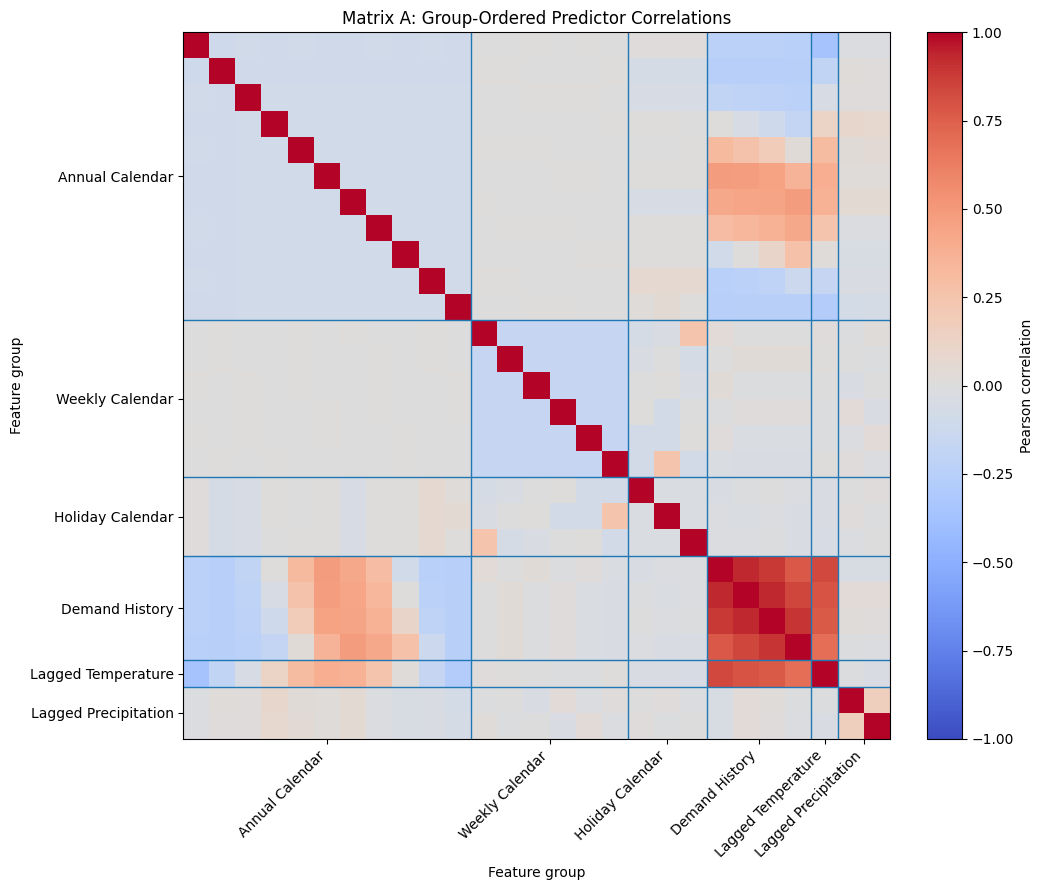

In [99]:
def plot_group_ordered_correlation_heatmap(
    correlation_matrix,
    feature_groups,
    title,
    figsize,
):
    """Plot predictor correlations ordered by feature group."""
    ordered_features = [
        feature
        for group_features in feature_groups.values()
        for feature in group_features
    ]

    assert set(ordered_features) == set(
        correlation_matrix.columns
    )

    ordered_correlation = correlation_matrix.loc[
        ordered_features,
        ordered_features,
    ]

    group_names = list(feature_groups.keys())
    group_lengths = [
        len(feature_groups[group])
        for group in group_names
    ]

    cumulative_lengths = np.cumsum(
        [0] + group_lengths
    )

    group_centers = [
        (
            cumulative_lengths[index]
            + cumulative_lengths[index + 1]
            - 1
        )
        / 2
        for index in range(len(group_names))
    ]

    group_labels = [
        group.replace("_", " ").title()
        for group in group_names
    ]

    fig, ax = plt.subplots(figsize=figsize)

    image = ax.imshow(
        ordered_correlation.to_numpy(),
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        interpolation="nearest",
        aspect="equal",
    )

    for boundary in cumulative_lengths[1:-1]:
        ax.axhline(
            boundary - 0.5,
            linewidth=1,
        )
        ax.axvline(
            boundary - 0.5,
            linewidth=1,
        )

    ax.set_xticks(group_centers)
    ax.set_yticks(group_centers)

    ax.set_xticklabels(
        group_labels,
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(group_labels)

    ax.set_title(title)
    ax.set_xlabel("Feature group")
    ax.set_ylabel("Feature group")

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label("Pearson correlation")

    fig.tight_layout()
    plt.show()


plot_group_ordered_correlation_heatmap(
    matrix_a_correlation,
    matrix_a_groups,
    "Matrix A: Group-Ordered Predictor Correlations",
    figsize=(11, 9),
)

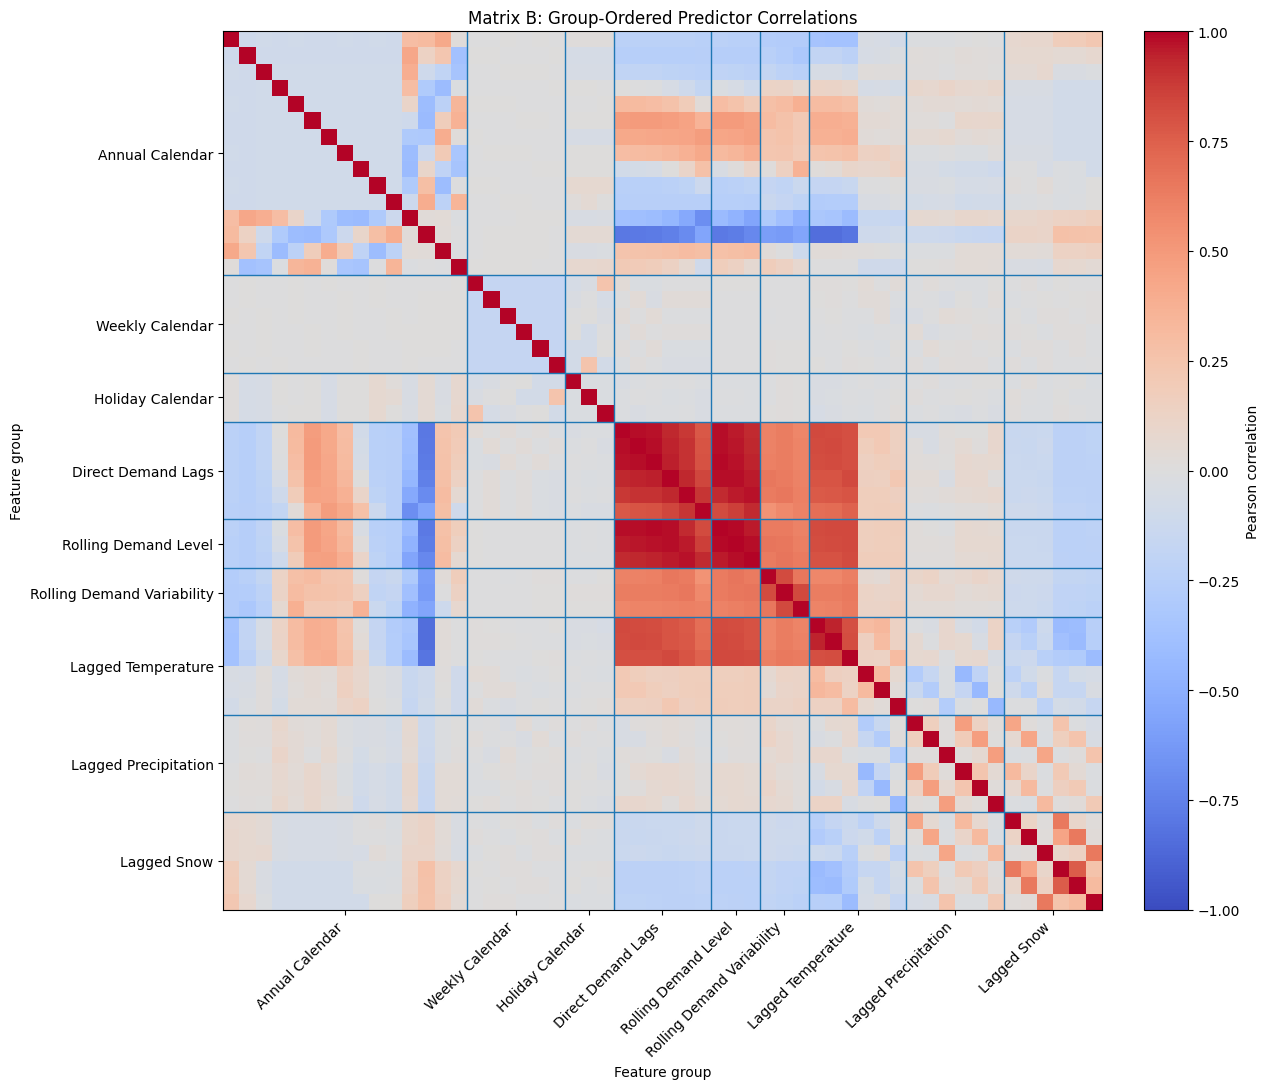

In [100]:
plot_group_ordered_correlation_heatmap(
    matrix_b_correlation,
    matrix_b_groups,
    "Matrix B: Group-Ordered Predictor Correlations",
    figsize=(13, 11),
)

In [101]:
def summarize_group_pair_correlations(
    pairwise_table,
    feature_groups,
):
    """Summarize absolute correlations within and between groups."""
    group_order = list(feature_groups.keys())
    rows = []

    for first_index, first_group in enumerate(group_order):
        for second_group in group_order[first_index:]:
            if first_group == second_group:
                subset = pairwise_table.loc[
                    (
                        pairwise_table["left_group"]
                        == first_group
                    )
                    & (
                        pairwise_table["right_group"]
                        == second_group
                    )
                ]
            else:
                subset = pairwise_table.loc[
                    (
                        (
                            pairwise_table["left_group"]
                            == first_group
                        )
                        & (
                            pairwise_table["right_group"]
                            == second_group
                        )
                    )
                    |
                    (
                        (
                            pairwise_table["left_group"]
                            == second_group
                        )
                        & (
                            pairwise_table["right_group"]
                            == first_group
                        )
                    )
                ]

            if subset.empty:
                rows.append(
                    {
                        "group_1": first_group,
                        "group_2": second_group,
                        "number_of_pairs": 0,
                        "mean_absolute_correlation": np.nan,
                        "median_absolute_correlation": np.nan,
                        "maximum_absolute_correlation": np.nan,
                        "strongest_feature_pair": None,
                        "strongest_pair_correlation": np.nan,
                    }
                )
                continue

            strongest_row = subset.loc[
                subset[
                    "absolute_correlation"
                ].idxmax()
            ]

            rows.append(
                {
                    "group_1": first_group,
                    "group_2": second_group,
                    "number_of_pairs": len(subset),
                    "mean_absolute_correlation": subset[
                        "absolute_correlation"
                    ].mean(),
                    "median_absolute_correlation": subset[
                        "absolute_correlation"
                    ].median(),
                    "maximum_absolute_correlation": subset[
                        "absolute_correlation"
                    ].max(),
                    "strongest_feature_pair": (
                        f"{strongest_row['left_feature']}"
                        " <-> "
                        f"{strongest_row['right_feature']}"
                    ),
                    "strongest_pair_correlation": strongest_row[
                        "correlation"
                    ],
                }
            )

    return pd.DataFrame(rows)


matrix_a_group_correlations = (
    summarize_group_pair_correlations(
        matrix_a_pairwise,
        matrix_a_groups,
    )
)

matrix_b_group_correlations = (
    summarize_group_pair_correlations(
        matrix_b_pairwise,
        matrix_b_groups,
    )
)

In [102]:
within_group_columns = [
    "group_1",
    "number_of_pairs",
    "mean_absolute_correlation",
    "median_absolute_correlation",
    "maximum_absolute_correlation",
    "strongest_feature_pair",
    "strongest_pair_correlation",
]

matrix_a_within_group = (
    matrix_a_group_correlations.loc[
        matrix_a_group_correlations["group_1"]
        == matrix_a_group_correlations["group_2"],
        within_group_columns,
    ]
    .reset_index(drop=True)
)

matrix_b_within_group = (
    matrix_b_group_correlations.loc[
        matrix_b_group_correlations["group_1"]
        == matrix_b_group_correlations["group_2"],
        within_group_columns,
    ]
    .reset_index(drop=True)
)

print("Matrix A within-group correlations:")
display(matrix_a_within_group.round(4))

print("Matrix B within-group correlations:")
display(matrix_b_within_group.round(4))

Matrix A within-group correlations:


,group_1,number_of_pairs,mean_absolute_correlation,median_absolute_correlation,maximum_absolute_correlation,strongest_feature_pair,strongest_pair_correlation
0,annual_calendar,55,0.0908,0.0894,0.1039,month_Feb <-> month_Mar,-0.1039
1,weekly_calendar,15,0.1666,0.1668,0.1668,dow_Wed <-> dow_Thu,-0.1668
2,holiday_calendar,3,0.0300,0.0300,0.0300,is_observed_federal_holiday <-> is_day_before_...,-0.0300
3,demand_history,6,0.8789,0.8910,0.9373,demand_lag_7 <-> demand_lag_14,0.9373
4,lagged_temperature,0,NaN,NaN,NaN,None,NaN
5,lagged_precipitation,1,0.1620,0.1620,0.1620,precipitation_in_lag_1 <-> precipitation_in_lag_2,0.1620


Matrix B within-group correlations:


,group_1,number_of_pairs,mean_absolute_correlation,median_absolute_correlation,maximum_absolute_correlation,strongest_feature_pair,strongest_pair_correlation
0,annual_calendar,105,0.1592,0.0940,0.4279,month_Mar <-> annual_sin_1,0.4279
1,weekly_calendar,15,0.1666,0.1668,0.1668,dow_Wed <-> dow_Thu,-0.1668
2,holiday_calendar,3,0.0300,0.0300,0.0300,is_observed_federal_holiday <-> is_day_before_...,-0.0300
3,direct_demand_lags,15,0.8993,0.9025,0.9775,demand_lag_1 <-> demand_lag_2,0.9775
4,rolling_demand_level,3,0.9778,0.9826,0.9903,demand_roll_mean_7 <-> demand_roll_mean_14,0.9903
5,rolling_demand_variability,3,0.7680,0.8257,0.8285,demand_roll_std_14 <-> demand_roll_std_28,0.8285
6,lagged_temperature,15,0.3269,0.3007,0.9418,tavg_f_lag_1 <-> tavg_f_lag_2,0.9418
7,lagged_precipitation,15,0.1545,0.0565,0.4726,precipitation_in_lag_1 <-> has_precipitation_l...,0.4726
8,lagged_snow,15,0.2827,0.1360,0.7589,snow_depth_in_lag_1 <-> snow_depth_in_lag_2,0.7589


In [103]:
cross_group_columns = [
    "group_1",
    "group_2",
    "number_of_pairs",
    "mean_absolute_correlation",
    "median_absolute_correlation",
    "maximum_absolute_correlation",
    "strongest_feature_pair",
    "strongest_pair_correlation",
]

matrix_a_cross_group = (
    matrix_a_group_correlations.loc[
        matrix_a_group_correlations["group_1"]
        != matrix_a_group_correlations["group_2"],
        cross_group_columns,
    ]
    .sort_values(
        [
            "maximum_absolute_correlation",
            "mean_absolute_correlation",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

matrix_b_cross_group = (
    matrix_b_group_correlations.loc[
        matrix_b_group_correlations["group_1"]
        != matrix_b_group_correlations["group_2"],
        cross_group_columns,
    ]
    .sort_values(
        [
            "maximum_absolute_correlation",
            "mean_absolute_correlation",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

print("Strongest Matrix A cross-group relationships:")
display(matrix_a_cross_group.head(15).round(4))

print("Strongest Matrix B cross-group relationships:")
display(matrix_b_cross_group.head(20).round(4))

Strongest Matrix A cross-group relationships:


,group_1,group_2,number_of_pairs,mean_absolute_correlation,median_absolute_correlation,maximum_absolute_correlation,strongest_feature_pair,strongest_pair_correlation
0,demand_history,lagged_temperature,4,0.7723,0.7823,0.8341,demand_lag_1 <-> tavg_f_lag_1,0.8341
1,annual_calendar,demand_history,44,0.2518,0.2439,0.4820,month_Jul <-> demand_lag_1,0.4820
2,annual_calendar,lagged_temperature,11,0.2258,0.2471,0.3869,month_Jul <-> tavg_f_lag_1,0.3869
3,weekly_calendar,holiday_calendar,18,0.0609,0.0481,0.2448,dow_Tue <-> is_day_after_observed_federal_holiday,0.2448
4,annual_calendar,lagged_precipitation,22,0.0364,0.0321,0.0880,month_May <-> precipitation_in_lag_1,0.0880
5,annual_calendar,holiday_calendar,33,0.0265,0.0116,0.0656,month_Nov <-> is_day_after_observed_federal_ho...,0.0656
6,holiday_calendar,lagged_temperature,3,0.0399,0.0368,0.0475,is_day_after_observed_federal_holiday <-> tavg...,-0.0475
7,demand_history,lagged_precipitation,8,0.0261,0.0247,0.0412,demand_lag_1 <-> precipitation_in_lag_1,-0.0412
8,weekly_calendar,lagged_precipitation,12,0.0189,0.0158,0.0361,dow_Sat <-> precipitation_in_lag_2,0.0361
9,weekly_calendar,demand_history,24,0.0199,0.0205,0.0355,dow_Tue <-> demand_lag_1,0.0355


Strongest Matrix B cross-group relationships:


,group_1,group_2,number_of_pairs,mean_absolute_correlation,median_absolute_correlation,maximum_absolute_correlation,strongest_feature_pair,strongest_pair_correlation
0,direct_demand_lags,rolling_demand_level,18,0.9466,0.9608,0.9876,demand_lag_3 <-> demand_roll_mean_7,0.9876
1,annual_calendar,lagged_temperature,90,0.1541,0.0937,0.8414,annual_cos_1 <-> tavg_f_lag_1,-0.8414
2,direct_demand_lags,lagged_temperature,36,0.4819,0.4512,0.8356,demand_lag_7 <-> tavg_f_lag_7,0.8356
3,rolling_demand_level,lagged_temperature,18,0.4945,0.4872,0.8328,demand_roll_mean_14 <-> tavg_f_lag_7,0.8328
4,annual_calendar,direct_demand_lags,90,0.2918,0.2506,0.7934,annual_cos_1 <-> demand_lag_1,-0.7934
5,annual_calendar,rolling_demand_level,45,0.2975,0.2578,0.7866,annual_cos_1 <-> demand_roll_mean_7,-0.7866
6,rolling_demand_level,rolling_demand_variability,9,0.6390,0.6380,0.6599,demand_roll_mean_28 <-> demand_roll_std_14,0.6599
7,direct_demand_lags,rolling_demand_variability,18,0.6108,0.6109,0.6558,demand_lag_7 <-> demand_roll_std_7,0.6558
8,rolling_demand_variability,lagged_temperature,18,0.3579,0.3603,0.6430,demand_roll_std_14 <-> tavg_f_lag_7,0.6430
9,annual_calendar,rolling_demand_variability,45,0.2366,0.2281,0.6098,annual_cos_1 <-> demand_roll_std_14,-0.6098


In [104]:
def build_group_metric_matrix(
    group_summary,
    feature_groups,
    metric,
):
    """Convert a long group-pair summary into a symmetric matrix."""
    group_order = list(feature_groups.keys())

    output = pd.DataFrame(
        np.nan,
        index=group_order,
        columns=group_order,
    )

    for row in group_summary.itertuples():
        value = getattr(row, metric)

        output.loc[row.group_1, row.group_2] = value
        output.loc[row.group_2, row.group_1] = value

    return output


matrix_a_group_mean_absolute = (
    build_group_metric_matrix(
        matrix_a_group_correlations,
        matrix_a_groups,
        "mean_absolute_correlation",
    )
)

matrix_b_group_mean_absolute = (
    build_group_metric_matrix(
        matrix_b_group_correlations,
        matrix_b_groups,
        "mean_absolute_correlation",
    )
)

print("Matrix A mean absolute correlations by group:")
display(matrix_a_group_mean_absolute.round(3))

print("Matrix B mean absolute correlations by group:")
display(matrix_b_group_mean_absolute.round(3))

Matrix A mean absolute correlations by group:


,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
annual_calendar,0.091,0.003,0.026,0.252,0.226,0.036
weekly_calendar,0.003,0.167,0.061,0.020,0.006,0.019
holiday_calendar,0.026,0.061,0.030,0.021,0.040,0.010
demand_history,0.252,0.020,0.021,0.879,0.772,0.026
lagged_temperature,0.226,0.006,0.040,0.772,NaN,0.022
lagged_precipitation,0.036,0.019,0.010,0.026,0.022,0.162


Matrix B mean absolute correlations by group:


,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
annual_calendar,0.159,0.002,0.033,0.292,0.298,0.237,0.154,0.047,0.071
weekly_calendar,0.002,0.167,0.061,0.021,0.000,0.004,0.013,0.015,0.010
holiday_calendar,0.033,0.061,0.030,0.019,0.017,0.008,0.022,0.013,0.015
direct_demand_lags,0.292,0.021,0.019,0.899,0.947,0.611,0.482,0.035,0.173
rolling_demand_level,0.298,0.000,0.017,0.947,0.978,0.639,0.494,0.036,0.179
rolling_demand_variability,0.237,0.004,0.008,0.611,0.639,0.768,0.358,0.057,0.156
lagged_temperature,0.154,0.013,0.022,0.482,0.494,0.358,0.327,0.110,0.183
lagged_precipitation,0.047,0.015,0.013,0.035,0.036,0.057,0.110,0.154,0.127
lagged_snow,0.071,0.010,0.015,0.173,0.179,0.156,0.183,0.127,0.283


In [105]:
matrix_a_group_maximum_absolute = (
    build_group_metric_matrix(
        matrix_a_group_correlations,
        matrix_a_groups,
        "maximum_absolute_correlation",
    )
)

matrix_b_group_maximum_absolute = (
    build_group_metric_matrix(
        matrix_b_group_correlations,
        matrix_b_groups,
        "maximum_absolute_correlation",
    )
)

print("Matrix A maximum absolute correlations by group:")
display(matrix_a_group_maximum_absolute.round(3))

print("Matrix B maximum absolute correlations by group:")
display(matrix_b_group_maximum_absolute.round(3))

Matrix A maximum absolute correlations by group:


,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
annual_calendar,0.104,0.006,0.066,0.482,0.387,0.088
weekly_calendar,0.006,0.167,0.245,0.036,0.014,0.036
holiday_calendar,0.066,0.245,0.030,0.033,0.047,0.018
demand_history,0.482,0.036,0.033,0.937,0.834,0.041
lagged_temperature,0.387,0.014,0.047,0.834,NaN,0.031
lagged_precipitation,0.088,0.036,0.018,0.041,0.031,0.162


Matrix B maximum absolute correlations by group:


,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
annual_calendar,0.428,0.006,0.079,0.793,0.787,0.610,0.841,0.158,0.268
weekly_calendar,0.006,0.167,0.245,0.036,0.001,0.012,0.032,0.037,0.018
holiday_calendar,0.079,0.245,0.030,0.033,0.019,0.015,0.047,0.039,0.023
direct_demand_lags,0.793,0.036,0.033,0.978,0.988,0.656,0.836,0.082,0.226
rolling_demand_level,0.787,0.001,0.019,0.988,0.990,0.660,0.833,0.068,0.228
rolling_demand_variability,0.610,0.012,0.015,0.656,0.660,0.829,0.643,0.120,0.227
lagged_temperature,0.841,0.032,0.047,0.836,0.833,0.643,0.942,0.437,0.415
lagged_precipitation,0.158,0.037,0.039,0.082,0.068,0.120,0.437,0.473,0.436
lagged_snow,0.268,0.018,0.023,0.226,0.228,0.227,0.415,0.436,0.759


In [106]:
def plot_group_metric_heatmap(
    metric_matrix,
    title,
):
    labels = [
        label.replace("_", " ").title()
        for label in metric_matrix.index
    ]

    fig, ax = plt.subplots(
        figsize=(
            max(8, 1.15 * len(labels)),
            max(7, 1.0 * len(labels)),
        )
    )

    image = ax.imshow(
        metric_matrix.to_numpy(dtype=float),
        vmin=0,
        vmax=1,
        cmap="viridis",
        interpolation="nearest",
    )

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(labels)

    for row_index in range(len(labels)):
        for column_index in range(len(labels)):
            value = metric_matrix.iloc[
                row_index,
                column_index,
            ]

            if np.isfinite(value):
                ax.text(
                    column_index,
                    row_index,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    ax.set_title(title)

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        "Mean absolute Pearson correlation"
    )

    fig.tight_layout()
    plt.show()

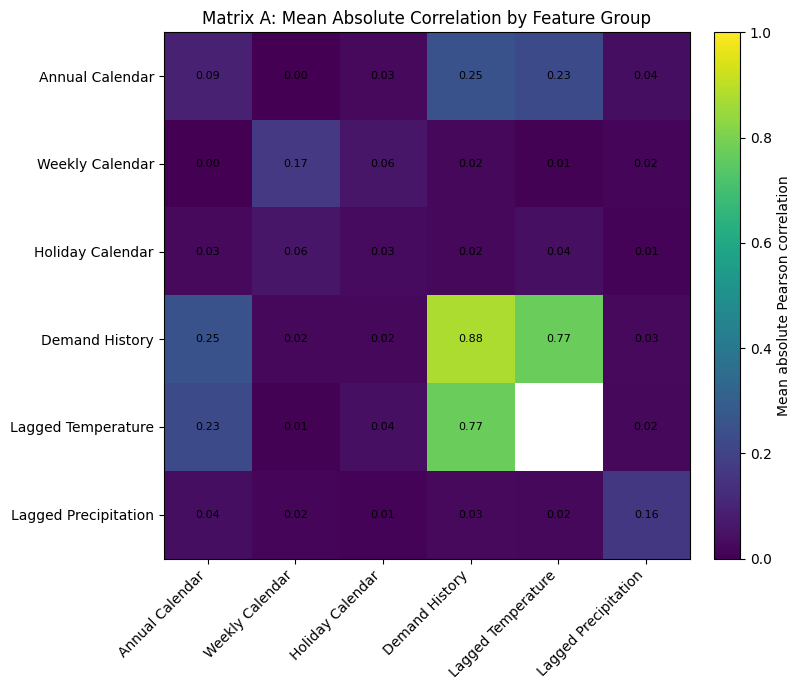

In [107]:
plot_group_metric_heatmap(
    matrix_a_group_mean_absolute,
    "Matrix A: Mean Absolute Correlation by Feature Group",
)

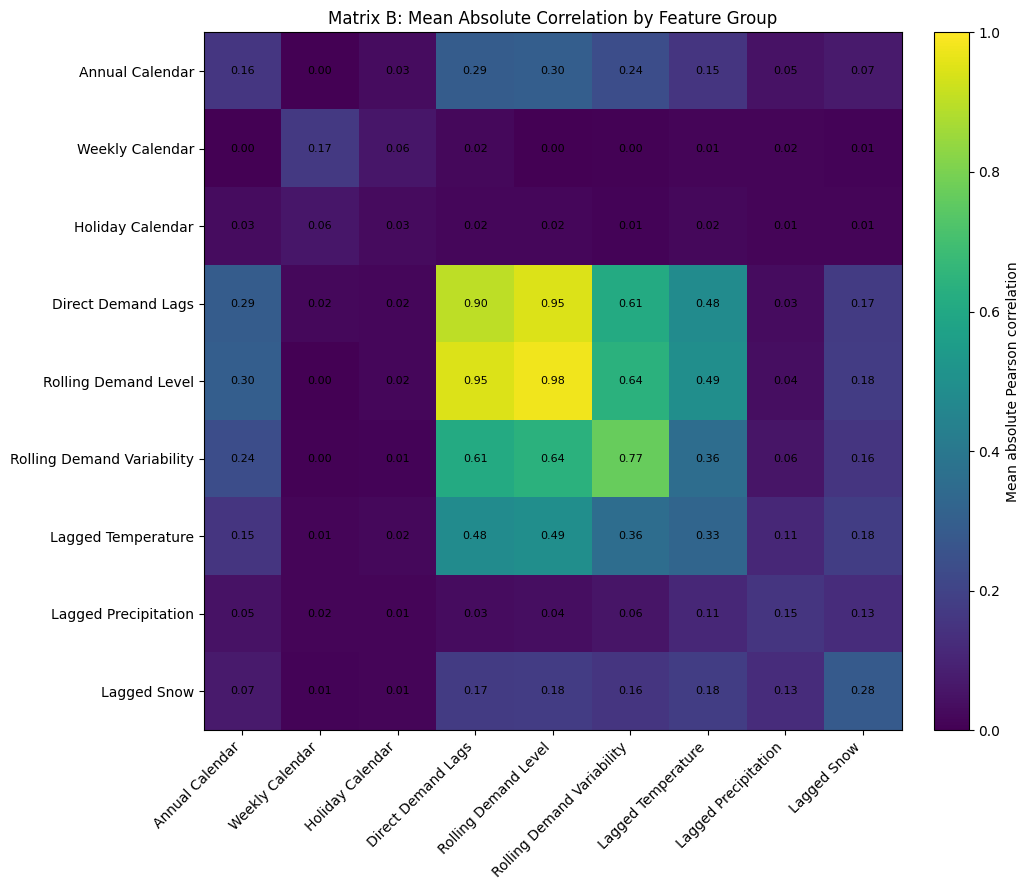

In [108]:
plot_group_metric_heatmap(
    matrix_b_group_mean_absolute,
    "Matrix B: Mean Absolute Correlation by Feature Group",
)

In [109]:
def summarize_overall_pairwise_correlation(
    pairwise_table,
    matrix_name,
):
    absolute_values = pairwise_table[
        "absolute_correlation"
    ]

    return {
        "matrix": matrix_name,
        "number_of_pairs": len(pairwise_table),
        "mean_absolute_correlation": absolute_values.mean(),
        "median_absolute_correlation": absolute_values.median(),
        "third_quartile_absolute_correlation": (
            absolute_values.quantile(0.75)
        ),
        "maximum_absolute_correlation": absolute_values.max(),
    }


overall_pairwise_summary = pd.DataFrame(
    [
        summarize_overall_pairwise_correlation(
            matrix_a_pairwise,
            "A",
        ),
        summarize_overall_pairwise_correlation(
            matrix_b_pairwise,
            "B",
        ),
    ]
)

display(overall_pairwise_summary.round(4))

,matrix,number_of_pairs,mean_absolute_correlation,median_absolute_correlation,third_quartile_absolute_correlation,maximum_absolute_correlation
0,A,351,0.097,0.0336,0.0940,0.9373
1,B,1431,0.159,0.0681,0.2112,0.9903


### Evidence

Matrix A contains meaningful but controlled predictor correlation. Six of its
351 feature pairs have absolute correlation of at least 0.80 and two exceed
0.90, while none exceed 0.95. The strongest relationships occur among demand
lags, with correlations of approximately 0.94 between the seven- and
fourteen-day lags and approximately 0.93 between the one- and seven-day lags.

Demand history and one-day lagged average temperature also overlap strongly.
Their mean absolute cross-group correlation is approximately 0.77 and the
correlation between one-day lagged demand and one-day lagged average
temperature is approximately 0.83. Recent demand therefore contains part of the
seasonal and weather information represented by lagged temperature.

The month and weekday indicators display the modest negative correlations
expected from mutually exclusive reference-category encodings. Holiday and
precipitation features remain comparatively weakly correlated with the main
demand-history block.

Matrix B contains a much denser region of predictor redundancy. Sixty of its
1,431 pairs have absolute correlation of at least 0.80, 28 exceed 0.90, 17
exceed 0.95 and one exceeds 0.99. Its strongest relationship is between the
seven- and fourteen-day rolling demand means, with correlation approximately
0.990.

Direct demand lags and rolling demand means form a particularly concentrated
block. Their mean absolute cross-group correlation is approximately 0.95 and
their median is approximately 0.96. Nearby direct lags, overlapping rolling
means and longer demand summaries largely represent a common evolving demand
level.

Rolling demand standard deviations are also correlated with one another and
with demand-level features. This is consistent with the earlier observation
that demand variability rises during the high-demand season, although the
incremental forecasting value of these variability summaries remains unknown.

Annual harmonics overlap with month indicators, lagged temperature and demand
history. The strongest relationships involve the first annual cosine term,
whose sign reflects the chosen harmonic phase rather than a negative causal
effect. Calendar, temperature and demand history therefore appear to share a
dominant seasonal component.

Lagged precipitation is comparatively distinct from the major
calendar-demand-temperature block. Lagged snow features display moderate
within-group correlation but only modest relationships with the principal
demand-history features.

Across all feature pairs, Matrix B has a higher mean, median and upper-quartile
absolute correlation than Matrix A. Its greater redundancy is therefore not
limited to one isolated pair or an artifact of its larger number of features.

### Provisional modeling implications

- Retain Matrix A as the primary interpretable operational specification.
- Retain Matrix B without pruning so that it provides a realistic test of
  overlapping feature engineering.
- Expect unregularized coefficient estimates to be less stable in Matrix B,
  especially within the direct-lag and rolling-mean block.
- Use PCR to test whether the information in Matrix B is concentrated in a
  smaller number of predictor directions.
- Use ridge to test whether weak or redundant directions should be shrunk
  rather than discarded.
- Do not remove lagged temperature solely because it is correlated with recent
  demand; evaluate its incremental predictive value chronologically.
- Retain precipitation as a potentially complementary feature group because it
  is weakly correlated with the primary demand-history block.
- Continue treating snow as a low-priority broad-matrix feature family.
- Interpret group means alongside group maxima because some groups, especially
  lagged temperature, contain heterogeneous types of predictors.

### Open questions

- Are both standardized matrices numerically full rank?
- How rapidly do their singular values decay?
- How much larger is the spectral condition number of Matrix B?
- Is Matrix B's smallest singular direction concentrated in direct lags,
  rolling means or the overlapping seasonal representations?
- How many principal directions explain most of each matrix's predictor
  variance?
- Does the geometry remain stable as the expanding training window grows?
- Do the additional correlated Matrix B features later improve
  rolling-validation performance?

## 12. Singular-value geometry, effective rank and conditioning

Pairwise correlations show that Matrix B contains a dense block of overlapping
demand-history features, but they cannot identify dependence distributed across
several predictors. Singular-value analysis provides a multivariate view of the
design-matrix geometry.

For each standardized predictor matrix $\mathbf{Z}$, this section examines:

- numerical rank;
- singular-value decay;
- spectral condition number;
- principal-component variance concentration;
- stable rank;
- entropy effective rank;
- participation-ratio effective rank.

The reported condition number is the spectral condition number of the centered
and standardized predictor matrix itself, excluding an intercept. It is not the
condition number of a normal-equations or Gram matrix. When $\mathbf{Z}$ has full
column rank, the corresponding correlation-matrix condition number is the
square of the condition number of $\mathbf{Z}$.

These calculations use the complete aligned development period for descriptive
analysis. During rolling evaluation, scaling and geometric diagnostics will be
recomputed separately within each expanding training window.

In [110]:
def compute_svd_geometry(
    standardized_matrix,
    matrix_name,
):
    """Compute singular-value and effective-rank diagnostics."""
    values = standardized_matrix.to_numpy(
        dtype=float
    )

    number_of_rows, number_of_columns = values.shape

    assert np.isfinite(values).all()

    _, singular_values, right_singular_vectors = (
        np.linalg.svd(
            values,
            full_matrices=False,
        )
    )

    # Standard numerical-rank tolerance used by matrix-rank routines.
    rank_tolerance = (
        max(number_of_rows, number_of_columns)
        * np.finfo(float).eps
        * singular_values[0]
    )

    numerical_rank = int(
        np.sum(singular_values > rank_tolerance)
    )

    rank_deficiency = (
        number_of_columns - numerical_rank
    )

    full_column_rank = (
        numerical_rank == number_of_columns
    )

    if full_column_rank:
        spectral_condition_number = (
            singular_values[0]
            / singular_values[-1]
        )

        implied_correlation_condition_number = (
            spectral_condition_number ** 2
        )
    else:
        spectral_condition_number = np.inf
        implied_correlation_condition_number = np.inf

    # Because each standardized column has population variance one,
    # the eigenvalues of the predictor correlation matrix are s_i^2 / n.
    correlation_eigenvalues = (
        singular_values ** 2
        / number_of_rows
    )

    total_predictor_variance = (
        correlation_eigenvalues.sum()
    )

    explained_variance_ratio = (
        correlation_eigenvalues
        / total_predictor_variance
    )

    cumulative_explained_variance = np.cumsum(
        explained_variance_ratio
    )

    # Stable rank emphasizes the spectral norm.
    stable_rank = (
        np.sum(singular_values ** 2)
        / singular_values[0] ** 2
    )

    positive_proportions = explained_variance_ratio[
        explained_variance_ratio > 0
    ]

    entropy = -np.sum(
        positive_proportions
        * np.log(positive_proportions)
    )

    entropy_effective_rank = np.exp(entropy)

    participation_ratio_effective_rank = (
        correlation_eigenvalues.sum() ** 2
        / np.sum(correlation_eigenvalues ** 2)
    )

    spectrum = pd.DataFrame(
        {
            "matrix": matrix_name,
            "component": np.arange(
                1,
                len(singular_values) + 1,
            ),
            "singular_value": singular_values,
            "relative_singular_value": (
                singular_values
                / singular_values[0]
            ),
            "correlation_eigenvalue": (
                correlation_eigenvalues
            ),
            "explained_variance_ratio": (
                explained_variance_ratio
            ),
            "cumulative_explained_variance": (
                cumulative_explained_variance
            ),
        }
    )

    def components_for_variance(threshold):
        return int(
            np.searchsorted(
                cumulative_explained_variance,
                threshold,
                side="left",
            )
            + 1
        )

    summary = {
        "matrix": matrix_name,
        "observations": number_of_rows,
        "features": number_of_columns,
        "numerical_rank": numerical_rank,
        "rank_deficiency": rank_deficiency,
        "rank_tolerance": rank_tolerance,
        "largest_singular_value": singular_values[0],
        "smallest_singular_value": singular_values[-1],
        "smallest_to_largest_ratio": (
            singular_values[-1]
            / singular_values[0]
        ),
        "spectral_condition_number_Z": (
            spectral_condition_number
        ),
        "implied_condition_number_correlation": (
            implied_correlation_condition_number
        ),
        "stable_rank": stable_rank,
        "entropy_effective_rank": (
            entropy_effective_rank
        ),
        "participation_ratio_effective_rank": (
            participation_ratio_effective_rank
        ),
        "components_for_80_percent": (
            components_for_variance(0.80)
        ),
        "components_for_90_percent": (
            components_for_variance(0.90)
        ),
        "components_for_95_percent": (
            components_for_variance(0.95)
        ),
        "components_for_99_percent": (
            components_for_variance(0.99)
        ),
    }

    # The sum of correlation eigenvalues should equal the number
    # of standardized predictors.
    assert np.isclose(
        total_predictor_variance,
        number_of_columns,
        rtol=1e-10,
        atol=1e-10,
    )

    assert stable_rank <= numerical_rank + 1e-10
    assert entropy_effective_rank <= numerical_rank + 1e-10
    assert (
        participation_ratio_effective_rank
        <= numerical_rank + 1e-10
    )

    return (
        summary,
        spectrum,
        right_singular_vectors,
    )

In [111]:
(
    matrix_a_geometry,
    matrix_a_spectrum,
    matrix_a_right_singular_vectors,
) = compute_svd_geometry(
    Z_a,
    "A",
)

(
    matrix_b_geometry,
    matrix_b_spectrum,
    matrix_b_right_singular_vectors,
) = compute_svd_geometry(
    Z_b,
    "B",
)

geometry_summary = pd.DataFrame(
    [
        matrix_a_geometry,
        matrix_b_geometry,
    ]
)

display(
    geometry_summary.round(6)
)

,matrix,observations,features,numerical_rank,rank_deficiency,rank_tolerance,largest_singular_value,smallest_singular_value,smallest_to_largest_ratio,spectral_condition_number_Z,implied_condition_number_correlation,stable_rank,entropy_effective_rank,participation_ratio_effective_rank,components_for_80_percent,components_for_90_percent,components_for_95_percent,components_for_99_percent
0,A,1889,27,27,0,0.0,99.991682,7.377657,0.073783,13.553311,183.692243,5.101149,18.906033,14.063682,15,18,20,23
1,B,1889,54,54,0,0.0,165.029851,1.765913,0.010701,93.452997,8733.462681,3.745422,22.329385,10.842091,19,26,30,39


In [112]:
geometry_display_columns = [
    "matrix",
    "observations",
    "features",
    "numerical_rank",
    "rank_deficiency",
    "largest_singular_value",
    "smallest_singular_value",
    "smallest_to_largest_ratio",
    "spectral_condition_number_Z",
    "implied_condition_number_correlation",
    "stable_rank",
    "entropy_effective_rank",
    "participation_ratio_effective_rank",
]

display(
    geometry_summary[
        geometry_display_columns
    ].round(6)
)

,matrix,observations,features,numerical_rank,rank_deficiency,largest_singular_value,smallest_singular_value,smallest_to_largest_ratio,spectral_condition_number_Z,implied_condition_number_correlation,stable_rank,entropy_effective_rank,participation_ratio_effective_rank
0,A,1889,27,27,0,99.991682,7.377657,0.073783,13.553311,183.692243,5.101149,18.906033,14.063682
1,B,1889,54,54,0,165.029851,1.765913,0.010701,93.452997,8733.462681,3.745422,22.329385,10.842091


In [113]:
def verify_correlation_eigenvalues(
    spectrum,
    correlation_matrix,
    matrix_name,
):
    correlation_eigenvalues = np.linalg.eigvalsh(
        correlation_matrix.to_numpy(
            dtype=float
        )
    )[::-1]

    assert np.allclose(
        spectrum[
            "correlation_eigenvalue"
        ].to_numpy(),
        correlation_eigenvalues,
        rtol=1e-9,
        atol=1e-10,
    )

    print(
        f"{matrix_name} SVD and correlation-eigenvalue "
        "checks passed."
    )


verify_correlation_eigenvalues(
    matrix_a_spectrum,
    matrix_a_correlation,
    "Matrix A",
)

verify_correlation_eigenvalues(
    matrix_b_spectrum,
    matrix_b_correlation,
    "Matrix B",
)

Matrix A SVD and correlation-eigenvalue checks passed.
Matrix B SVD and correlation-eigenvalue checks passed.


In [114]:
variance_concentration_columns = [
    "matrix",
    "features",
    "components_for_80_percent",
    "components_for_90_percent",
    "components_for_95_percent",
    "components_for_99_percent",
    "stable_rank",
    "entropy_effective_rank",
    "participation_ratio_effective_rank",
]

display(
    geometry_summary[
        variance_concentration_columns
    ].round(3)
)

,matrix,features,components_for_80_percent,components_for_90_percent,components_for_95_percent,components_for_99_percent,stable_rank,entropy_effective_rank,participation_ratio_effective_rank
0,A,27,15,18,20,23,5.101,18.906,14.064
1,B,54,19,26,30,39,3.745,22.329,10.842


In [115]:
def display_spectrum_ends(
    spectrum,
    matrix_name,
    number_to_show=8,
):
    print(
        f"{matrix_name}: leading singular directions"
    )

    display(
        spectrum.head(number_to_show).round(6)
    )

    print(
        f"{matrix_name}: trailing singular directions"
    )

    display(
        spectrum.tail(number_to_show).round(6)
    )


display_spectrum_ends(
    matrix_a_spectrum,
    "Matrix A",
)

display_spectrum_ends(
    matrix_b_spectrum,
    "Matrix B",
)

Matrix A: leading singular directions


,matrix,component,singular_value,relative_singular_value,correlation_eigenvalue,explained_variance_ratio,cumulative_explained_variance
0,A,1,99.991682,1.000000,5.292926,0.196034,0.196034
1,A,2,51.753484,0.517578,1.417905,0.052515,0.248549
2,A,3,51.321140,0.513254,1.394314,0.051641,0.300191
3,A,4,50.149252,0.501534,1.331364,0.049310,0.349500
4,A,5,47.943422,0.479474,1.216819,0.045067,0.394568
5,A,6,47.608898,0.476129,1.199898,0.044441,0.439008
6,A,7,47.003333,0.470072,1.169568,0.043317,0.482326
7,A,8,46.768746,0.467726,1.157922,0.042886,0.525212


Matrix A: trailing singular directions


,matrix,component,singular_value,relative_singular_value,correlation_eigenvalue,explained_variance_ratio,cumulative_explained_variance
19,A,20,37.615545,0.376187,0.749036,0.027742,0.971809
20,A,21,21.174482,0.211762,0.237352,0.008791,0.980600
21,A,22,17.687373,0.176888,0.165613,0.006134,0.986734
22,A,23,16.814014,0.168154,0.149662,0.005543,0.992277
23,A,24,12.166156,0.121672,0.078356,0.002902,0.995179
24,A,25,10.596696,0.105976,0.059444,0.002202,0.997381
25,A,26,8.897728,0.088985,0.041911,0.001552,0.998933
26,A,27,7.377657,0.073783,0.028814,0.001067,1.000000


Matrix B: leading singular directions


,matrix,component,singular_value,relative_singular_value,correlation_eigenvalue,explained_variance_ratio,cumulative_explained_variance
0,B,1,165.029851,1.000000,14.417603,0.266993,0.266993
1,B,2,79.829195,0.483726,3.373584,0.062474,0.329466
2,B,3,70.544162,0.427463,2.634451,0.048786,0.378253
3,B,4,69.726146,0.422506,2.573709,0.047661,0.425914
4,B,5,63.931762,0.387395,2.163722,0.040069,0.465983
5,B,6,61.533907,0.372865,2.004458,0.037120,0.503102
6,B,7,56.973933,0.345234,1.718385,0.031822,0.534924
7,B,8,52.717579,0.319443,1.471225,0.027245,0.562169


Matrix B: trailing singular directions


,matrix,component,singular_value,relative_singular_value,correlation_eigenvalue,explained_variance_ratio,cumulative_explained_variance
46,B,47,6.738706,0.040833,0.024039,0.000445,0.998893
47,B,48,5.757858,0.034890,0.017551,0.000325,0.999218
48,B,49,5.110774,0.030969,0.013827,0.000256,0.999474
49,B,50,4.600750,0.027878,0.011205,0.000208,0.999682
50,B,51,3.737308,0.022646,0.007394,0.000137,0.999819
51,B,52,3.162368,0.019162,0.005294,0.000098,0.999917
52,B,53,2.317229,0.014041,0.002843,0.000053,0.999969
53,B,54,1.765913,0.010701,0.001651,0.000031,1.000000


In [116]:
def build_relative_rank_profile(
    spectrum,
    matrix_name,
    relative_thresholds=(
        1e-1,
        1e-2,
        1e-3,
        1e-4,
        1e-6,
        1e-8,
        1e-10,
        1e-12,
    ),
):
    relative_values = spectrum[
        "relative_singular_value"
    ].to_numpy()

    rows = []

    for threshold in relative_thresholds:
        retained_directions = int(
            np.sum(
                relative_values >= threshold
            )
        )

        rows.append(
            {
                "matrix": matrix_name,
                "relative_singular_value_threshold": threshold,
                "directions_at_or_above_threshold": (
                    retained_directions
                ),
                "directions_below_threshold": (
                    len(relative_values)
                    - retained_directions
                ),
            }
        )

    return pd.DataFrame(rows)


relative_rank_profile = pd.concat(
    [
        build_relative_rank_profile(
            matrix_a_spectrum,
            "A",
        ),
        build_relative_rank_profile(
            matrix_b_spectrum,
            "B",
        ),
    ],
    ignore_index=True,
)

display(relative_rank_profile)

,matrix,relative_singular_value_threshold,directions_at_or_above_threshold,directions_below_threshold
0,A,1.000000e-01,25,2
1,A,1.000000e-02,27,0
2,A,1.000000e-03,27,0
3,A,1.000000e-04,27,0
4,A,1.000000e-06,27,0
5,A,1.000000e-08,27,0
6,A,1.000000e-10,27,0
7,A,1.000000e-12,27,0
8,B,1.000000e-01,37,17
9,B,1.000000e-02,54,0


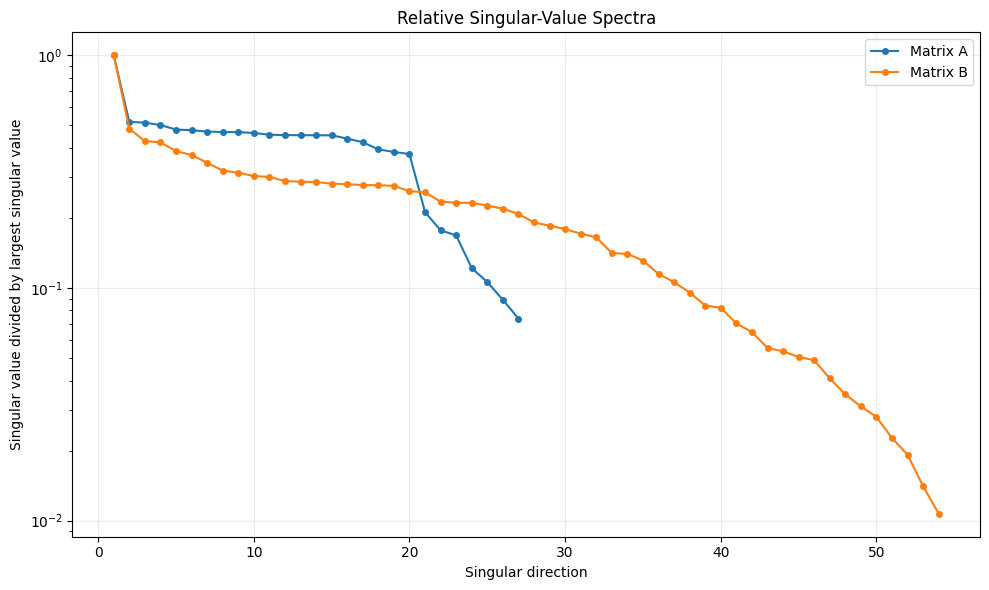

In [118]:
fig, ax = plt.subplots(figsize=(10, 6))

for matrix_name, spectrum in [
    ("Matrix A", matrix_a_spectrum),
    ("Matrix B", matrix_b_spectrum),
]:
    ax.plot(
        spectrum["component"],
        spectrum["relative_singular_value"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=matrix_name,
    )

ax.set_yscale("log")

ax.set_title(
    "Relative Singular-Value Spectra"
)

ax.set_xlabel("Singular direction")
ax.set_ylabel(
    "Singular value divided by largest singular value"
)

ax.grid(
    alpha=0.25,
)

ax.legend()

fig.tight_layout()
plt.show()

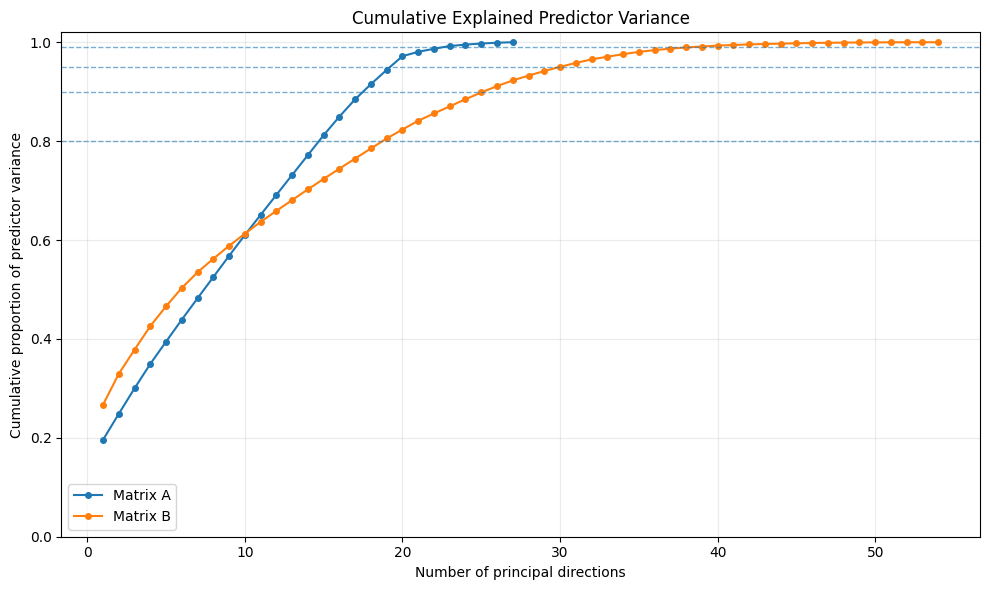

In [119]:
fig, ax = plt.subplots(figsize=(10, 6))

for matrix_name, spectrum in [
    ("Matrix A", matrix_a_spectrum),
    ("Matrix B", matrix_b_spectrum),
]:
    ax.plot(
        spectrum["component"],
        spectrum["cumulative_explained_variance"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=matrix_name,
    )

for threshold in [
    0.80,
    0.90,
    0.95,
    0.99,
]:
    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

ax.set_title(
    "Cumulative Explained Predictor Variance"
)

ax.set_xlabel("Number of principal directions")
ax.set_ylabel(
    "Cumulative proportion of predictor variance"
)

ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [120]:
leading_eigenvalue_summary = pd.concat(
    [
        matrix_a_spectrum.head(10)[
            [
                "component",
                "correlation_eigenvalue",
                "explained_variance_ratio",
                "cumulative_explained_variance",
            ]
        ].assign(matrix="A"),
        matrix_b_spectrum.head(10)[
            [
                "component",
                "correlation_eigenvalue",
                "explained_variance_ratio",
                "cumulative_explained_variance",
            ]
        ].assign(matrix="B"),
    ],
    ignore_index=True,
)

display(
    leading_eigenvalue_summary[
        [
            "matrix",
            "component",
            "correlation_eigenvalue",
            "explained_variance_ratio",
            "cumulative_explained_variance",
        ]
    ].round(5)
)

,matrix,component,correlation_eigenvalue,explained_variance_ratio,cumulative_explained_variance
0,A,1,5.29293,0.19603,0.19603
1,A,2,1.41791,0.05252,0.24855
2,A,3,1.39431,0.05164,0.30019
3,A,4,1.33136,0.04931,0.34950
4,A,5,1.21682,0.04507,0.39457
5,A,6,1.19990,0.04444,0.43901
6,A,7,1.16957,0.04332,0.48233
7,A,8,1.15792,0.04289,0.52521
8,A,9,1.15649,0.04283,0.56804
9,A,10,1.13717,0.04212,0.61016


In [121]:
trailing_direction_summary = pd.concat(
    [
        matrix_a_spectrum.tail(10).assign(
            matrix="A"
        ),
        matrix_b_spectrum.tail(10).assign(
            matrix="B"
        ),
    ],
    ignore_index=True,
)

display(
    trailing_direction_summary[
        [
            "matrix",
            "component",
            "singular_value",
            "relative_singular_value",
            "correlation_eigenvalue",
            "explained_variance_ratio",
        ]
    ].round(8)
)

,matrix,component,singular_value,relative_singular_value,correlation_eigenvalue,explained_variance_ratio
0,A,18,39.399544,0.394028,0.821770,0.030436
1,A,19,38.411185,0.384144,0.781058,0.028928
2,A,20,37.615545,0.376187,0.749036,0.027742
3,A,21,21.174482,0.211762,0.237352,0.008791
4,A,22,17.687373,0.176888,0.165613,0.006134
5,A,23,16.814014,0.168154,0.149662,0.005543
6,A,24,12.166156,0.121672,0.078356,0.002902
7,A,25,10.596696,0.105976,0.059444,0.002202
8,A,26,8.897728,0.088985,0.041911,0.001552
9,A,27,7.377657,0.073783,0.028814,0.001067


### Evidence

Both standardized design matrices are numerically full column rank. Matrix A
has rank 27 and Matrix B has rank 54 under the standard floating-point
tolerance. The broader feature construction therefore introduces no exact
multicolumn dependence.

The matrices nevertheless differ substantially in relative conditioning. Matrix A has a spectral condition number of approximately 13.6, while Matrix B has a condition number of approximately 93.5, making Matrix B about 6.9 times less well conditioned at the predictor-matrix level. Neither value is numerically concerning in this setting. As a worst-case rule of thumb, a condition number near $10^2$ corresponds to the possible loss of roughly two decimal digits of relative accuracy, which remains modest in double-precision computation. The comparison is therefore more relevant to coefficient sensitivity and predictor redundancy than to numerical solvability.

Because both matrices have full column rank, their correlation-matrix condition
numbers are the squares of the corresponding predictor-matrix condition
numbers. These values are approximately 184 for Matrix A and 8,733 for Matrix
B. The larger squared values reinforce the importance of avoiding explicit
normal-equations solves.

Matrix B also has a substantially weaker trailing spectrum. Its smallest
singular value is approximately 1.1 percent of its largest, compared with 7.4
percent for Matrix A. Seventeen Matrix B directions fall below 10 percent of
its largest singular value, while only two Matrix A directions do so. All
directions remain above one percent, so Matrix B contains a long weak but
nonzero tail rather than numerical rank deficiency.

Predictor variance is more concentrated in Matrix B. Its leading principal
direction explains approximately 26.7 percent of total standardized predictor
variance, compared with 19.6 percent for Matrix A. The first Matrix B
correlation eigenvalue is approximately 14.4, indicating a dominant direction
shared across many engineered predictors.

Matrix B requires more principal directions in absolute terms to reach each
variance threshold because it contains twice as many columns. Proportionally,
however, it is more compressible. Nineteen of its 54 directions explain 80
percent of predictor variance, while Matrix A requires 15 of 27. At the
95-percent level, Matrix B requires 30 of 54 directions and Matrix A requires
20 of 27.

The effective-rank measures provide complementary views of this concentration.
Matrix B has lower stable rank and participation-ratio effective rank because
its variance is dominated by a smaller collection of strong directions. Its
entropy effective rank is larger in absolute terms because it still contains
more moderately active directions, but it represents a much smaller fraction
of its nominal feature count.

Matrix A displays a relatively broad middle spectrum followed by a noticeable
drop in its final directions. Matrix B exhibits a larger leading component and
a gradual extended tail without one decisive elbow. This supports selecting
PCR dimension through chronological validation rather than from a fixed
explained-variance threshold alone.

### Provisional modeling implications

- Treat Matrix A as a correlated but reasonably well-conditioned
  unregularized baseline.
- Expect Matrix B coefficients to be more sensitive to the training sample,
  particularly along its weak trailing directions.
- Fit OLS with a stable least-squares solver rather than by explicitly forming
  and inverting the normal equations.
- Use PCR to test whether Matrix B's predictive information is concentrated in
  a smaller predictor subspace.
- Select the PCR dimension through rolling validation rather than solely from
  predictor explained variance.
- Use ridge to test whether gradual shrinkage of weak directions performs
  better than hard truncation.
- Do not infer poor forecast performance from conditioning alone. Coefficient
  instability and prediction quality must be evaluated separately.
- Repeat the scaling and geometric diagnostics within each expanding training
  window before making claims about stability over time.

### Open questions

- Which feature groups dominate the leading principal direction?
- Are Matrix B's weakest directions primarily contrasts among nearby demand
  lags and overlapping rolling means?
- Do calendar harmonics and month indicators appear together in trailing
  seasonal contrast directions?
- How stable are the dominant and weak subspaces across expanding training
  windows?
- Which PCR dimensions and ridge penalties minimize rolling-validation error?
- Do Matrix B's additional weak directions contain forecasting information
  despite explaining little predictor variance?

## 13. Leading and trailing predictor directions

The singular-value analysis showed that both matrices are full rank but that
Matrix B contains a dominant leading direction and a long tail of weak
directions. This section examines the predictor combinations associated with
those parts of the spectrum.

For a standardized design matrix $\mathbf{Z} = \mathbf{U}\boldsymbol{\Sigma} \mathbf{V}^\top$, each row of
$\mathbf{V}^\top$ is a unit-length direction in predictor space. Individual
coefficients describe how strongly each standardized feature contributes to
that direction.

The sign of a singular vector is arbitrary. Replacing a direction by its
negative does not change the subspace or any fitted principal-component
representation. Interpretation will therefore emphasize absolute coefficients
and squared coefficient energy rather than the sign of an isolated direction.

For feature group $g$ and direction $k$, grouped energy is defined as

$$
E_{kg} = \sum_{j \in g} v_{kj}^{2}.
$$

The group energies for each direction sum to one. Aggregating squared
coefficients across several directions provides a rotation-invariant
description of a selected subspace, making it more reliable than assigning
fixed meanings to individual principal components.

In [122]:
def verify_right_singular_vectors(
    right_singular_vectors,
    feature_names,
    matrix_name,
):
    """Verify the dimensions and row orthogonality of V transpose."""
    vectors = np.asarray(
        right_singular_vectors,
        dtype=float,
    )

    number_of_features = len(feature_names)

    assert vectors.shape == (
        number_of_features,
        number_of_features,
    )

    row_gram = vectors @ vectors.T

    maximum_orthogonality_error = np.max(
        np.abs(
            row_gram
            - np.eye(number_of_features)
        )
    )

    print(
        f"{matrix_name} right-singular-vector shape:",
        vectors.shape,
    )

    print(
        f"{matrix_name} maximum orthogonality error:",
        f"{maximum_orthogonality_error:.3e}",
    )

    assert np.allclose(
        row_gram,
        np.eye(number_of_features),
        atol=1e-12,
    )


verify_right_singular_vectors(
    matrix_a_right_singular_vectors,
    matrix_a_features,
    "Matrix A",
)

verify_right_singular_vectors(
    matrix_b_right_singular_vectors,
    matrix_b_features,
    "Matrix B",
)

Matrix A right-singular-vector shape: (27, 27)
Matrix A maximum orthogonality error: 1.998e-15
Matrix B right-singular-vector shape: (54, 54)
Matrix B maximum orthogonality error: 1.443e-15


In [123]:
def build_direction_loading_table(
    spectrum,
    right_singular_vectors,
    feature_names,
    group_lookup,
    matrix_name,
):
    """Create a long table of right-singular-vector coefficients."""
    vectors = np.asarray(
        right_singular_vectors,
        dtype=float,
    )

    assert vectors.shape == (
        len(feature_names),
        len(feature_names),
    )

    spectrum_lookup = (
        spectrum
        .set_index("component")
    )

    rows = []

    for component_index in range(
        vectors.shape[0]
    ):
        component = component_index + 1

        for feature_index, feature in enumerate(
            feature_names
        ):
            coefficient = vectors[
                component_index,
                feature_index,
            ]

            rows.append(
                {
                    "matrix": matrix_name,
                    "component": component,
                    "singular_value": spectrum_lookup.loc[
                        component,
                        "singular_value",
                    ],
                    "relative_singular_value": (
                        spectrum_lookup.loc[
                            component,
                            "relative_singular_value",
                        ]
                    ),
                    "explained_variance_ratio": (
                        spectrum_lookup.loc[
                            component,
                            "explained_variance_ratio",
                        ]
                    ),
                    "feature": feature,
                    "group": group_lookup[feature],
                    "coefficient": coefficient,
                    "absolute_coefficient": abs(
                        coefficient
                    ),
                    "squared_coefficient": (
                        coefficient ** 2
                    ),
                }
            )

    loading_table = pd.DataFrame(rows)

    energy_check = (
        loading_table
        .groupby("component")[
            "squared_coefficient"
        ]
        .sum()
    )

    assert np.allclose(
        energy_check,
        1.0,
        atol=1e-12,
    )

    return loading_table

In [124]:
matrix_a_direction_loadings = (
    build_direction_loading_table(
        matrix_a_spectrum,
        matrix_a_right_singular_vectors,
        matrix_a_features,
        matrix_a_group_lookup,
        "A",
    )
)

matrix_b_direction_loadings = (
    build_direction_loading_table(
        matrix_b_spectrum,
        matrix_b_right_singular_vectors,
        matrix_b_features,
        matrix_b_group_lookup,
        "B",
    )
)

print(
    "Matrix A direction-loading rows:",
    len(matrix_a_direction_loadings),
)

print(
    "Matrix B direction-loading rows:",
    len(matrix_b_direction_loadings),
)

Matrix A direction-loading rows: 729
Matrix B direction-loading rows: 2916


In [125]:
matrix_a_selected_components = {
    "Leading 1": 1,
    "Leading 2": 2,
    "Leading 3": 3,
    "Trailing 3": 25,
    "Trailing 2": 26,
    "Trailing 1": 27,
}

matrix_b_selected_components = {
    "Leading 1": 1,
    "Leading 2": 2,
    "Leading 3": 3,
    "Trailing 3": 52,
    "Trailing 2": 53,
    "Trailing 1": 54,
}

In [126]:
def summarize_selected_direction_features(
    loading_table,
    selected_components,
    number_to_show=10,
):
    """Return the largest absolute coefficients in selected directions."""
    component_labels = {
        component: label
        for label, component in selected_components.items()
    }

    selected = loading_table.loc[
        loading_table["component"].isin(
            component_labels
        )
    ].copy()

    selected["direction_label"] = (
        selected["component"]
        .map(component_labels)
    )

    selected = (
        selected
        .sort_values(
            [
                "component",
                "absolute_coefficient",
            ],
            ascending=[True, False],
        )
        .groupby(
            "component",
            group_keys=False,
        )
        .head(number_to_show)
    )

    label_order = list(
        selected_components.keys()
    )

    selected["direction_label"] = pd.Categorical(
        selected["direction_label"],
        categories=label_order,
        ordered=True,
    )

    return (
        selected
        .sort_values(
            [
                "direction_label",
                "absolute_coefficient",
            ],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

In [127]:
matrix_a_top_direction_features = (
    summarize_selected_direction_features(
        matrix_a_direction_loadings,
        matrix_a_selected_components,
        number_to_show=10,
    )
)

matrix_b_top_direction_features = (
    summarize_selected_direction_features(
        matrix_b_direction_loadings,
        matrix_b_selected_components,
        number_to_show=12,
    )
)

direction_feature_columns = [
    "direction_label",
    "component",
    "singular_value",
    "relative_singular_value",
    "feature",
    "group",
    "coefficient",
    "absolute_coefficient",
    "squared_coefficient",
]

print("Matrix A selected-direction features:")
display(
    matrix_a_top_direction_features[
        direction_feature_columns
    ].round(5)
)

print("Matrix B selected-direction features:")
display(
    matrix_b_top_direction_features[
        direction_feature_columns
    ].round(5)
)

Matrix A selected-direction features:


,direction_label,component,singular_value,relative_singular_value,feature,group,coefficient,absolute_coefficient,squared_coefficient
0,Leading 1,1,99.99168,1.00000,demand_lag_7,demand_history,0.41979,0.41979,0.17623
1,Leading 1,1,99.99168,1.00000,demand_lag_14,demand_history,0.41801,0.41801,0.17473
2,Leading 1,1,99.99168,1.00000,demand_lag_1,demand_history,0.41340,0.41340,0.17090
3,Leading 1,1,99.99168,1.00000,demand_lag_28,demand_history,0.39168,0.39168,0.15341
4,Leading 1,1,99.99168,1.00000,tavg_f_lag_1,lagged_temperature,0.37648,0.37648,0.14174
5,Leading 1,1,99.99168,1.00000,month_Jul,annual_calendar,0.20477,0.20477,0.04193
6,Leading 1,1,99.99168,1.00000,month_Aug,annual_calendar,0.20473,0.20473,0.04191
7,Leading 1,1,99.99168,1.00000,month_Sep,annual_calendar,0.15742,0.15742,0.02478
8,Leading 1,1,99.99168,1.00000,month_Feb,annual_calendar,-0.12549,0.12549,0.01575
9,Leading 1,1,99.99168,1.00000,month_Dec,annual_calendar,-0.12382,0.12382,0.01533


Matrix B selected-direction features:


,direction_label,component,singular_value,relative_singular_value,feature,group,coefficient,absolute_coefficient,squared_coefficient
0,Leading 1,1,165.02985,1.0000,demand_roll_mean_14,rolling_demand_level,-0.25653,0.25653,0.06581
1,Leading 1,1,165.02985,1.0000,demand_roll_mean_7,rolling_demand_level,-0.25506,0.25506,0.06505
2,Leading 1,1,165.02985,1.0000,demand_roll_mean_28,rolling_demand_level,-0.25434,0.25434,0.06469
3,Leading 1,1,165.02985,1.0000,demand_lag_7,direct_demand_lags,-0.25192,0.25192,0.06347
4,Leading 1,1,165.02985,1.0000,demand_lag_3,direct_demand_lags,-0.25101,0.25101,0.06301
...,...,...,...,...,...,...,...,...,...
67,Trailing 1,54,1.76591,0.0107,demand_lag_1,direct_demand_lags,0.06208,0.06208,0.00385
68,Trailing 1,54,1.76591,0.0107,demand_lag_28,direct_demand_lags,0.02851,0.02851,0.00081
69,Trailing 1,54,1.76591,0.0107,annual_cos_1,annual_calendar,-0.01827,0.01827,0.00033
70,Trailing 1,54,1.76591,0.0107,annual_sin_1,annual_calendar,-0.00948,0.00948,0.00009


In [128]:
def summarize_direction_group_energy(
    loading_table,
    feature_groups,
):
    """Sum squared coefficients within each feature group."""
    group_order = list(feature_groups.keys())

    group_energy = (
        loading_table
        .groupby(
            [
                "matrix",
                "component",
                "singular_value",
                "relative_singular_value",
                "explained_variance_ratio",
                "group",
            ],
            as_index=False,
        )["squared_coefficient"]
        .sum()
        .rename(
            columns={
                "squared_coefficient": "group_energy"
            }
        )
    )

    group_energy["group"] = pd.Categorical(
        group_energy["group"],
        categories=group_order,
        ordered=True,
    )

    energy_sums = (
        group_energy
        .groupby(
            ["matrix", "component"],
            observed=False,
        )["group_energy"]
        .sum()
    )

    assert np.allclose(
        energy_sums,
        1.0,
        atol=1e-12,
    )

    return (
        group_energy
        .sort_values(
            ["component", "group"]
        )
        .reset_index(drop=True)
    )

In [129]:
matrix_a_direction_group_energy = (
    summarize_direction_group_energy(
        matrix_a_direction_loadings,
        matrix_a_groups,
    )
)

matrix_b_direction_group_energy = (
    summarize_direction_group_energy(
        matrix_b_direction_loadings,
        matrix_b_groups,
    )
)

In [130]:
def build_selected_group_energy_table(
    group_energy,
    selected_components,
):
    component_labels = {
        component: label
        for label, component in selected_components.items()
    }

    selected = group_energy.loc[
        group_energy["component"].isin(
            component_labels
        )
    ].copy()

    selected["direction_label"] = (
        selected["component"]
        .map(component_labels)
    )

    pivot = selected.pivot(
        index="direction_label",
        columns="group",
        values="group_energy",
    )

    pivot = pivot.reindex(
        list(selected_components.keys())
    )

    assert np.allclose(
        pivot.sum(axis=1),
        1.0,
        atol=1e-12,
    )

    return pivot

In [131]:
matrix_a_selected_group_energy = (
    build_selected_group_energy_table(
        matrix_a_direction_group_energy,
        matrix_a_selected_components,
    )
)

matrix_b_selected_group_energy = (
    build_selected_group_energy_table(
        matrix_b_direction_group_energy,
        matrix_b_selected_components,
    )
)

print("Matrix A selected-direction group energy:")
display(
    matrix_a_selected_group_energy.round(3)
)

print("Matrix B selected-direction group energy:")
display(
    matrix_b_selected_group_energy.round(3)
)

Matrix A selected-direction group energy:


group,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
direction_label,,,,,,
Leading 1,0.182,0.000,0.001,0.675,0.142,0.000
Leading 2,0.009,0.597,0.387,0.001,0.000,0.006
Leading 3,0.537,0.033,0.058,0.051,0.020,0.300
Trailing 3,0.023,0.015,0.000,0.951,0.009,0.003
Trailing 2,0.010,0.017,0.000,0.958,0.011,0.004
Trailing 1,0.897,0.001,0.000,0.053,0.047,0.003


Matrix B selected-direction group energy:


group,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
direction_label,,,,,,,,,
Leading 1,0.131,0.000,0.000,0.365,0.196,0.109,0.173,0.000,0.027
Leading 2,0.149,0.000,0.001,0.015,0.009,0.005,0.123,0.314,0.384
Leading 3,0.600,0.001,0.001,0.056,0.020,0.045,0.068,0.098,0.111
Trailing 3,0.996,0.000,0.000,0.002,0.001,0.001,0.001,0.000,0.000
Trailing 2,0.005,0.000,0.000,0.154,0.839,0.002,0.000,0.000,0.000
Trailing 1,0.001,0.000,0.000,0.057,0.942,0.000,0.000,0.000,0.000


In [132]:
def plot_selected_group_energy(
    group_energy_table,
    title,
):
    fig, ax = plt.subplots(
        figsize=(
            max(
                9,
                1.25
                * group_energy_table.shape[1],
            ),
            6,
        )
    )

    image = ax.imshow(
        group_energy_table.to_numpy(
            dtype=float
        ),
        vmin=0,
        vmax=1,
        cmap="viridis",
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(
        range(group_energy_table.shape[1])
    )

    ax.set_yticks(
        range(group_energy_table.shape[0])
    )

    ax.set_xticklabels(
        [
            group.replace("_", " ").title()
            for group in group_energy_table.columns
        ],
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(
        group_energy_table.index
    )

    for row_index in range(
        group_energy_table.shape[0]
    ):
        for column_index in range(
            group_energy_table.shape[1]
        ):
            value = group_energy_table.iloc[
                row_index,
                column_index,
            ]

            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    ax.set_title(title)
    ax.set_xlabel("Feature group")
    ax.set_ylabel("Singular direction")

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    colorbar.set_label(
        "Share of squared coefficient energy"
    )

    fig.tight_layout()
    plt.show()

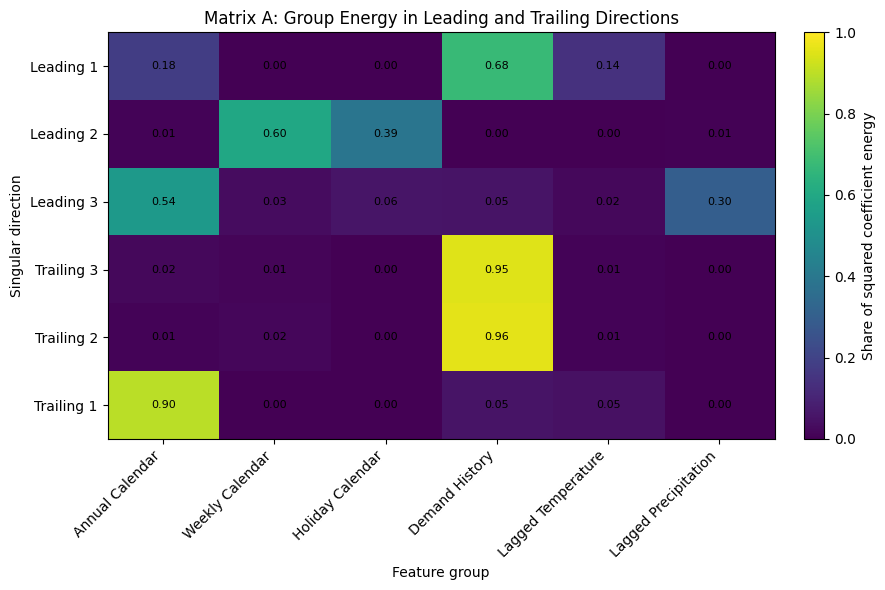

In [133]:
plot_selected_group_energy(
    matrix_a_selected_group_energy,
    "Matrix A: Group Energy in Leading and Trailing Directions",
)

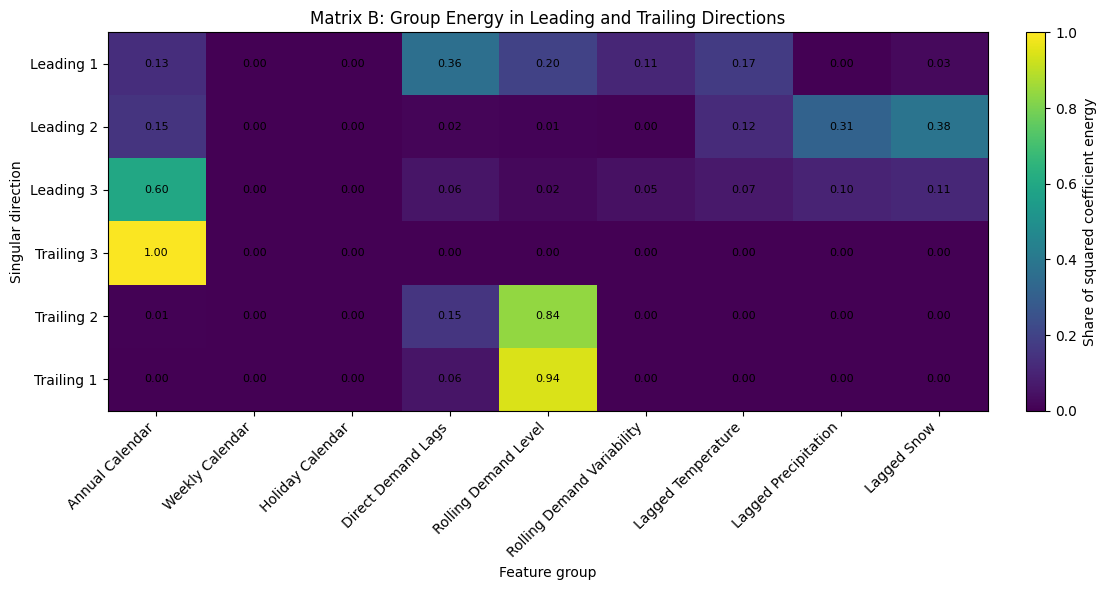

In [134]:
plot_selected_group_energy(
    matrix_b_selected_group_energy,
    "Matrix B: Group Energy in Leading and Trailing Directions",
)

In [135]:
def identify_dominant_direction_groups(
    group_energy,
):
    dominant_indices = (
        group_energy
        .groupby("component")[
            "group_energy"
        ]
        .idxmax()
    )

    return (
        group_energy.loc[
            dominant_indices,
            [
                "matrix",
                "component",
                "singular_value",
                "relative_singular_value",
                "explained_variance_ratio",
                "group",
                "group_energy",
            ],
        ]
        .rename(
            columns={
                "group": "dominant_group",
                "group_energy": (
                    "dominant_group_energy"
                ),
            }
        )
        .sort_values("component")
        .reset_index(drop=True)
    )

In [136]:
matrix_a_dominant_direction_groups = (
    identify_dominant_direction_groups(
        matrix_a_direction_group_energy
    )
)

matrix_b_dominant_direction_groups = (
    identify_dominant_direction_groups(
        matrix_b_direction_group_energy
    )
)

print("Matrix A dominant groups:")
display(
    pd.concat(
        [
            matrix_a_dominant_direction_groups.head(6),
            matrix_a_dominant_direction_groups.tail(6),
        ],
        ignore_index=True,
    ).round(4)
)

print("Matrix B dominant groups:")
display(
    pd.concat(
        [
            matrix_b_dominant_direction_groups.head(8),
            matrix_b_dominant_direction_groups.tail(8),
        ],
        ignore_index=True,
    ).round(4)
)

Matrix A dominant groups:


,matrix,component,singular_value,relative_singular_value,explained_variance_ratio,dominant_group,dominant_group_energy
0,A,1,99.9917,1.0000,0.1960,demand_history,0.6753
1,A,2,51.7535,0.5176,0.0525,weekly_calendar,0.5973
2,A,3,51.3211,0.5133,0.0516,annual_calendar,0.5368
3,A,4,50.1493,0.5015,0.0493,weekly_calendar,0.5371
4,A,5,47.9434,0.4795,0.0451,annual_calendar,0.4465
5,A,6,47.6089,0.4761,0.0444,weekly_calendar,0.5750
6,A,22,17.6874,0.1769,0.0061,weekly_calendar,0.4240
7,A,23,16.8140,0.1682,0.0055,weekly_calendar,0.5237
8,A,24,12.1662,0.1217,0.0029,demand_history,0.8545
9,A,25,10.5967,0.1060,0.0022,demand_history,0.9508


Matrix B dominant groups:


,matrix,component,singular_value,relative_singular_value,explained_variance_ratio,dominant_group,dominant_group_energy
0,B,1,165.0299,1.0000,0.2670,direct_demand_lags,0.3646
1,B,2,79.8292,0.4837,0.0625,lagged_snow,0.3836
2,B,3,70.5442,0.4275,0.0488,annual_calendar,0.5997
3,B,4,69.7261,0.4225,0.0477,lagged_precipitation,0.3053
4,B,5,63.9318,0.3874,0.0401,annual_calendar,0.7948
5,B,6,61.5339,0.3729,0.0371,annual_calendar,0.5458
6,B,7,56.9739,0.3452,0.0318,lagged_precipitation,0.4198
7,B,8,52.7176,0.3194,0.0272,lagged_snow,0.2851
8,B,47,6.7387,0.0408,0.0004,annual_calendar,0.8884
9,B,48,5.7579,0.0349,0.0003,direct_demand_lags,0.9091


In [137]:
def build_subspace_definitions(
    geometry,
):
    """Define leading and trailing subspaces for one matrix."""
    number_of_features = int(
        geometry["features"]
    )

    components_80 = int(
        geometry["components_for_80_percent"]
    )

    components_90 = int(
        geometry["components_for_90_percent"]
    )

    components_95 = int(
        geometry["components_for_95_percent"]
    )

    return {
        "Leading 1": [1],
        "Leading 3": list(range(1, 4)),
        "Leading 5": list(range(1, 6)),
        f"Leading {components_80} (80%)": list(
            range(1, components_80 + 1)
        ),
        f"Leading {components_90} (90%)": list(
            range(1, components_90 + 1)
        ),
        f"Leading {components_95} (95%)": list(
            range(1, components_95 + 1)
        ),
        "Trailing 5": list(
            range(
                number_of_features - 4,
                number_of_features + 1,
            )
        ),
        "Trailing 3": list(
            range(
                number_of_features - 2,
                number_of_features + 1,
            )
        ),
        "Trailing 1": [number_of_features],
    }

In [138]:
matrix_a_subspaces = build_subspace_definitions(
    matrix_a_geometry
)

matrix_b_subspaces = build_subspace_definitions(
    matrix_b_geometry
)

In [139]:
def summarize_subspace_group_energy(
    loading_table,
    feature_groups,
    subspace_definitions,
):
    """Calculate rotation-invariant group shares for selected subspaces."""
    group_order = list(feature_groups.keys())
    rows = []

    for subspace_label, components in (
        subspace_definitions.items()
    ):
        selected = loading_table.loc[
            loading_table["component"].isin(
                components
            )
        ]

        assert (
            selected["component"].nunique()
            == len(components)
        )

        grouped_energy = (
            selected
            .groupby("group")[
                "squared_coefficient"
            ]
            .sum()
            / len(components)
        )

        for group in group_order:
            rows.append(
                {
                    "subspace": subspace_label,
                    "number_of_directions": (
                        len(components)
                    ),
                    "group": group,
                    "average_group_energy": (
                        grouped_energy.get(
                            group,
                            0.0,
                        )
                    ),
                }
            )

    output = pd.DataFrame(rows)

    output["group"] = pd.Categorical(
        output["group"],
        categories=group_order,
        ordered=True,
    )

    energy_check = (
        output
        .groupby("subspace")[
            "average_group_energy"
        ]
        .sum()
    )

    assert np.allclose(
        energy_check,
        1.0,
        atol=1e-12,
    )

    return output

In [140]:
matrix_a_subspace_group_energy = (
    summarize_subspace_group_energy(
        matrix_a_direction_loadings,
        matrix_a_groups,
        matrix_a_subspaces,
    )
)

matrix_b_subspace_group_energy = (
    summarize_subspace_group_energy(
        matrix_b_direction_loadings,
        matrix_b_groups,
        matrix_b_subspaces,
    )
)

In [141]:
def pivot_subspace_group_energy(
    subspace_energy,
    subspace_definitions,
):
    pivot = subspace_energy.pivot(
        index="subspace",
        columns="group",
        values="average_group_energy",
    )

    return pivot.reindex(
        list(subspace_definitions.keys())
    )

In [142]:
matrix_a_subspace_group_table = (
    pivot_subspace_group_energy(
        matrix_a_subspace_group_energy,
        matrix_a_subspaces,
    )
)

matrix_b_subspace_group_table = (
    pivot_subspace_group_energy(
        matrix_b_subspace_group_energy,
        matrix_b_subspaces,
    )
)

print("Matrix A subspace group energy:")
display(
    matrix_a_subspace_group_table.round(3)
)

print("Matrix B subspace group energy:")
display(
    matrix_b_subspace_group_table.round(3)
)

Matrix A subspace group energy:


group,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
subspace,,,,,,
Leading 1,0.182,0.000,0.001,0.675,0.142,0.000
Leading 3,0.243,0.210,0.149,0.242,0.054,0.102
Leading 5,0.262,0.303,0.178,0.155,0.033,0.069
Leading 15 (80%),0.536,0.281,0.070,0.055,0.014,0.043
Leading 18 (90%),0.485,0.250,0.097,0.047,0.013,0.109
Leading 20 (95%),0.448,0.250,0.149,0.042,0.011,0.099
Trailing 5,0.252,0.113,0.002,0.591,0.040,0.002
Trailing 3,0.310,0.011,0.000,0.654,0.022,0.003
Trailing 1,0.897,0.001,0.000,0.053,0.047,0.003


Matrix B subspace group energy:


group,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
subspace,,,,,,,,,
Leading 1,0.131,0.000,0.000,0.365,0.196,0.109,0.173,0.000,0.027
Leading 3,0.293,0.000,0.000,0.145,0.075,0.053,0.121,0.138,0.174
Leading 5,0.385,0.001,0.008,0.092,0.045,0.043,0.107,0.151,0.169
Leading 19 (80%),0.405,0.222,0.049,0.030,0.013,0.028,0.057,0.088,0.108
Leading 26 (90%),0.338,0.191,0.114,0.024,0.010,0.040,0.081,0.099,0.103
Leading 30 (95%),0.296,0.167,0.099,0.021,0.009,0.036,0.100,0.166,0.105
Trailing 5,0.398,0.001,0.000,0.112,0.487,0.001,0.000,0.000,0.000
Trailing 3,0.334,0.000,0.000,0.071,0.594,0.001,0.000,0.000,0.000
Trailing 1,0.001,0.000,0.000,0.057,0.942,0.000,0.000,0.000,0.000


In [143]:
def summarize_feature_subspace_energy(
    loading_table,
    subspace_definitions,
    selected_subspaces=(
        "Leading 3",
        "Trailing 3",
    ),
    number_to_show=15,
):
    rows = []

    for subspace_label in selected_subspaces:
        components = subspace_definitions[
            subspace_label
        ]

        selected = loading_table.loc[
            loading_table["component"].isin(
                components
            )
        ]

        feature_energy = (
            selected
            .groupby(
                ["feature", "group"],
                as_index=False,
            )["squared_coefficient"]
            .sum()
            .rename(
                columns={
                    "squared_coefficient": (
                        "total_subspace_energy"
                    )
                }
            )
        )

        feature_energy[
            "average_subspace_energy"
        ] = (
            feature_energy[
                "total_subspace_energy"
            ]
            / len(components)
        )

        feature_energy["subspace"] = (
            subspace_label
        )

        feature_energy = (
            feature_energy
            .sort_values(
                "total_subspace_energy",
                ascending=False,
            )
            .head(number_to_show)
        )

        rows.append(feature_energy)

    return pd.concat(
        rows,
        ignore_index=True,
    )

In [144]:
matrix_a_feature_subspace_energy = (
    summarize_feature_subspace_energy(
        matrix_a_direction_loadings,
        matrix_a_subspaces,
    )
)

matrix_b_feature_subspace_energy = (
    summarize_feature_subspace_energy(
        matrix_b_direction_loadings,
        matrix_b_subspaces,
    )
)

print("Matrix A leading and trailing subspace features:")
display(
    matrix_a_feature_subspace_energy.round(5)
)

print("Matrix B leading and trailing subspace features:")
display(
    matrix_b_feature_subspace_energy.round(5)
)

Matrix A leading and trailing subspace features:


,feature,group,total_subspace_energy,average_subspace_energy,subspace
0,dow_Sun,weekly_calendar,0.32374,0.10791,Leading 3
1,dow_Tue,weekly_calendar,0.24887,0.08296,Leading 3
2,is_day_before_observed_federal_holiday,holiday_calendar,0.22076,0.07359,Leading 3
3,is_day_after_observed_federal_holiday,holiday_calendar,0.21834,0.07278,Leading 3
4,demand_lag_28,demand_history,0.19671,0.06557,Leading 3
5,demand_lag_14,demand_history,0.17856,0.05952,Leading 3
6,demand_lag_7,demand_history,0.17714,0.05905,Leading 3
7,demand_lag_1,demand_history,0.17479,0.05826,Leading 3
8,tavg_f_lag_1,lagged_temperature,0.16183,0.05394,Leading 3
9,precipitation_in_lag_1,lagged_precipitation,0.15345,0.05115,Leading 3


Matrix B leading and trailing subspace features:


,feature,group,total_subspace_energy,average_subspace_energy,subspace
0,annual_sin_2,annual_calendar,0.22649,0.07550,Leading 3
1,snow_depth_in_lag_1,lagged_snow,0.14869,0.04956,Leading 3
2,snow_depth_in_lag_2,lagged_snow,0.13253,0.04418,Leading 3
3,month_May,annual_calendar,0.12444,0.04148,Leading 3
4,has_precipitation_lag_2,lagged_precipitation,0.10891,0.03630,Leading 3
5,has_precipitation_lag_1,lagged_precipitation,0.10835,0.03612,Leading 3
6,annual_cos_1,annual_calendar,0.10528,0.03509,Leading 3
7,precipitation_in_lag_2,lagged_precipitation,0.09396,0.03132,Leading 3
8,snowfall_in_lag_2,lagged_snow,0.08997,0.02999,Leading 3
9,demand_lag_28,direct_demand_lags,0.08585,0.02862,Leading 3


In [145]:
def summarize_direction_concentration(
    loading_table,
    selected_components,
):
    rows = []

    component_labels = {
        component: label
        for label, component in selected_components.items()
    }

    for component, label in component_labels.items():
        selected = loading_table.loc[
            loading_table["component"] == component
        ]

        squared = selected[
            "squared_coefficient"
        ].to_numpy()

        coefficient_participation_ratio = (
            1.0 / np.sum(squared ** 2)
        )

        rows.append(
            {
                "direction_label": label,
                "component": component,
                "maximum_absolute_coefficient": (
                    selected[
                        "absolute_coefficient"
                    ].max()
                ),
                "features_for_50_percent_energy": int(
                    np.searchsorted(
                        np.cumsum(
                            np.sort(squared)[::-1]
                        ),
                        0.50,
                    )
                    + 1
                ),
                "features_for_80_percent_energy": int(
                    np.searchsorted(
                        np.cumsum(
                            np.sort(squared)[::-1]
                        ),
                        0.80,
                    )
                    + 1
                ),
                "coefficient_participation_ratio": (
                    coefficient_participation_ratio
                ),
            }
        )

    output = pd.DataFrame(rows)

    output["direction_label"] = pd.Categorical(
        output["direction_label"],
        categories=list(
            selected_components.keys()
        ),
        ordered=True,
    )

    return output.sort_values(
        "direction_label"
    )

In [146]:
matrix_a_direction_concentration = (
    summarize_direction_concentration(
        matrix_a_direction_loadings,
        matrix_a_selected_components,
    )
)

matrix_b_direction_concentration = (
    summarize_direction_concentration(
        matrix_b_direction_loadings,
        matrix_b_selected_components,
    )
)

print("Matrix A direction concentration:")
display(
    matrix_a_direction_concentration.round(4)
)

print("Matrix B direction concentration:")
display(
    matrix_b_direction_concentration.round(4)
)

Matrix A direction concentration:


,direction_label,component,maximum_absolute_coefficient,features_for_50_percent_energy,features_for_80_percent_energy,coefficient_participation_ratio
0,Leading 1,1,0.4198,3,5,7.1697
1,Leading 2,2,0.5688,2,4,4.2798
2,Leading 3,3,0.3917,4,9,10.1892
3,Trailing 3,25,0.7609,1,2,2.3553
4,Trailing 2,26,0.7005,2,2,2.5026
5,Trailing 1,27,0.4633,3,6,7.2223


Matrix B direction concentration:


,direction_label,component,maximum_absolute_coefficient,features_for_50_percent_energy,features_for_80_percent_energy,coefficient_participation_ratio
0,Leading 1,1,0.2565,8,14,19.5471
1,Leading 2,2,0.3528,6,11,14.8920
2,Leading 3,3,0.4340,6,17,13.8112
3,Trailing 3,52,0.4983,3,6,7.3719
4,Trailing 2,53,0.5983,2,3,3.9474
5,Trailing 1,54,0.7647,1,2,2.1906


### Evidence

The right singular vectors are numerically orthonormal, with maximum
orthogonality errors below $2\times10^{-15}$. The loading and grouped-energy
calculations are therefore consistent with the computed singular-value
decompositions.

Matrix A's first direction is dominated by demand history, which accounts for
approximately 68 percent of its squared coefficient energy. Lagged average
temperature contributes approximately 14 percent and annual calendar features
contribute approximately 18 percent. The four demand lags have similar large
coefficients, indicating that this direction represents a common recent-demand
level rather than one isolated lag.

Matrix A's second direction is almost entirely a weekly and holiday-calendar
contrast. Its third direction combines annual calendar structure with lagged
precipitation, distinguishing seasonal-transition and precipitation variation
from the dominant demand-level direction.

Two of Matrix A's weakest directions are concentrated contrasts among lagged
demand variables. The third-weakest direction contrasts fourteen-day demand
with shorter lags, while the second-weakest direction primarily contrasts
seven- and one-day demand. The weakest direction is instead dominated by
warm-season month indicators. Across the trailing three-dimensional subspace,
approximately 65 percent of average energy lies in demand history and 31
percent lies in annual calendar features.

Matrix B's first direction is broader. Direct demand lags contribute
approximately 36 percent, rolling demand means 20 percent, lagged temperature
17 percent, annual calendar terms 13 percent and rolling demand variability 11
percent. Fourteen features are required to account for 80 percent of this
direction's energy, showing that the dominant demand regime is distributed
across many overlapping predictors.

Matrix B's second direction is dominated by snow and precipitation features,
with additional annual-calendar and temperature contributions. Its third
direction is dominated by annual seasonal structure. The leading
three-dimensional subspace therefore contains distinct demand-level, weather
and seasonal structures rather than one homogeneous predictor family.

Matrix B's weakest two directions are narrow contrasts among rolling demand
means and direct demand lags. Rolling-demand-level features account for
approximately 94 percent of the weakest direction and 84 percent of the
second-weakest direction. Only two or three features account for most of their
energy.

The third-weakest Matrix B direction is almost entirely annual calendar,
consistent with overlap between month indicators and annual harmonic terms.
Across the trailing three-dimensional subspace, approximately 59 percent of
average energy belongs to rolling demand level, 33 percent to annual calendar
and seven percent to direct demand lags.

The leading Matrix B directions are broad and distributed, while its trailing
directions are concentrated in a small number of closely related engineered
features. This confirms that the weak tail reflects localized redundant
contrasts rather than a general absence of predictor variation.

### Provisional modeling implications

- Retain both feature matrices without additional pruning before model
  comparison.
- Interpret Matrix A's first direction as a shared recent-demand and seasonal
  state.
- Interpret Matrix B's first three directions as a broader subspace containing
  demand level, weather regime and annual seasonal phase.
- Expect Matrix B OLS coefficients to be unstable primarily within overlapping
  rolling-mean, direct-lag and seasonal representations.
- Evaluate coefficient stability separately from prediction accuracy.
- Use PCR to test whether removing weak lag, rolling-mean and seasonal
  contrasts improves chronological forecasts.
- Select the PCR dimension through rolling validation because low predictor
  variance does not imply low predictive relevance.
- Use ridge to test whether continuous shrinkage of the weak directions
  performs better than complete truncation.
- Emphasize grouped and subspace energy rather than signs or fixed names for
  individual singular vectors.
- Repeat the analysis within expanding training windows to determine whether
  the dominant and trailing subspaces remain stable over time.

### Open questions

- How stable are Matrix A and Matrix B condition numbers as the training window
  expands?
- Does the leading demand-regime subspace remain consistent across folds?
- Do weak rolling-mean and lag contrasts rotate substantially as new years are
  added?
- Does the weak annual-calendar direction remain stable?
- Are unstable OLS coefficients concentrated in the feature groups identified
  by the trailing singular vectors?
- Which PCR dimensions and ridge penalties provide the best rolling-validation
  forecasts?

## 14. Geometry across expanding training windows

The full-development analysis established that Matrix B is more redundant and
more poorly conditioned than Matrix A. A portfolio-quality forecasting study
should also determine whether this geometry is stable over time or driven by
one particular portion of the development period.

This section repeats the standardization and singular-value analysis within
each of the nine expanding training windows. For every fold:

- predictor means and scales are estimated from the training period only;
- validation observations do not influence the geometric diagnostics;
- numerical rank, condition number, effective rank and variance concentration
  are recalculated;
- leading and trailing three-dimensional subspaces are compared across folds.

Subspace comparisons use principal angles rather than individual singular
vectors. This makes the comparison invariant to sign changes and rotations
among directions with similar singular values.

The final expanding training window is used as the reference for assessing
whether earlier subspaces converge toward the geometry available immediately
before the final validation period.

In [147]:
def get_split_value(split, field):
    """Read a split field from either an object or a dictionary."""
    if isinstance(split, dict):
        return split[field]

    return getattr(split, field)


feature_date_series = pd.to_datetime(
    feature_dates
).reset_index(drop=True)

assert feature_date_series.is_monotonic_increasing
assert feature_date_series.is_unique

fold_definition_rows = []

for fold_number, split in enumerate(
    splits,
    start=1,
):
    train_start = pd.Timestamp(
        get_split_value(split, "train_start")
    )

    train_end = pd.Timestamp(
        get_split_value(split, "train_end")
    )

    validation_start = pd.Timestamp(
        get_split_value(split, "validation_start")
    )

    validation_end = pd.Timestamp(
        get_split_value(split, "validation_end")
    )

    train_mask = feature_date_series.between(
        train_start,
        train_end,
        inclusive="both",
    )

    validation_mask = feature_date_series.between(
        validation_start,
        validation_end,
        inclusive="both",
    )

    assert train_mask.any()
    assert validation_mask.any()
    assert not (train_mask & validation_mask).any()

    assert (
        feature_date_series.loc[train_mask].max()
        <
        feature_date_series.loc[validation_mask].min()
    )

    fold_definition_rows.append(
        {
            "fold": fold_number,
            "train_start": train_start,
            "train_end": train_end,
            "validation_start": validation_start,
            "validation_end": validation_end,
            "training_observations": int(
                train_mask.sum()
            ),
            "validation_observations": int(
                validation_mask.sum()
            ),
        }
    )

fold_definitions = pd.DataFrame(
    fold_definition_rows
)

assert len(fold_definitions) == 9
assert fold_definitions[
    "training_observations"
].is_monotonic_increasing

display(fold_definitions)

,fold,train_start,train_end,validation_start,validation_end,training_observations,validation_observations
0,1,2020-01-01,2022-12-31,2023-01-01,2023-03-31,1068,90
1,2,2020-01-01,2023-03-31,2023-04-01,2023-06-30,1158,91
2,3,2020-01-01,2023-06-30,2023-07-01,2023-09-30,1249,92
3,4,2020-01-01,2023-09-30,2023-10-01,2023-12-31,1341,92
4,5,2020-01-01,2023-12-31,2024-01-01,2024-03-31,1433,91
5,6,2020-01-01,2024-03-31,2024-04-01,2024-06-30,1524,91
6,7,2020-01-01,2024-06-30,2024-07-01,2024-09-30,1615,92
7,8,2020-01-01,2024-09-30,2024-10-01,2024-12-31,1707,92
8,9,2020-01-01,2024-12-31,2025-01-01,2025-03-31,1799,90


In [148]:
def apply_training_scaling(
    matrix,
    scaling_table,
):
    """Transform a matrix using means and scales from its training fold."""
    scaling = (
        scaling_table
        .set_index("feature")
        .reindex(matrix.columns)
    )

    assert not scaling.isna().any().any()

    means = scaling["mean"]
    scales = scaling["population_std"]

    assert (scales > 0).all()

    transformed = (
        matrix.astype(float) - means
    ) / scales

    assert np.isfinite(
        transformed.to_numpy(dtype=float)
    ).all()

    return transformed

In [149]:
fold_geometry_rows = []
fold_geometry_artifacts = {}

matrix_definitions = {
    "A": X_a,
    "B": X_b,
}

for fold_row in fold_definitions.itertuples(
    index=False
):
    train_mask = feature_date_series.between(
        fold_row.train_start,
        fold_row.train_end,
        inclusive="both",
    )

    validation_mask = feature_date_series.between(
        fold_row.validation_start,
        fold_row.validation_end,
        inclusive="both",
    )

    for matrix_name, matrix in (
        matrix_definitions.items()
    ):
        training_matrix = matrix.loc[
            train_mask
        ].copy()

        validation_matrix = matrix.loc[
            validation_mask
        ].copy()

        assert len(training_matrix) == (
            fold_row.training_observations
        )

        assert len(validation_matrix) == (
            fold_row.validation_observations
        )

        (
            standardized_training,
            training_scaling,
        ) = standardize_for_geometry(
            training_matrix
        )

        # Validation data are transformed only to verify that the
        # training-fold preprocessing can be applied successfully.
        standardized_validation = (
            apply_training_scaling(
                validation_matrix,
                training_scaling,
            )
        )

        (
            geometry,
            spectrum,
            right_singular_vectors,
        ) = compute_svd_geometry(
            standardized_training,
            matrix_name,
        )

        directions_below_ten_percent = int(
            (
                spectrum[
                    "relative_singular_value"
                ]
                < 0.10
            ).sum()
        )

        fold_geometry_rows.append(
            {
                **geometry,
                "fold": fold_row.fold,
                "train_start": fold_row.train_start,
                "train_end": fold_row.train_end,
                "validation_start": (
                    fold_row.validation_start
                ),
                "validation_end": (
                    fold_row.validation_end
                ),
                "training_observations": (
                    len(training_matrix)
                ),
                "validation_observations": (
                    len(validation_matrix)
                ),
                "directions_below_10_percent": (
                    directions_below_ten_percent
                ),
                "fraction_below_10_percent": (
                    directions_below_ten_percent
                    / geometry["features"]
                ),
                "stable_rank_fraction": (
                    geometry["stable_rank"]
                    / geometry["features"]
                ),
                "entropy_effective_rank_fraction": (
                    geometry[
                        "entropy_effective_rank"
                    ]
                    / geometry["features"]
                ),
                "participation_ratio_fraction": (
                    geometry[
                        "participation_ratio_effective_rank"
                    ]
                    / geometry["features"]
                ),
                "components_95_fraction": (
                    geometry[
                        "components_for_95_percent"
                    ]
                    / geometry["features"]
                ),
            }
        )

        fold_geometry_artifacts[
            (
                matrix_name,
                fold_row.fold,
            )
        ] = {
            "training_standardized": (
                standardized_training
            ),
            "validation_standardized": (
                standardized_validation
            ),
            "scaling": training_scaling,
            "spectrum": spectrum,
            "right_singular_vectors": (
                right_singular_vectors
            ),
        }

fold_geometry = (
    pd.DataFrame(fold_geometry_rows)
    .sort_values(
        ["matrix", "fold"]
    )
    .reset_index(drop=True)
)

print(
    "Fold-specific geometry calculations completed:"
)

print(
    fold_geometry.groupby(
        "matrix"
    ).size()
)

Fold-specific geometry calculations completed:
matrix
A    9
B    9
dtype: int64


In [150]:
assert (
    fold_geometry["numerical_rank"]
    == fold_geometry["features"]
).all()

assert (
    fold_geometry["rank_deficiency"] == 0
).all()

assert np.isfinite(
    fold_geometry[
        "spectral_condition_number_Z"
    ]
).all()

print(
    "Every training-fold matrix is numerically "
    "full column rank."
)

Every training-fold matrix is numerically full column rank.


In [151]:
fold_geometry_display_columns = [
    "matrix",
    "fold",
    "train_end",
    "training_observations",
    "numerical_rank",
    "spectral_condition_number_Z",
    "smallest_to_largest_ratio",
    "directions_below_10_percent",
    "stable_rank",
    "entropy_effective_rank",
    "participation_ratio_effective_rank",
    "components_for_95_percent",
]

display(
    fold_geometry[
        fold_geometry_display_columns
    ].round(4)
)

,matrix,fold,train_end,training_observations,numerical_rank,spectral_condition_number_Z,smallest_to_largest_ratio,directions_below_10_percent,stable_rank,entropy_effective_rank,participation_ratio_effective_rank,components_for_95_percent
0,A,1,2022-12-31,1068,27,16.1507,0.0619,3,5.0428,18.6512,13.8566,20
1,A,2,2023-03-31,1158,27,15.6383,0.0639,3,5.0329,18.6668,13.8429,20
2,A,3,2023-06-30,1249,27,15.1407,0.0660,2,5.0824,18.7493,13.9607,20
3,A,4,2023-09-30,1341,27,13.7102,0.0729,2,5.1226,18.9150,14.0979,20
4,A,5,2023-12-31,1433,27,13.6090,0.0735,2,5.1229,18.9028,14.0920,20
5,A,6,2024-03-31,1524,27,13.0478,0.0766,2,5.1225,18.9410,14.1065,20
6,A,7,2024-06-30,1615,27,13.0793,0.0765,2,5.1483,18.9683,14.1703,20
7,A,8,2024-09-30,1707,27,13.9004,0.0719,2,5.0954,18.8804,14.0410,20
8,A,9,2024-12-31,1799,27,13.8727,0.0721,2,5.0964,18.8730,14.0408,20
9,B,1,2022-12-31,1068,54,96.8067,0.0103,17,3.7177,21.6967,10.6312,30


In [152]:
condition_by_fold = (
    fold_geometry
    .pivot(
        index="fold",
        columns="matrix",
        values="spectral_condition_number_Z",
    )
    .rename(
        columns={
            "A": "condition_number_A",
            "B": "condition_number_B",
        }
    )
)

condition_by_fold[
    "B_to_A_condition_ratio"
] = (
    condition_by_fold["condition_number_B"]
    / condition_by_fold["condition_number_A"]
)

weak_direction_by_fold = (
    fold_geometry
    .pivot(
        index="fold",
        columns="matrix",
        values="directions_below_10_percent",
    )
    .rename(
        columns={
            "A": "weak_directions_A",
            "B": "weak_directions_B",
        }
    )
)

fold_geometry_comparison = (
    condition_by_fold
    .join(weak_direction_by_fold)
    .reset_index()
)

display(
    fold_geometry_comparison.round(4)
)

matrix,fold,condition_number_A,condition_number_B,B_to_A_condition_ratio,weak_directions_A,weak_directions_B
0,1,16.1507,96.8067,5.9940,3,17
1,2,15.6383,99.2677,6.3477,3,17
2,3,15.1407,96.0160,6.3416,2,17
3,4,13.7102,90.3634,6.5910,2,17
4,5,13.6090,91.0576,6.6910,2,17
5,6,13.0478,91.0742,6.9800,2,17
6,7,13.0793,91.6487,7.0071,2,17
7,8,13.9004,93.4721,6.7244,2,17
8,9,13.8727,92.9735,6.7019,2,17


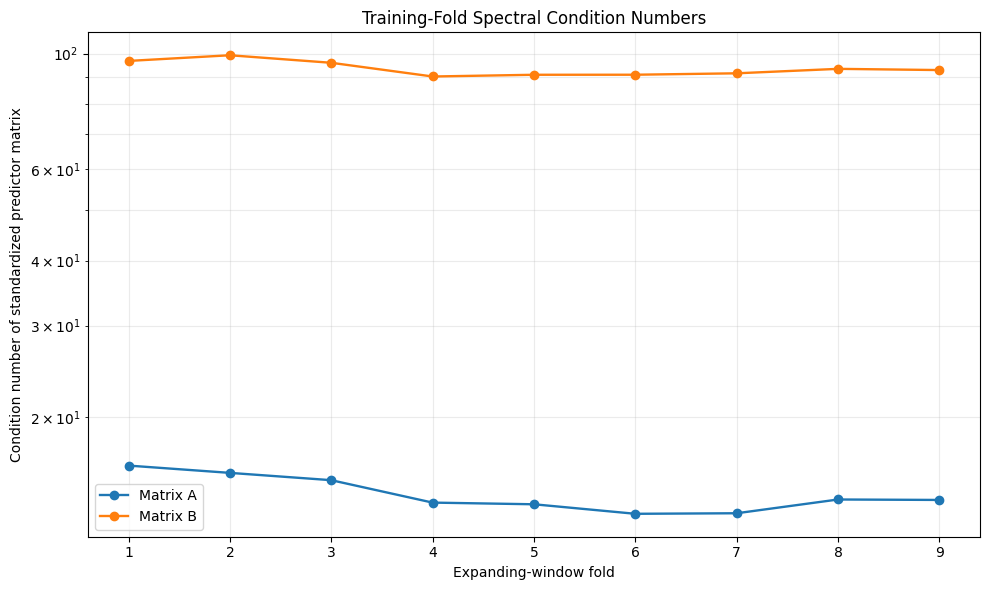

In [153]:
fig, ax = plt.subplots(figsize=(10, 6))

for matrix_name in ["A", "B"]:
    subset = fold_geometry.loc[
        fold_geometry["matrix"] == matrix_name
    ]

    ax.plot(
        subset["fold"],
        subset["spectral_condition_number_Z"],
        marker="o",
        linewidth=1.7,
        label=f"Matrix {matrix_name}",
    )

ax.set_yscale("log")

ax.set_title(
    "Training-Fold Spectral Condition Numbers"
)

ax.set_xlabel("Expanding-window fold")
ax.set_ylabel(
    "Condition number of standardized predictor matrix"
)

ax.set_xticks(
    fold_definitions["fold"]
)

ax.grid(
    alpha=0.25,
    which="both",
)

ax.legend()

fig.tight_layout()
plt.show()

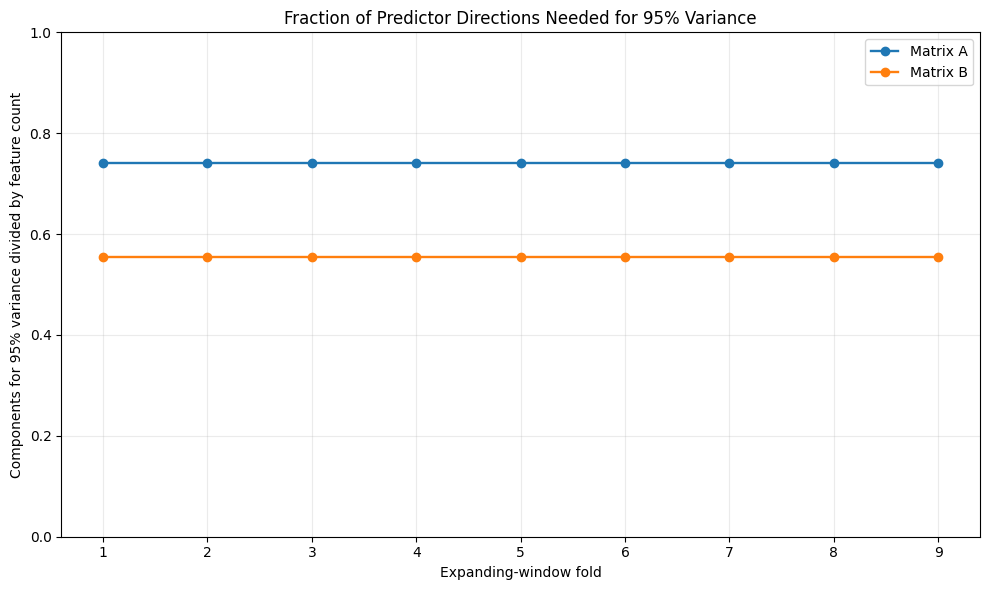

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))

for matrix_name in ["A", "B"]:
    subset = fold_geometry.loc[
        fold_geometry["matrix"] == matrix_name
    ]

    ax.plot(
        subset["fold"],
        subset["components_95_fraction"],
        marker="o",
        linewidth=1.7,
        label=f"Matrix {matrix_name}",
    )

ax.set_title(
    "Fraction of Predictor Directions Needed for 95% Variance"
)

ax.set_xlabel("Expanding-window fold")
ax.set_ylabel(
    "Components for 95% variance divided by feature count"
)

ax.set_xticks(
    fold_definitions["fold"]
)

ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [155]:
def compare_subspaces(
    left_right_singular_vectors,
    right_right_singular_vectors,
    component_indices,
):
    """Compare two right-singular-vector subspaces."""
    left_basis = (
        left_right_singular_vectors[
            component_indices,
            :
        ].T
    )

    right_basis = (
        right_right_singular_vectors[
            component_indices,
            :
        ].T
    )

    canonical_cosines = np.linalg.svd(
        left_basis.T @ right_basis,
        compute_uv=False,
    )

    canonical_cosines = np.clip(
        canonical_cosines,
        0.0,
        1.0,
    )

    principal_angles = np.degrees(
        np.arccos(canonical_cosines)
    )

    return {
        "average_squared_cosine": (
            np.mean(
                canonical_cosines ** 2
            )
        ),
        "smallest_canonical_cosine": (
            canonical_cosines.min()
        ),
        "largest_principal_angle_degrees": (
            principal_angles.max()
        ),
        "mean_principal_angle_degrees": (
            principal_angles.mean()
        ),
    }

In [156]:
subspace_stability_rows = []

for matrix_name, matrix in (
    matrix_definitions.items()
):
    matrix_folds = sorted(
        fold_geometry.loc[
            fold_geometry["matrix"]
            == matrix_name,
            "fold",
        ].tolist()
    )

    final_fold = matrix_folds[-1]

    final_vectors = (
        fold_geometry_artifacts[
            (
                matrix_name,
                final_fold,
            )
        ]["right_singular_vectors"]
    )

    number_of_features = matrix.shape[1]

    subspace_indices = {
        "leading_3": np.arange(0, 3),
        "trailing_3": np.arange(
            number_of_features - 3,
            number_of_features,
        ),
    }

    previous_vectors = None

    for fold_number in matrix_folds:
        current_vectors = (
            fold_geometry_artifacts[
                (
                    matrix_name,
                    fold_number,
                )
            ]["right_singular_vectors"]
        )

        row = {
            "matrix": matrix_name,
            "fold": fold_number,
            "reference_fold": final_fold,
        }

        for subspace_name, indices in (
            subspace_indices.items()
        ):
            comparison_to_final = compare_subspaces(
                current_vectors,
                final_vectors,
                indices,
            )

            for metric, value in (
                comparison_to_final.items()
            ):
                row[
                    f"{subspace_name}_{metric}_to_final"
                ] = value

            if previous_vectors is None:
                for metric in (
                    comparison_to_final.keys()
                ):
                    row[
                        f"{subspace_name}_{metric}_to_previous"
                    ] = np.nan
            else:
                comparison_to_previous = (
                    compare_subspaces(
                        current_vectors,
                        previous_vectors,
                        indices,
                    )
                )

                for metric, value in (
                    comparison_to_previous.items()
                ):
                    row[
                        f"{subspace_name}_{metric}_to_previous"
                    ] = value

        subspace_stability_rows.append(row)
        previous_vectors = current_vectors

subspace_stability = (
    pd.DataFrame(
        subspace_stability_rows
    )
    .sort_values(
        ["matrix", "fold"]
    )
    .reset_index(drop=True)
)

In [157]:
final_fold_rows = subspace_stability.loc[
    subspace_stability["fold"]
    == subspace_stability[
        "reference_fold"
    ]
]

for subspace_name in [
    "leading_3",
    "trailing_3",
]:
    assert np.allclose(
        final_fold_rows[
            f"{subspace_name}_average_squared_cosine_to_final"
        ],
        1.0,
        atol=1e-12,
    )

    assert np.allclose(
        final_fold_rows[
            f"{subspace_name}_largest_principal_angle_degrees_to_final"
        ],
        0.0,
        atol=1e-5,
    )

print(
    "Final-fold subspace-reference checks passed."
)

Final-fold subspace-reference checks passed.


In [158]:
subspace_stability_display_columns = [
    "matrix",
    "fold",
    "leading_3_average_squared_cosine_to_final",
    "leading_3_largest_principal_angle_degrees_to_final",
    "trailing_3_average_squared_cosine_to_final",
    "trailing_3_largest_principal_angle_degrees_to_final",
    "leading_3_average_squared_cosine_to_previous",
    "trailing_3_average_squared_cosine_to_previous",
]

display(
    subspace_stability[
        subspace_stability_display_columns
    ].round(4)
)

,matrix,fold,leading_3_average_squared_cosine_to_final,leading_3_largest_principal_angle_degrees_to_final,trailing_3_average_squared_cosine_to_final,trailing_3_largest_principal_angle_degrees_to_final,leading_3_average_squared_cosine_to_previous,trailing_3_average_squared_cosine_to_previous
0,A,1,0.9618,17.7364,0.9635,17.6258,NaN,NaN
1,A,2,0.9684,16.4114,0.9572,18.4465,0.9914,0.9986
2,A,3,0.9423,23.7025,0.9876,10.3360,0.9690,0.9832
3,A,4,0.9769,13.8391,0.9902,9.3737,0.9815,0.9866
4,A,5,0.9853,10.6899,0.9929,8.3368,0.9976,0.9990
5,A,6,0.9939,6.4229,0.9940,7.5435,0.9956,0.9992
6,A,7,0.9947,6.2888,0.9966,5.1303,0.9956,0.9984
7,A,8,0.9970,4.8240,0.9989,2.5270,0.9936,0.9978
8,A,9,1.0000,0.0000,1.0000,0.0000,0.9970,0.9989
9,B,1,0.6686,84.1763,0.9802,13.8002,NaN,NaN


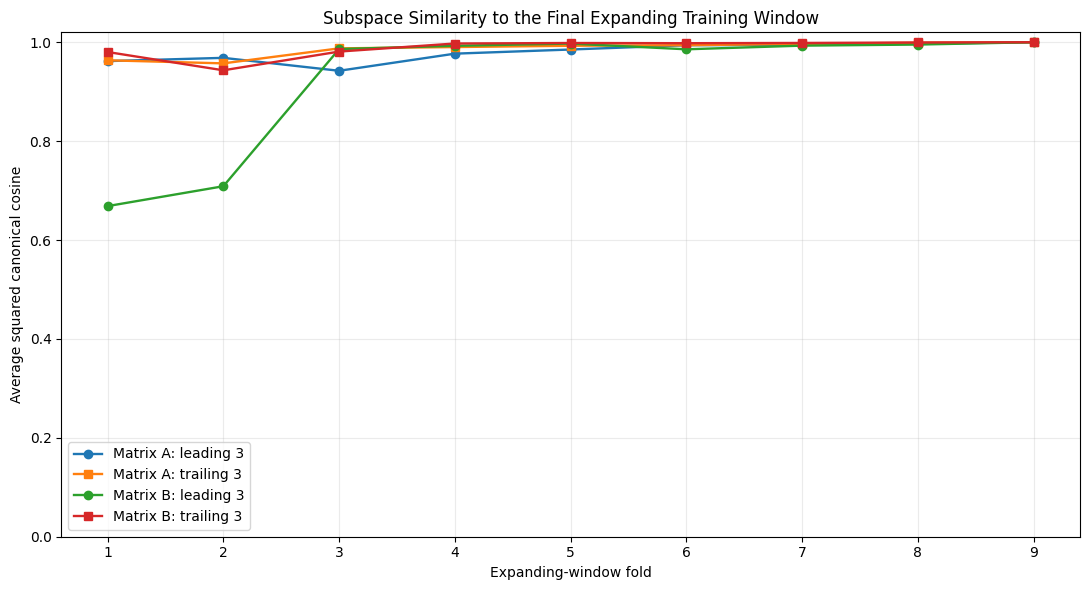

In [159]:
fig, ax = plt.subplots(figsize=(11, 6))

for matrix_name in ["A", "B"]:
    subset = subspace_stability.loc[
        subspace_stability["matrix"]
        == matrix_name
    ]

    ax.plot(
        subset["fold"],
        subset[
            "leading_3_average_squared_cosine_to_final"
        ],
        marker="o",
        linewidth=1.7,
        label=(
            f"Matrix {matrix_name}: leading 3"
        ),
    )

    ax.plot(
        subset["fold"],
        subset[
            "trailing_3_average_squared_cosine_to_final"
        ],
        marker="s",
        linewidth=1.7,
        label=(
            f"Matrix {matrix_name}: trailing 3"
        ),
    )

ax.set_title(
    "Subspace Similarity to the Final Expanding Training Window"
)

ax.set_xlabel("Expanding-window fold")
ax.set_ylabel("Average squared canonical cosine")

ax.set_xticks(
    fold_definitions["fold"]
)

ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [160]:
def compute_fold_subspace_group_energy(
    right_singular_vectors,
    feature_names,
    group_lookup,
    component_indices,
):
    """Calculate average group energy for a selected subspace."""
    selected_vectors = (
        right_singular_vectors[
            component_indices,
            :
        ]
    )

    number_of_directions = len(
        component_indices
    )

    feature_energy = (
        np.sum(
            selected_vectors ** 2,
            axis=0,
        )
        / number_of_directions
    )

    rows = []

    for feature, energy in zip(
        feature_names,
        feature_energy,
    ):
        rows.append(
            {
                "feature": feature,
                "group": group_lookup[feature],
                "average_feature_energy": energy,
            }
        )

    feature_table = pd.DataFrame(rows)

    group_table = (
        feature_table
        .groupby(
            "group",
            as_index=False,
        )["average_feature_energy"]
        .sum()
        .rename(
            columns={
                "average_feature_energy": (
                    "average_group_energy"
                )
            }
        )
    )

    assert np.isclose(
        group_table[
            "average_group_energy"
        ].sum(),
        1.0,
        atol=1e-12,
    )

    return group_table

In [161]:
fold_subspace_energy_rows = []

matrix_feature_metadata = {
    "A": {
        "features": matrix_a_features,
        "groups": matrix_a_groups,
        "lookup": matrix_a_group_lookup,
    },
    "B": {
        "features": matrix_b_features,
        "groups": matrix_b_groups,
        "lookup": matrix_b_group_lookup,
    },
}

for matrix_name, metadata in (
    matrix_feature_metadata.items()
):
    number_of_features = len(
        metadata["features"]
    )

    selected_subspaces = {
        "leading_3": np.arange(0, 3),
        "trailing_3": np.arange(
            number_of_features - 3,
            number_of_features,
        ),
    }

    for fold_number in fold_definitions[
        "fold"
    ]:
        right_singular_vectors = (
            fold_geometry_artifacts[
                (
                    matrix_name,
                    fold_number,
                )
            ]["right_singular_vectors"]
        )

        for subspace_name, indices in (
            selected_subspaces.items()
        ):
            group_energy = (
                compute_fold_subspace_group_energy(
                    right_singular_vectors,
                    metadata["features"],
                    metadata["lookup"],
                    indices,
                )
            )

            for row in group_energy.itertuples(
                index=False
            ):
                fold_subspace_energy_rows.append(
                    {
                        "matrix": matrix_name,
                        "fold": fold_number,
                        "subspace": subspace_name,
                        "group": row.group,
                        "average_group_energy": (
                            row.average_group_energy
                        ),
                    }
                )

fold_subspace_group_energy = pd.DataFrame(
    fold_subspace_energy_rows
)

In [162]:
def display_fold_subspace_energy(
    energy_table,
    matrix_name,
    subspace_name,
    group_order,
):
    pivot = (
        energy_table.loc[
            (
                energy_table["matrix"]
                == matrix_name
            )
            &
            (
                energy_table["subspace"]
                == subspace_name
            )
        ]
        .pivot(
            index="fold",
            columns="group",
            values="average_group_energy",
        )
        .reindex(
            columns=group_order
        )
    )

    assert np.allclose(
        pivot.sum(axis=1),
        1.0,
        atol=1e-12,
    )

    display(pivot.round(3))

    return pivot

In [163]:
print(
    "Matrix A leading-three group energy by fold:"
)

matrix_a_fold_leading_energy = (
    display_fold_subspace_energy(
        fold_subspace_group_energy,
        "A",
        "leading_3",
        list(matrix_a_groups.keys()),
    )
)

print(
    "Matrix A trailing-three group energy by fold:"
)

matrix_a_fold_trailing_energy = (
    display_fold_subspace_energy(
        fold_subspace_group_energy,
        "A",
        "trailing_3",
        list(matrix_a_groups.keys()),
    )
)

Matrix A leading-three group energy by fold:


group,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
fold,,,,,,
1,0.278,0.198,0.132,0.246,0.056,0.090
2,0.266,0.201,0.141,0.242,0.054,0.096
3,0.266,0.199,0.131,0.245,0.059,0.100
4,0.253,0.201,0.134,0.246,0.058,0.109
5,0.250,0.200,0.137,0.246,0.055,0.112
6,0.244,0.203,0.143,0.244,0.054,0.111
7,0.257,0.205,0.144,0.249,0.057,0.088
8,0.243,0.211,0.152,0.241,0.055,0.099
9,0.246,0.210,0.146,0.243,0.054,0.100


Matrix A trailing-three group energy by fold:


group,annual_calendar,weekly_calendar,holiday_calendar,demand_history,lagged_temperature,lagged_precipitation
fold,,,,,,
1,0.321,0.011,0.0,0.649,0.016,0.002
2,0.313,0.010,0.0,0.659,0.015,0.002
3,0.301,0.011,0.0,0.670,0.016,0.003
4,0.315,0.015,0.0,0.640,0.026,0.004
5,0.318,0.013,0.0,0.642,0.023,0.004
6,0.313,0.012,0.0,0.648,0.023,0.004
7,0.313,0.012,0.0,0.648,0.024,0.003
8,0.312,0.012,0.0,0.649,0.023,0.003
9,0.312,0.012,0.0,0.650,0.023,0.003


In [164]:
print(
    "Matrix B leading-three group energy by fold:"
)

matrix_b_fold_leading_energy = (
    display_fold_subspace_energy(
        fold_subspace_group_energy,
        "B",
        "leading_3",
        list(matrix_b_groups.keys()),
    )
)

print(
    "Matrix B trailing-three group energy by fold:"
)

matrix_b_fold_trailing_energy = (
    display_fold_subspace_energy(
        fold_subspace_group_energy,
        "B",
        "trailing_3",
        list(matrix_b_groups.keys()),
    )
)

Matrix B leading-three group energy by fold:


group,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
fold,,,,,,,,,
1,0.154,0.002,0.002,0.132,0.070,0.047,0.132,0.209,0.251
2,0.172,0.002,0.002,0.134,0.071,0.053,0.127,0.198,0.241
3,0.303,0.001,0.000,0.148,0.077,0.056,0.119,0.138,0.158
4,0.306,0.001,0.000,0.147,0.075,0.055,0.122,0.135,0.159
5,0.312,0.000,0.001,0.148,0.075,0.054,0.120,0.130,0.160
6,0.302,0.001,0.001,0.147,0.076,0.056,0.120,0.136,0.162
7,0.308,0.000,0.000,0.149,0.075,0.048,0.123,0.132,0.163
8,0.306,0.000,0.000,0.146,0.074,0.051,0.123,0.132,0.165
9,0.314,0.000,0.001,0.148,0.075,0.050,0.119,0.129,0.165


Matrix B trailing-three group energy by fold:


group,annual_calendar,weekly_calendar,holiday_calendar,direct_demand_lags,rolling_demand_level,rolling_demand_variability,lagged_temperature,lagged_precipitation,lagged_snow
fold,,,,,,,,,
1,0.323,0.0,0.0,0.067,0.607,0.001,0.001,0.0,0.0
2,0.301,0.0,0.0,0.070,0.626,0.001,0.001,0.0,0.0
3,0.324,0.0,0.0,0.068,0.606,0.001,0.001,0.0,0.0
4,0.334,0.0,0.0,0.074,0.590,0.001,0.001,0.0,0.0
5,0.334,0.0,0.0,0.075,0.589,0.001,0.001,0.0,0.0
6,0.335,0.0,0.0,0.073,0.590,0.001,0.001,0.0,0.0
7,0.335,0.0,0.0,0.073,0.591,0.001,0.000,0.0,0.0
8,0.334,0.0,0.0,0.073,0.592,0.001,0.000,0.0,0.0
9,0.334,0.0,0.0,0.071,0.594,0.001,0.000,0.0,0.0


In [165]:
dominant_fold_subspace_groups = (
    fold_subspace_group_energy.loc[
        fold_subspace_group_energy
        .groupby(
            [
                "matrix",
                "fold",
                "subspace",
            ]
        )["average_group_energy"]
        .idxmax()
    ]
    .sort_values(
        [
            "matrix",
            "subspace",
            "fold",
        ]
    )
    .reset_index(drop=True)
)

display(
    dominant_fold_subspace_groups.round(4)
)

,matrix,fold,subspace,group,average_group_energy
0,A,1,leading_3,annual_calendar,0.2778
1,A,2,leading_3,annual_calendar,0.2662
2,A,3,leading_3,annual_calendar,0.2659
3,A,4,leading_3,annual_calendar,0.2526
4,A,5,leading_3,annual_calendar,0.2500
5,A,6,leading_3,demand_history,0.2445
6,A,7,leading_3,annual_calendar,0.2572
7,A,8,leading_3,annual_calendar,0.2429
8,A,9,leading_3,annual_calendar,0.2464
9,A,1,trailing_3,demand_history,0.6491


### Evidence

All nine training-fold matrices remain numerically full column rank. Matrix A
condition numbers range from approximately 13.0 to 16.2, while Matrix B
condition numbers range from approximately 90.4 to 99.3. Matrix B is therefore
between six and seven times more poorly conditioned in every expanding
training window.

Matrix A contains three directions below ten percent of its leading singular
value in the first two folds and two thereafter. Matrix B contains seventeen
such directions in every fold. Matrix A always requires 20 of 27 directions
to explain 95 percent of predictor variance, while Matrix B always requires
30 of 54. Stable rank, entropy effective rank and participation-ratio
effective rank also vary only slightly across folds.

The conditioning and effective-rank differences are therefore persistent
features of the matrix definitions rather than consequences of one unusual
training period. Adding observations does not remove the overlap created by
nearby lags, rolling summaries and alternative seasonal representations.

Matrix A's leading and trailing three-dimensional subspaces are stable across
the expanding windows. Its leading subspace consistently distributes energy
across annual calendar, weekly calendar, holiday, demand-history and weather
features. No single group dominates that subspace by a wide margin.

Matrix A's trailing subspace is even more consistent. Demand history accounts
for approximately 64 to 67 percent of its energy and annual calendar features
account for approximately 30 to 32 percent. The weak Matrix A directions
therefore remain contrasts among correlated demand lags and fine seasonal
representations.

Matrix B's trailing subspace is also highly stable. Rolling demand-level
features contribute approximately 59 to 63 percent, annual calendar features
approximately 30 to 34 percent and direct demand lags approximately seven
percent in every fold. This confirms that overlapping rolling summaries,
direct lags and seasonal encodings repeatedly form the weak predictor
directions.

Matrix B's leading three-dimensional subspace differs in the first two folds
but becomes highly stable beginning with fold three. The early discrepancy is
largely attributable to one direction: two canonical directions remain closely
aligned while the third has a large principal angle relative to the final
subspace.

The leading-three group composition changes at the same point. Lagged snow and
precipitation account for a larger share in folds one and two, while annual
calendar energy becomes dominant from fold three onward. Because neighboring
leading eigenvalues are close, this should be interpreted as sensitivity near
the selected three-dimensional boundary rather than evidence of a confirmed
physical regime change.

### Provisional modeling implications

- Treat Matrix A as a stable, moderately conditioned linear baseline.
- Treat Matrix B's poorer conditioning as a persistent structural property of
  its engineered feature set.
- Expect Matrix B OLS coefficient instability to recur across validation
  folds, particularly among rolling-demand and direct-lag features.
- Evaluate coefficient stability separately from forecast accuracy.
- Fit all scaling, PCA and regularization parameters using each training window
  only.
- Select the PCR dimension through rolling validation rather than fixing it
  from the full-development spectrum.
- Use ridge to test whether continuous shrinkage of the stable weak directions
  outperforms hard component truncation.
- Avoid interpreting the early Matrix B leading-subspace change as a confirmed
  water-demand regime shift.
- Emphasize subspace and feature-group stability rather than individual
  principal-component signs or orderings.

### Open questions

- Do Matrix B OLS coefficients fluctuate most strongly in the rolling-demand
  and direct-lag groups identified by the trailing subspace?
- Does the selected PCR dimension remain stable across validation folds?
- Does ridge choose stronger regularization for Matrix B than for Matrix A?
- Do the additional Matrix B features improve forecast accuracy enough to
  justify their persistent redundancy?
- Is weather most valuable in particular seasonal validation quarters?
- Do coefficient instability and forecast error move together or remain
  largely separate?

## 15. Modeling decision freeze and notebook handoff

The exploratory analysis has established the forecasting task, chronological
evaluation design, leakage-safe feature definitions and predictor geometry.
This section freezes those decisions before any supervised model comparison is
performed.

The primary comparison will evaluate two operational feature matrices:

- **Matrix A:** a curated and interpretable specification
- **Matrix B:** a broader specification containing overlapping demand-history,
  seasonal and weather representations

The model comparison will include naïve forecasts, ordinary least squares,
principal component regression, ridge regression and XGBoost. Model and
hyperparameter selection will use only the nine rolling validation windows.

The final holdout period from April 1, 2025 through March 31, 2026 will remain
untouched until all model, feature and hyperparameter decisions have been made.

In [166]:
final_holdout_start = pd.Timestamp("2025-04-01")
final_holdout_end = pd.Timestamp("2026-03-31")

assert feature_dates.min() == pd.Timestamp("2020-01-29")
assert feature_dates.max() == pd.Timestamp("2025-03-31")

assert final_holdout_start == (
    feature_dates.max() + pd.Timedelta(days=1)
)

assert (
    fold_definitions["validation_end"].max()
    == pd.Timestamp("2025-03-31")
)

evaluation_period_summary = pd.DataFrame(
    [
        {
            "period": "Aligned development period",
            "start": feature_dates.min(),
            "end": feature_dates.max(),
            "use": (
                "EDA, rolling validation and model selection"
            ),
        },
        {
            "period": "Final untouched holdout",
            "start": final_holdout_start,
            "end": final_holdout_end,
            "use": (
                "One final evaluation after all decisions are frozen"
            ),
        },
    ]
)

display(evaluation_period_summary)

,period,start,end,use
0,Aligned development period,2020-01-29,2025-03-31,"EDA, rolling validation and model selection"
1,Final untouched holdout,2025-04-01,2026-03-31,One final evaluation after all decisions are f...


In [167]:
frozen_feature_matrices = {
    "A": {
        "description": (
            "Curated operational matrix"
        ),
        "features": list(matrix_a_features),
        "groups": {
            group: list(features)
            for group, features in matrix_a_groups.items()
        },
        "same_day_weather_addons": list(
            matrix_a_weather_informed_addons
        ),
    },
    "B": {
        "description": (
            "Broad operational matrix with overlapping "
            "engineered predictors"
        ),
        "features": list(matrix_b_features),
        "groups": {
            group: list(features)
            for group, features in matrix_b_groups.items()
        },
        "same_day_weather_addons": list(
            matrix_b_weather_informed_addons
        ),
    },
}

assert len(
    frozen_feature_matrices["A"]["features"]
) == 27

assert len(
    frozen_feature_matrices["B"]["features"]
) == 54

assert set(
    frozen_feature_matrices["A"]["features"]
).issubset(
    set(frozen_feature_matrices["B"]["features"])
)

for matrix_name in ["A", "B"]:
    operational_features = frozen_feature_matrices[
        matrix_name
    ]["features"]

    assert not any(
        feature.startswith("same_day_")
        for feature in operational_features
    )

print("Operational feature definitions frozen.")

Operational feature definitions frozen.


In [168]:
frozen_feature_group_summary = pd.concat(
    [
        pd.DataFrame(
            {
                "matrix": matrix_name,
                "group": list(
                    specification["groups"].keys()
                ),
                "number_of_features": [
                    len(features)
                    for features in specification[
                        "groups"
                    ].values()
                ],
            }
        )
        for matrix_name, specification
        in frozen_feature_matrices.items()
    ],
    ignore_index=True,
)

display(frozen_feature_group_summary)

,matrix,group,number_of_features
0,A,annual_calendar,11
1,A,weekly_calendar,6
2,A,holiday_calendar,3
3,A,demand_history,4
4,A,lagged_temperature,1
5,A,lagged_precipitation,2
6,B,annual_calendar,15
7,B,weekly_calendar,6
8,B,holiday_calendar,3
9,B,direct_demand_lags,6


In [169]:
primary_model_catalog = pd.DataFrame(
    [
        {
            "model_id": "naive_previous_day",
            "model_family": "Naïve",
            "feature_matrix": "Lag 1 only",
            "tuned": False,
            "selection_role": "Primary baseline",
            "description": (
                "Predict current demand using previous-day demand"
            ),
        },
        {
            "model_id": "naive_previous_week",
            "model_family": "Seasonal naïve",
            "feature_matrix": "Lag 7 only",
            "tuned": False,
            "selection_role": "Primary baseline",
            "description": (
                "Predict current demand using demand seven days earlier"
            ),
        },
        {
            "model_id": "city_projection_reference",
            "model_family": "External reference",
            "feature_matrix": "Not applicable",
            "tuned": False,
            "selection_role": "Contextual reference",
            "description": (
                "Compare observed demand with the City projection "
                "without using it as a model predictor"
            ),
        },
        {
            "model_id": "ols_a",
            "model_family": "OLS",
            "feature_matrix": "A",
            "tuned": False,
            "selection_role": "Primary candidate",
            "description": (
                "Unregularized linear model on curated features"
            ),
        },
        {
            "model_id": "ols_b",
            "model_family": "OLS",
            "feature_matrix": "B",
            "tuned": False,
            "selection_role": "Primary candidate",
            "description": (
                "Unregularized linear model on broad features"
            ),
        },
        {
            "model_id": "pcr_a",
            "model_family": "PCR",
            "feature_matrix": "A",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Standardization, PCA and linear regression"
            ),
        },
        {
            "model_id": "pcr_b",
            "model_family": "PCR",
            "feature_matrix": "B",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Standardization, PCA and linear regression"
            ),
        },
        {
            "model_id": "ridge_a",
            "model_family": "Ridge",
            "feature_matrix": "A",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Standardized ridge regression on curated features"
            ),
        },
        {
            "model_id": "ridge_b",
            "model_family": "Ridge",
            "feature_matrix": "B",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Standardized ridge regression on broad features"
            ),
        },
        {
            "model_id": "xgboost_a",
            "model_family": "XGBoost",
            "feature_matrix": "A",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Nonlinear tree ensemble on curated features"
            ),
        },
        {
            "model_id": "xgboost_b",
            "model_family": "XGBoost",
            "feature_matrix": "B",
            "tuned": True,
            "selection_role": "Primary candidate",
            "description": (
                "Nonlinear tree ensemble on broad features"
            ),
        },
    ]
)

display(primary_model_catalog)

,model_id,model_family,feature_matrix,tuned,selection_role,description
0,naive_previous_day,Naïve,Lag 1 only,False,Primary baseline,Predict current demand using previous-day demand
1,naive_previous_week,Seasonal naïve,Lag 7 only,False,Primary baseline,Predict current demand using demand seven days...
2,city_projection_reference,External reference,Not applicable,False,Contextual reference,Compare observed demand with the City projecti...
3,ols_a,OLS,A,False,Primary candidate,Unregularized linear model on curated features
4,ols_b,OLS,B,False,Primary candidate,Unregularized linear model on broad features
5,pcr_a,PCR,A,True,Primary candidate,"Standardization, PCA and linear regression"
6,pcr_b,PCR,B,True,Primary candidate,"Standardization, PCA and linear regression"
7,ridge_a,Ridge,A,True,Primary candidate,Standardized ridge regression on curated features
8,ridge_b,Ridge,B,True,Primary candidate,Standardized ridge regression on broad features
9,xgboost_a,XGBoost,A,True,Primary candidate,Nonlinear tree ensemble on curated features


In [170]:
pcr_component_grids = {
    "A": [
        5,
        10,
        15,
        18,
        20,
        23,
        27,
    ],
    "B": [
        5,
        10,
        15,
        19,
        26,
        30,
        39,
        54,
    ],
}

assert pcr_component_grids["A"][-1] == len(
    matrix_a_features
)

assert pcr_component_grids["B"][-1] == len(
    matrix_b_features
)

print("Matrix A PCR candidates:", pcr_component_grids["A"])
print("Matrix B PCR candidates:", pcr_component_grids["B"])

Matrix A PCR candidates: [5, 10, 15, 18, 20, 23, 27]
Matrix B PCR candidates: [5, 10, 15, 19, 26, 30, 39, 54]


In [171]:
ridge_alpha_grid = np.logspace(
    -4,
    4,
    17,
).tolist()

print("Number of ridge penalties:", len(ridge_alpha_grid))
print("Ridge penalties:")
print(ridge_alpha_grid)

Number of ridge penalties: 17
Ridge penalties:
[0.0001, 0.00031622776601683794, 0.001, 0.0031622776601683794, 0.01, 0.03162277660168379, 0.1, 0.31622776601683794, 1.0, 3.1622776601683795, 10.0, 31.622776601683793, 100.0, 316.22776601683796, 1000.0, 3162.2776601683795, 10000.0]


In [172]:
xgboost_grid = []

for (
    n_estimators,
    max_depth,
    learning_rate,
    min_child_weight,
) in product(
    [300, 600],
    [2, 3],
    [0.03, 0.05],
    [1, 5],
):
    xgboost_grid.append(
        {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "learning_rate": learning_rate,
            "min_child_weight": min_child_weight,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "objective": "reg:squarederror",
            "random_state": 2026,
            "n_jobs": -1,
        }
    )

print(
    "Number of XGBoost candidate configurations:",
    len(xgboost_grid),
)

display(pd.DataFrame(xgboost_grid))

Number of XGBoost candidate configurations: 16


,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_lambda,objective,random_state,n_jobs
0,300,2,0.03,1,0.8,0.8,1.0,reg:squarederror,2026,-1
1,300,2,0.03,5,0.8,0.8,1.0,reg:squarederror,2026,-1
2,300,2,0.05,1,0.8,0.8,1.0,reg:squarederror,2026,-1
3,300,2,0.05,5,0.8,0.8,1.0,reg:squarederror,2026,-1
4,300,3,0.03,1,0.8,0.8,1.0,reg:squarederror,2026,-1
5,300,3,0.03,5,0.8,0.8,1.0,reg:squarederror,2026,-1
6,300,3,0.05,1,0.8,0.8,1.0,reg:squarederror,2026,-1
7,300,3,0.05,5,0.8,0.8,1.0,reg:squarederror,2026,-1
8,600,2,0.03,1,0.8,0.8,1.0,reg:squarederror,2026,-1
9,600,2,0.03,5,0.8,0.8,1.0,reg:squarederror,2026,-1


In [173]:
matrix_a_calendar_features = (
    matrix_a_groups["annual_calendar"]
    + matrix_a_groups["weekly_calendar"]
    + matrix_a_groups["holiday_calendar"]
)

matrix_a_demand_features = list(
    matrix_a_groups["demand_history"]
)

matrix_a_temperature_features = list(
    matrix_a_groups["lagged_temperature"]
)

matrix_a_precipitation_features = list(
    matrix_a_groups["lagged_precipitation"]
)

matrix_a_ablation_definitions = {
    "calendar_only": (
        matrix_a_calendar_features
    ),
    "demand_history_only": (
        matrix_a_demand_features
    ),
    "calendar_plus_demand": (
        matrix_a_calendar_features
        + matrix_a_demand_features
    ),
    "plus_lagged_temperature": (
        matrix_a_calendar_features
        + matrix_a_demand_features
        + matrix_a_temperature_features
    ),
    "full_operational_matrix_a": list(
        matrix_a_features
    ),
}

ablation_summary = pd.DataFrame(
    [
        {
            "ablation": name,
            "number_of_features": len(features),
            "features": ", ".join(features),
        }
        for name, features
        in matrix_a_ablation_definitions.items()
    ]
)

display(
    ablation_summary[
        [
            "ablation",
            "number_of_features",
        ]
    ]
)

,ablation,number_of_features
0,calendar_only,20
1,demand_history_only,4
2,calendar_plus_demand,24
3,plus_lagged_temperature,25
4,full_operational_matrix_a,27


In [174]:
ablation_names = list(
    matrix_a_ablation_definitions.keys()
)

for earlier, later in zip(
    ablation_names[2:],
    ablation_names[3:],
):
    assert set(
        matrix_a_ablation_definitions[earlier]
    ).issubset(
        set(
            matrix_a_ablation_definitions[later]
        )
    )

assert set(
    matrix_a_ablation_definitions[
        "full_operational_matrix_a"
    ]
) == set(matrix_a_features)

print("Matrix A ablation definitions verified.")

Matrix A ablation definitions verified.


In [175]:
weather_informed_benchmark_rule = {
    "purpose": (
        "Estimate the retrospective value of perfectly known "
        "same-day observed weather"
    ),
    "timing": (
        "Run only after the best operational model family and "
        "feature matrix have been selected"
    ),
    "matrix_A_addons": list(
        matrix_a_weather_informed_addons
    ),
    "matrix_B_addons": list(
        matrix_b_weather_informed_addons
    ),
    "interpretation": (
        "Optimistic benchmark, not an operational forecast"
    ),
}

display(
    pd.DataFrame(
        [
            {
                "matrix": "A",
                "same_day_addons": ", ".join(
                    matrix_a_weather_informed_addons
                ),
            },
            {
                "matrix": "B",
                "same_day_addons": ", ".join(
                    matrix_b_weather_informed_addons
                ),
            },
        ]
    )
)

,matrix,same_day_addons
0,A,"same_day_tavg_f, same_day_precipitation_in"
1,B,"same_day_tavg_f, same_day_temperature_range_f,..."


In [176]:
model_selection_protocol = {
    "primary_metric": (
        "MAE pooled across all rolling-validation predictions"
    ),
    "secondary_metrics": [
        "RMSE pooled across rolling-validation predictions",
        "MAPE pooled across rolling-validation predictions",
        "Mean fold MAE",
        "Standard deviation of fold MAE",
        "Worst-fold MAE",
    ],
    "hyperparameter_selection": (
        "Choose the candidate with the lowest pooled "
        "rolling-validation MAE"
    ),
    "practical_tie_rule": (
        "When pooled MAE differs by less than 1 percent, "
        "prefer the model with lower worst-fold MAE and then "
        "the simpler specification"
    ),
    "final_holdout_rule": (
        "Evaluate the final selected specification once after "
        "retraining on the complete development period"
    ),
}

display(
    pd.DataFrame(
        [
            {
                "decision": key,
                "value": (
                    ", ".join(value)
                    if isinstance(value, list)
                    else value
                ),
            }
            for key, value
            in model_selection_protocol.items()
        ]
    )
)

,decision,value
0,primary_metric,MAE pooled across all rolling-validation predi...
1,secondary_metrics,RMSE pooled across rolling-validation predicti...
2,hyperparameter_selection,Choose the candidate with the lowest pooled ro...
3,practical_tie_rule,When pooled MAE differs by less than 1 percent...
4,final_holdout_rule,Evaluate the final selected specification once...


In [177]:
preprocessing_rules = pd.DataFrame(
    [
        {
            "model_family": "Naïve",
            "scaling": "None",
            "training_rule": "No fitted parameters",
        },
        {
            "model_family": "OLS",
            "scaling": (
                "Training-fold standardization for consistent "
                "coefficient and geometry analysis"
            ),
            "training_rule": (
                "Fit with a stable least-squares solver and intercept"
            ),
        },
        {
            "model_family": "PCR",
            "scaling": (
                "Fit StandardScaler on training fold only"
            ),
            "training_rule": (
                "Fit PCA and regression on training fold only"
            ),
        },
        {
            "model_family": "Ridge",
            "scaling": (
                "Fit StandardScaler on training fold only"
            ),
            "training_rule": (
                "Fit ridge model and intercept on training fold only"
            ),
        },
        {
            "model_family": "XGBoost",
            "scaling": "No scaling required",
            "training_rule": (
                "Use fixed candidate grid and random seed"
            ),
        },
    ]
)

display(preprocessing_rules)

,model_family,scaling,training_rule
0,Naïve,None,No fitted parameters
1,OLS,Training-fold standardization for consistent c...,Fit with a stable least-squares solver and int...
2,PCR,Fit StandardScaler on training fold only,Fit PCA and regression on training fold only
3,Ridge,Fit StandardScaler on training fold only,Fit ridge model and intercept on training fold...
4,XGBoost,No scaling required,Use fixed candidate grid and random seed


In [178]:
planned_model_outputs = pd.DataFrame(
    [
        {
            "path": (
                "reports/model_comparison_fold_metrics.csv"
            ),
            "contents": (
                "One row per model, hyperparameter and fold"
            ),
        },
        {
            "path": (
                "reports/model_comparison_predictions.csv"
            ),
            "contents": (
                "Date-level rolling-validation predictions"
            ),
        },
        {
            "path": (
                "reports/model_selection_summary.csv"
            ),
            "contents": (
                "Pooled metrics and selected hyperparameters"
            ),
        },
        {
            "path": (
                "reports/feature_ablation_summary.csv"
            ),
            "contents": (
                "Incremental feature-family comparison"
            ),
        },
        {
            "path": (
                "reports/final_holdout_metrics.csv"
            ),
            "contents": (
                "Single final holdout evaluation"
            ),
        },
        {
            "path": (
                "reports/final_holdout_predictions.csv"
            ),
            "contents": (
                "Date-level holdout forecasts"
            ),
        },
        {
            "path": (
                "reports/selected_model.json"
            ),
            "contents": (
                "Final model, matrix, hyperparameters and metadata"
            ),
        },
    ]
)

display(planned_model_outputs)

,path,contents
0,reports/model_comparison_fold_metrics.csv,"One row per model, hyperparameter and fold"
1,reports/model_comparison_predictions.csv,Date-level rolling-validation predictions
2,reports/model_selection_summary.csv,Pooled metrics and selected hyperparameters
3,reports/feature_ablation_summary.csv,Incremental feature-family comparison
4,reports/final_holdout_metrics.csv,Single final holdout evaluation
5,reports/final_holdout_predictions.csv,Date-level holdout forecasts
6,reports/selected_model.json,"Final model, matrix, hyperparameters and metadata"


In [179]:
prohibited_predictors = {
    target_column,
    "projected_water_demand_mgd",
    "actual_projected_demand_ratio",
    "plant_demand_mgd",
}

for matrix_name in ["A", "B"]:
    features = set(
        frozen_feature_matrices[
            matrix_name
        ]["features"]
    )

    assert prohibited_predictors.isdisjoint(
        features
    )

    assert not any(
        feature.startswith("same_day_")
        for feature in features
    )

assert (
    fold_definitions["validation_end"].max()
    < final_holdout_start
)

assert (
    fold_definitions["training_observations"]
    .is_monotonic_increasing
)

assert len(xgboost_grid) == 16
assert len(ridge_alpha_grid) == 17

print("All modeling-decision checks passed.")
print("Final holdout remains isolated.")

All modeling-decision checks passed.
Final holdout remains isolated.


In [180]:
modeling_decisions = {
    "task": {
        "forecast_horizon_days": 1,
        "target": target_column,
        "development_start": str(
            feature_dates.min().date()
        ),
        "development_end": str(
            feature_dates.max().date()
        ),
        "final_holdout_start": str(
            final_holdout_start.date()
        ),
        "final_holdout_end": str(
            final_holdout_end.date()
        ),
    },
    "feature_matrices": frozen_feature_matrices,
    "pcr_component_grids": pcr_component_grids,
    "ridge_alpha_grid": [
        float(value)
        for value in ridge_alpha_grid
    ],
    "xgboost_grid": xgboost_grid,
    "matrix_a_ablations": {
        name: list(features)
        for name, features
        in matrix_a_ablation_definitions.items()
    },
    "weather_informed_benchmark": (
        weather_informed_benchmark_rule
    ),
    "selection_protocol": (
        model_selection_protocol
    ),
    "finalized_after_eda_section": 15,
}

decision_output_path = (
    repo_root
    / "reports"
    / "modeling_decisions.json"
)

decision_output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with decision_output_path.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        modeling_decisions,
        output_file,
        indent=2,
    )

print(
    "Saved modeling decisions to:",
    decision_output_path,
)

Saved modeling decisions to: /content/municipal-water-demand-forecasting/reports/modeling_decisions.json


In [181]:
with decision_output_path.open(
    "r",
    encoding="utf-8",
) as input_file:
    saved_modeling_decisions = json.load(
        input_file
    )

assert (
    saved_modeling_decisions[
        "task"
    ]["final_holdout_start"]
    == "2025-04-01"
)

assert len(
    saved_modeling_decisions[
        "feature_matrices"
    ]["A"]["features"]
) == 27

assert len(
    saved_modeling_decisions[
        "feature_matrices"
    ]["B"]["features"]
) == 54

print("Saved modeling-decision artifact verified.")

Saved modeling-decision artifact verified.


### Reproducibility note

The preceding cells write and verify
`reports/modeling_decisions.json`, which records the feature matrices,
candidate hyperparameters and selection rules carried into the model-comparison
notebook.

Version-control commands are intentionally excluded from this public
analytical workflow. Changes should be reviewed, committed and pushed from the
user's normal Git environment after the notebook has been executed and its
artifacts have been inspected.


### Frozen modeling plan

The exploratory phase is complete. Matrix A will serve as the curated,
interpretable operational feature specification, while Matrix B will serve as
the broader specification used to test the consequences of overlapping feature
engineering.

The primary operational comparison will include previous-day and previous-week
naïve forecasts, OLS, PCR, ridge regression and XGBoost. OLS, PCR, ridge and
XGBoost will each be evaluated on both Matrix A and Matrix B. The City demand
projection will be retained as a contextual reference rather than a model
predictor.

PCR component counts, ridge penalties and XGBoost configurations will be
selected using the nine chronological validation windows. Pooled
out-of-sample MAE is the primary selection metric. RMSE, MAPE, fold-level
variation and worst-fold performance will provide secondary evidence.

Matrix A will also support an incremental feature ablation comparing calendar
information, demand history, lagged temperature and lagged precipitation. This
will determine whether operationally available weather improves forecasts
after calendar and recent-demand information are included.

Same-day observed weather will remain excluded from the primary operational
comparison. After the best operational model has been selected, the same model
will be reevaluated with same-day observed weather as an explicitly labeled
retrospective benchmark.

The final holdout from April 1, 2025 through March 31, 2026 will remain
untouched during model and hyperparameter selection. Candidate features will be
constructed on the complete ordered time series so that holdout rows can use
legitimate historical lags, but holdout targets will not influence fitting,
scaling, PCA, regularization or model selection.

The final nonlinear interpretation will use SHAP only after the model
comparison is complete. PCA loadings, ridge regularization and SHAP values will
be treated as complementary descriptions of predictor geometry,
regularization and model-specific predictive influence.